# Librerías

In [1]:
import shap
import itertools
import hashlib
import json

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu, norm

from statsmodels.stats.multitest import multipletests

from xgboost import XGBClassifier

from os.path import join

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [77]:
# Data presencia/ausencia
exist_data = pd.read_csv('../Data/exist.csv', index_col=0).T

# Data fold change
fold_data = pd.read_csv('../Data/fold.csv', index_col=0).T

# Metadata personas
metadata = pd.read_csv('../Data/metadata.csv')

# Metadata péptidos
peptide_info = pd.read_csv('../Data/peptide_libraries_info.csv', index_col=0)

# Funciones

## OG modificadas

In [78]:
def split_xy_df_and_filter_by_threshold(xy_df, bottom_threshold):

    # Los 3 tipos de prefijos que tienen las columnas de péptidos
    peptide_prefixes = ['twist_', 'agilent_', 'corona2_']

    # Se crea una lista con los nombres de las columnas que comiencen con los prefijos
    peptide_cols = [col for col in xy_df.columns if any(col.startswith(p) for p in peptide_prefixes)]
    # Se crea una lista con las columnas que no se incluyeron en la lista anterior
    non_peptide_cols = [col for col in xy_df.columns if col not in peptide_cols]

    # Dataframe solo con los péptidos
    peptides_df = xy_df[peptide_cols]

    # Función que devuelve True para valores distintos de 0
    filter_function = lambda x: x != 0
    # Aplica la función anterior a todo el df de péptidos, calcula promedio de Trues en cada columna y asigna True a aquellas columnas cuyo promedio sea >= al threshold
    # Nos quedamos solo con los datos cuyas columnas tengan True asignado al final
    kept_peptides = peptides_df.loc[:, peptides_df.map(filter_function).mean().ge(bottom_threshold)]

    # Reconstruimos el df original con los péptidos filtrados
    xy_df_filtered = pd.concat([kept_peptides, xy_df[non_peptide_cols]], axis=1)

    # Última col df
    y = xy_df_filtered.iloc[:, -1]
    # Todas las col menos la última
    x = xy_df_filtered.iloc[:, :-1]

    # Si no quedan columnas despues de aplicar el threshold se devuelve None
    if x.shape[1] == 0:
        return None 
    
    # En otro caso, se devuelve el df dividido
    return x, y

def get_cross_validation_predictions(x, y, estimator):

    # Validación cruzada Leave One Out
    # Se extrae la probabilidad de pertenecer a la clase positiva (diseased)
    proba = cross_val_predict(
        estimator, x, y,
        cv=LeaveOneOut(),
        method='predict_proba',
        n_jobs=-1
    )[:, 1]                                       

    # Se asigna como índice los nombres de las muestras de las personas
    df = pd.DataFrame({
        'proba': proba,
        'true_label': y.values
    }, index=y.index)

    return df

def add_level_for_predictions(level_range, level_name, level_function, **kwargs):

    '''
    Input:
    - level_range: Iterable de valores a recorrer, en este caso son los thresholds de filtrado
    - level_name: Nombre de la columna a añadir
    - level_function: Función que se aplicará en cada iteración
    '''

    # Lista donde se guardan los df para distintos thresholds
    res = []

    # Se itera sobre cada valor en level_range
    for level_value in level_range:
        # Se añade (o sobreescribe) la clave level_name con el valor actual de level_value
        kwargs[level_name] = level_value
        # Se le da el valor actual de level_value a la level_function que retorna un df con el resultado del modelo
        level_res = level_function(**kwargs)

        # Se añade una columna llamada level_name, con valor level_value
        level_res[level_name] = level_value
        # Esta nueva columna se agrega como índice extra del df (despúes de los nombres de las muestras), se ve como el mismo valor para cada fila
        level_res.set_index(level_name, append=True, inplace=True)
        # Se invierten de orden los índices, aquí pandas reagrupa visualmente el threshold_percent, ya que ya no depende del índice principal
        level_res = level_res.reorder_levels([-1, 0])
        
        # Se agrega el df a la lista
        res.append(level_res)

    # Si hay resultados, se concatenan todos los df de la lista res en uno solo, este es el resultado final
    if res:
        return pd.concat(res)

    # Si no hay resultados, se devuelve un df vacío
    else:
        return pd.DataFrame() 

def get_predictions_for_all_thresholds(estimator, df, thresholds=[0, 1, 5, 10, 20, 30]):

    def foo(threshold_percent):

        # Se aplica el filtrado por threshold al df
        resultado = split_xy_df_and_filter_by_threshold(df, bottom_threshold=threshold_percent / 100)
        
        # Si no quedan columnas después del filtrado se avisa y retorna un df vacío
        if resultado is None:
            print(f'No queda ningúna columna tras usar threshold {threshold_percent}')
            return pd.DataFrame()
        
        # En caso de que queden columnas, se desempaqueta el resultado
        x, y = resultado

        # Se entrena y evalúa el modelo
        df_preds = get_cross_validation_predictions(x, y, estimator)
        # Se añade una columna al df con el número de péptidos que quedaron tras el filtrado
        # El número aparece repetido para todas las filas
        df_preds['num_peptides'] = x.shape[1]

        return df_preds

    # Se obtienen todos los resultados para distintos thresholds en un mismo df
    return add_level_for_predictions(
        level_range=thresholds,
        level_name='threshold_percent',
        level_function=foo
    )

## Nuevas

In [79]:
def get_peptides_in_subgroup(df_peptides, subgroup_name):
    
    # Se filtran las filas del df de información de péptidos donde el péptido pertenezca al subgrupo
    # Luego, se accede a los índices (nombres de péptios) 
    peptides_in_group = df_peptides[df_peptides[subgroup_name] == True].index
    
    # Se ordenan por orden alfabético (orden original)
    return sorted(peptides_in_group)

def add_clinical_variables(df_peptides, metadata, vars_to_include):
    
    # Guardamos y eliminamos disease para luego moverlo al final
    disease_col = df_peptides["disease"].copy()
    df_peptides = df_peptides.drop(columns=["disease"])
    
    # Se obtienen las columnas de metadata de interés
    clinical_vars = metadata[vars_to_include]
    
    # Reiniciamos el índice
    df_peptides = df_peptides.reset_index(drop=True)
    
    # Concatenamos péptidos + clínicas
    df_peptides = pd.concat([df_peptides, clinical_vars], axis=1)
    
    # Agregamos disease al final
    df_peptides["disease"] = disease_col.values
    
    return df_peptides

def mean_ci95(AUC_list):

    # Se calcula la media, desviación estándar y largo de una lista de AUCs obtenidos por bootstrap
    mean = np.mean(AUC_list)
    std = np.std(AUC_list, ddof=1)

    # Se obtienen los límites inferior y superior del intervalo de confianza
    li, ls = np.percentile(AUC_list, [2.5, 97.5])

    return mean, li, ls, std

# Main

## Creación de dfs de subgrupos

In [80]:
# Se crea un diccionario para almacenar los dfs de cada subgrupo
subgroup_dfs = {}

# Copia de seguridad del df de exist_data
full_df = exist_data.copy()

# Se agrega al final del df una columna con la etiquea de enfermedad de cada persona
full_df['disease'] = metadata['disease'].values

# Se agrega al diccionario el df con todos los péptidos
subgroup_dfs['all'] = full_df

# Se itera sobre las columnas del df de péptidos para filtrar por subgrupos
for subgroup in peptide_info.columns:

    # Se obtienen los nombres de los péptidos en el subgrupo
    valid_peptides = get_peptides_in_subgroup(peptide_info, subgroup)

    # Si no hay péptidos válidos, se continúa
    # Esto sirve porque no todas las columnas son de subgrupos
    if len(valid_peptides) == 0:
        continue

    # Se crea un df con los péptidos válidos
    subset_df = exist_data[valid_peptides].copy()
    # Se agrega al final del df una columna con la etiquea de enfermedad de cada persona
    subset_df['disease'] = metadata['disease'].values
    # Se agrega al diccionario el df del subgrupo
    subgroup_dfs[subgroup] = subset_df

In [7]:
# Lista con nombre de subgrupos a considerar 
claves_deseadas = ['is_infect', 'is_auto']

# Se crea un diccionario solo con las claves de interés
subgroup_dfs = {k: subgroup_dfs[k] for k in claves_deseadas}

## Obtención de resultados

In [10]:
# Generador de números aleatorios para asegurar reproducibilidad de bootstrap
rng = np.random.default_rng(42)

# Registro de los AUC y curvas ROC originales 
original_records = []
# Registro de los AUC y curvas ROC de los bootstrap
bootstrap_records = []

# Se itera sobre cada subgrupo de péptidos (ordenados alfabéticamente)
for subgroup_name in sorted(subgroup_dfs):

    # Se accede al df del subgrupo
    df = subgroup_dfs[subgroup_name]

    # Se crea un clasificador XGBoost con los hiperparámetros del artículo + los de Gabbi
    params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'eta': 0.1,
    'seed': 100,
    'alpha': 0.2
    }
    xgb_model = XGBClassifier(**params, random_state=42)

    # Se obtiene un df multiíndice (threshold_percent, sample_id) con columnas proba, true_label, num_peptides
    preds = get_predictions_for_all_thresholds(xgb_model, df)

    # Se agrupan los resultados por threshold
    for threshold, group_df in preds.groupby(level='threshold_percent'):

        # -----------------
        # Resultado Inicial
        # -----------------
        
        # Se calcula la curva ROC y se obtienen:
        # fpr: Tasas de falsos positivos 
        # tpr: Tasas de verdaderos positivos
        # thresholds_roc: Thresholds de decisión para calcular fpr y tpr
        fpr_OG, tpr_OG, thresholds_roc_OG = roc_curve(group_df['true_label'], group_df['proba'])

        # Se calcula el AUC
        auc_OG = roc_auc_score(group_df['true_label'], group_df['proba'])

        # Se guarda la información
        original_records.append({
            'subgroup': subgroup_name,
            'threshold_percent': threshold,
            'fpr': fpr_OG,
            'tpr': tpr_OG,
            'auc': auc_OG,
            'num_peptides': group_df['num_peptides'].iloc[0]
        })

        # ---------
        # Bootstrap
        # ---------

        # Lista para guardar los AUC del boostrap
        aucs = []

        # Se hacen 1000 bootstrap
        for i in range(1000):

            # Se toma una muestra de tamaño de la cantidad de muestras que se tiene con reemplazo
            sample = group_df.sample(n=len(group_df), replace=True, random_state=rng)

            try:
                # Se obtienen los valores verdaderos y las probabilidades del sample
                y_true = sample['true_label']
                y_score = sample['proba']

                # Se calcula el AUC de la muestra y se guarda
                auc_val = roc_auc_score(y_true, y_score)
                aucs.append(auc_val)

                # Se calcula la curva ROC de la muestra
                fpr, tpr, thresholds_roc = roc_curve(y_true, y_score)

                # Se guarda la información
                bootstrap_records.append({
                            'subgroup': subgroup_name,
                            'threshold_percent': threshold,
                            'fpr': fpr,
                            'tpr': tpr,
                            'auc': auc_val,
                            'num_peptides': group_df['num_peptides'].iloc[0]
                        })
            
            # Se maneja el caso en el que todos los labels obtenidos en el sample sean iguales 
            except ValueError:
                continue

# Df de los resultados originales
original_exist = pd.DataFrame(original_records)

# Df de los bootstrap
bootstrap_exist = pd.DataFrame(bootstrap_records)

No queda ningúna columna tras usar threshold 30
No queda ningúna columna tras usar threshold 20
No queda ningúna columna tras usar threshold 30
No queda ningúna columna tras usar threshold 30


In [11]:
# Se agrupan los datos de AUC en una lista de cada threshold para cada subgrupo
grouped = bootstrap_exist.groupby(["subgroup", "threshold_percent"])["auc"].apply(list).reset_index()

# A cada lista de AUC se le aplica la función mean_ci95 y se crean nuevas columnas con los resultados
grouped[["auc_mean", "ci95_low", "ci95_high", "std"]] = grouped["auc"].apply(lambda x: pd.Series(mean_ci95(x)))

# Se obtienen los índices de los AUC medio más altos para cada subgrupo y se guardan esos resultados
best_thresholds = grouped.loc[grouped.groupby("subgroup")["auc_mean"].idxmax()].reset_index(drop=True)

In [16]:
best_thresholds_json = best_thresholds.copy()
best_thresholds_json['auc'] = best_thresholds_json['auc'].apply(json.dumps)
best_thresholds_json.to_excel('../Results/Vogl_Workflow_Results_Best.xlsx', index=False)

grouped_thresholds = grouped.copy()
grouped_thresholds['auc'] = grouped_thresholds['auc'].apply(json.dumps)
grouped_thresholds.to_excel('../Results/Vogl_Workflow_Results_All.xlsx', index=False)

## Feature Selection

In [ ]:
metadata = pd.read_csv(join('..', 'Data', 'metadata.csv')).dropna()
metadata['sample_id'] = metadata['sample_id'].apply(lambda x: str(x).replace('.', '-'))

metadata.set_index('sample_id', inplace = True)
exist_data = pd.read_csv(join('..', 'Data', 'exist.csv'))
exist_data = exist_data.T 
exist_data.columns = exist_data.iloc[0]
exist_data = exist_data[1:]

metadata_things = metadata[['sex', 'age', 'type_person', 'diagnosis', 'appendectomy', 'smoking']]


concat_pep_meta = pd.concat([metadata_things, exist_data], axis = 1)
def smoking(x):
    if x == 'Never':
        return 0
    elif x == 'Ex_smoker':
        return 1
    elif x == 'Current_smoker':
        return 2
    else:
        return np.nan
      
X = concat_pep_meta.copy()
X.drop(columns = ['type_person', 'diagnosis'], inplace = True)
# encoding
X['sex'] = X['sex'].apply(lambda x: 0 if x == 'Male' else 1)

X['appendectomy'] = X['appendectomy'].apply(lambda x: 0 if x == 'No' else 1)
X['smoking'] = X['smoking'].apply(lambda x: smoking(x))
X = X.astype('category')
y = concat_pep_meta['type_person']
y = y.apply(lambda x: 0 if x == 'Control' else 1)

In [47]:
selected_features = ['twist_54214', 'smoking', 'twist_43798', 'twist_51296', 'agilent_9025', 'twist_54947', 'agilent_242591', 'agilent_8318', 'agilent_241665', 'twist_46426', 'agilent_6936']
feature_selection_df = X.loc[:, selected_features]
feature_selection_df['disease'] = metadata['disease'].values
feature_selection_df = feature_selection_df.apply(pd.to_numeric)

In [49]:
#rng = np.random.default_rng(42)

original_records_selected = []
bootstrap_records_selected = []

df = feature_selection_df.copy()
y = df.iloc[:, -1]
x = df.iloc[:, :-1]

params = {
'objective': 'binary:logistic',
'eval_metric': 'logloss',
'max_depth': 3,
'eta': 0.1,
'seed': 100,
'alpha': 0.2
}
xgb_model = XGBClassifier(**params, random_state=42)
preds = get_cross_validation_predictions(x, y, xgb_model)

# Resultado Inicial
fpr_OG, tpr_OG, thresholds_roc_OG = roc_curve(preds['true_label'], preds['proba'])
auc_OG = roc_auc_score(preds['true_label'], preds['proba'])

original_records_selected.append({
    'fpr': fpr_OG,
    'tpr': tpr_OG,
    'auc': auc_OG,
    'num_peptides': len(x.columns)
})

# Bootstrap
aucs = []

for i in range(1000):

    sample = preds.sample(n=len(preds), replace=True, random_state=rng)

    try:
        y_true = sample['true_label']
        y_score = sample['proba']

        auc_val = roc_auc_score(y_true, y_score)
        aucs.append(auc_val)

        fpr, tpr, thresholds_roc = roc_curve(y_true, y_score)

        bootstrap_records_selected.append({
                    'fpr': fpr,
                    'tpr': tpr,
                    'auc': auc_val,
                    'num_peptides': len(x.columns)
                })
    
    except ValueError:
        continue

original_exist_selected = pd.DataFrame(original_records_selected)
bootstrap_exist_selected = pd.DataFrame(bootstrap_records_selected)

In [ ]:
grouped_selected = pd.DataFrame({"auc": [bootstrap_exist_selected["auc"].tolist()]})
grouped_selected[["auc_mean", "ci95_low", "ci95_high", "std"]] = grouped_selected["auc"].apply(lambda x: pd.Series(mean_ci95(x)))

In [69]:
#original_exist_selected_json = original_exist_selected.copy()
#original_exist_selected_json['fpr'] = original_exist_selected_json['fpr'].apply(lambda x: json.dumps(x.tolist()))
#original_exist_selected_json['tpr'] = original_exist_selected_json['tpr'].apply(lambda x: json.dumps(x.tolist()))

#with pd.ExcelWriter('../Results/Vogl_Workflow_Results_Best.xlsx', engine='openpyxl', mode='a') as writer:
    #original_exist_selected_json.to_excel(writer, sheet_name='Selected_original', index=False)

grouped_selected_json = grouped_selected.copy()
grouped_selected_json['auc'] = grouped_selected_json['auc'].apply(json.dumps)
with pd.ExcelWriter('../Results/Vogl_Workflow_Results_Best.xlsx', engine='openpyxl', mode='a') as writer:
    grouped_selected_json.to_excel(writer, sheet_name='Selected_bootstrap', index=False)

## Clinical data

In [86]:
metadata['appendectomy'] = metadata['appendectomy'].map({'Yes': 1, 'No': 0})

smoking_mapping = {
    'Never': 0,
    'Ex_smoker': 1,
    'Current_smoker': 2
}

metadata['smoking_encoded'] = metadata['smoking'].map(smoking_mapping)

metadata['sex_binary'] = metadata['sex'].map({'Female': 1, 'Male': 0})

In [95]:
only_metadata = metadata.drop(columns=['record_id', 'type_person', 'diagnosis', 'duration', 'disease', 'sex', 'control', 'smoking'])
only_metadata['disease'] = metadata['disease'].values

In [97]:
#rng = np.random.default_rng(42)

original_records_clinical = []
bootstrap_records_clinical = []

df = only_metadata.copy()
y = df.iloc[:, -1]
x = df.iloc[:, :-1]

params = {
'objective': 'binary:logistic',
'eval_metric': 'logloss',
'max_depth': 3,
'eta': 0.1,
'seed': 100,
'alpha': 0.2
}
xgb_model = XGBClassifier(**params, random_state=42)
preds = get_cross_validation_predictions(x, y, xgb_model)

# Resultado Inicial
fpr_OG, tpr_OG, thresholds_roc_OG = roc_curve(preds['true_label'], preds['proba'])
auc_OG = roc_auc_score(preds['true_label'], preds['proba'])

original_records_clinical.append({
    'fpr': fpr_OG,
    'tpr': tpr_OG,
    'auc': auc_OG,
    'num_peptides': len(x.columns)
})

# Bootstrap
aucs = []

for i in range(1000):

    sample = preds.sample(n=len(preds), replace=True, random_state=rng)

    try:
        y_true = sample['true_label']
        y_score = sample['proba']

        auc_val = roc_auc_score(y_true, y_score)
        aucs.append(auc_val)

        fpr, tpr, thresholds_roc = roc_curve(y_true, y_score)

        bootstrap_records_clinical.append({
                    'fpr': fpr,
                    'tpr': tpr,
                    'auc': auc_val,
                    'num_peptides': len(x.columns)
                })
    
    except ValueError:
        continue

original_exist_clinical = pd.DataFrame(original_records_clinical)
bootstrap_exist_clinical = pd.DataFrame(bootstrap_records_clinical)

In [98]:
grouped_clinical = pd.DataFrame({"auc": [bootstrap_exist_clinical["auc"].tolist()]})
grouped_clinical[["auc_mean", "ci95_low", "ci95_high", "std"]] = grouped_clinical["auc"].apply(lambda x: pd.Series(mean_ci95(x)))

In [100]:
grouped_clinical

,auc,auc_mean,ci95_low,ci95_high,std
0,"[0.46466541588492805, 0.4880722114764669, 0.53...",0.465155,0.344925,0.592006,0.064883


# Gráficos

## Barplot

In [74]:
best_thresholds_2 = pd.read_excel('../Results/Vogl_Workflow_Results_Best.xlsx', sheet_name='Sheet1')
best_thresholds_2['auc'] = best_thresholds_2['auc'].apply(json.loads)

best_selected = pd.read_excel('../Results/Vogl_Workflow_Results_Best.xlsx', sheet_name='Selected_bootstrap')
best_selected['auc'] = best_selected['auc'].apply(json.loads)

In [102]:
grouped_clinical['auc_mean']

0    0.465155
Name: auc_mean, dtype: float64

In [103]:
best_selected['auc_mean']

0    0.919861
Name: auc_mean, dtype: float64

In [105]:
best_thresholds['auc_mean']

0     0.573905
1     0.452032
2     0.493686
3     0.636732
4     0.509387
5     0.460787
6     0.489073
7     0.553398
8     0.668032
9     0.240960
10    0.645643
11    0.449377
12    0.371559
13    0.637302
14    0.509962
15    0.579503
Name: auc_mean, dtype: float64

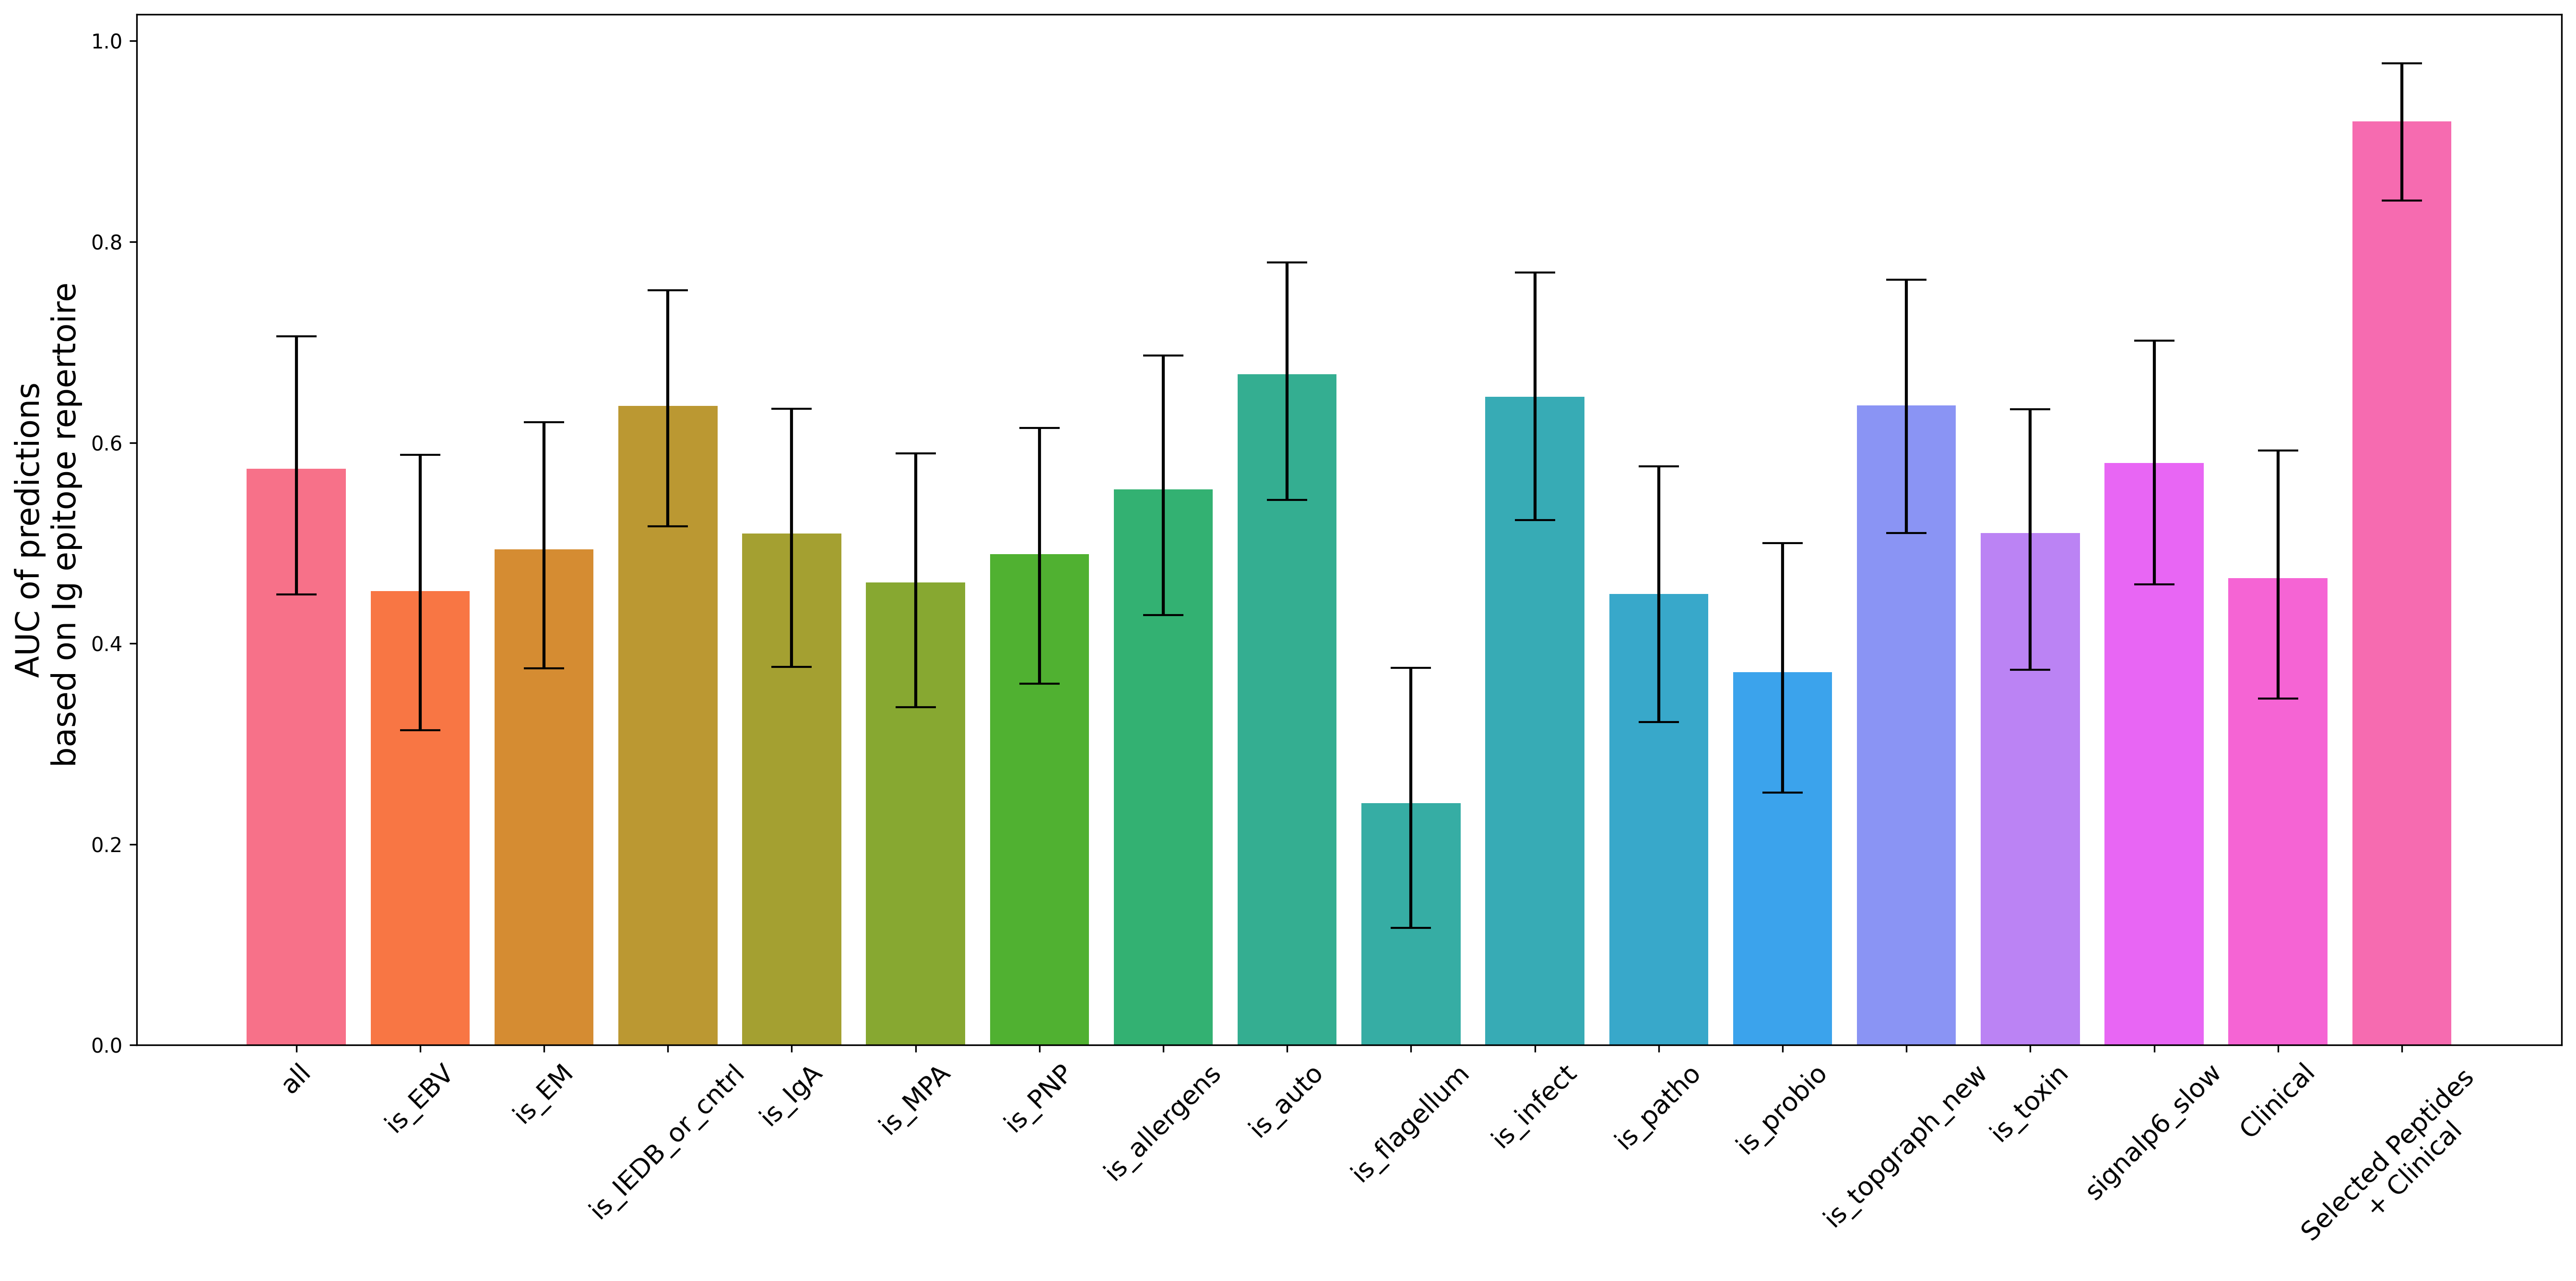

In [107]:
# Número de subgrupos para la paleta
n = len(best_thresholds) + 2

# Cálculo de las barras del IC
auc_means = np.append(best_thresholds['auc_mean'], grouped_clinical['auc_mean'])
auc_means = np.append(auc_means, best_selected['auc_mean'])

ci95_low = np.append(best_thresholds['ci95_low'], grouped_clinical['ci95_low'])
ci95_low = np.append(ci95_low, best_selected['ci95_low'])

ci95_high = np.append(best_thresholds['ci95_high'], grouped_clinical['ci95_high'])
ci95_high = np.append(ci95_high, best_selected['ci95_high'])

yerr = np.array([
    auc_means - ci95_low,
    ci95_high - auc_means
])

x_labels = list(best_thresholds['subgroup']) + ['Clinical'] + ['Selected Peptides \n + Clinical']

plt.figure(figsize=(18, 9), dpi=300)

bars = plt.bar(
    x_labels,
    auc_means,
    yerr=yerr,
    capsize=10,
    color=sns.color_palette("husl", n_colors=n),
)

plt.ylabel('AUC of predictions\n based on Ig epitope repertoire', fontsize=16)
plt.xticks(rotation=45, fontsize=13)
plt.tight_layout()
plt.show()

## Curva ROC

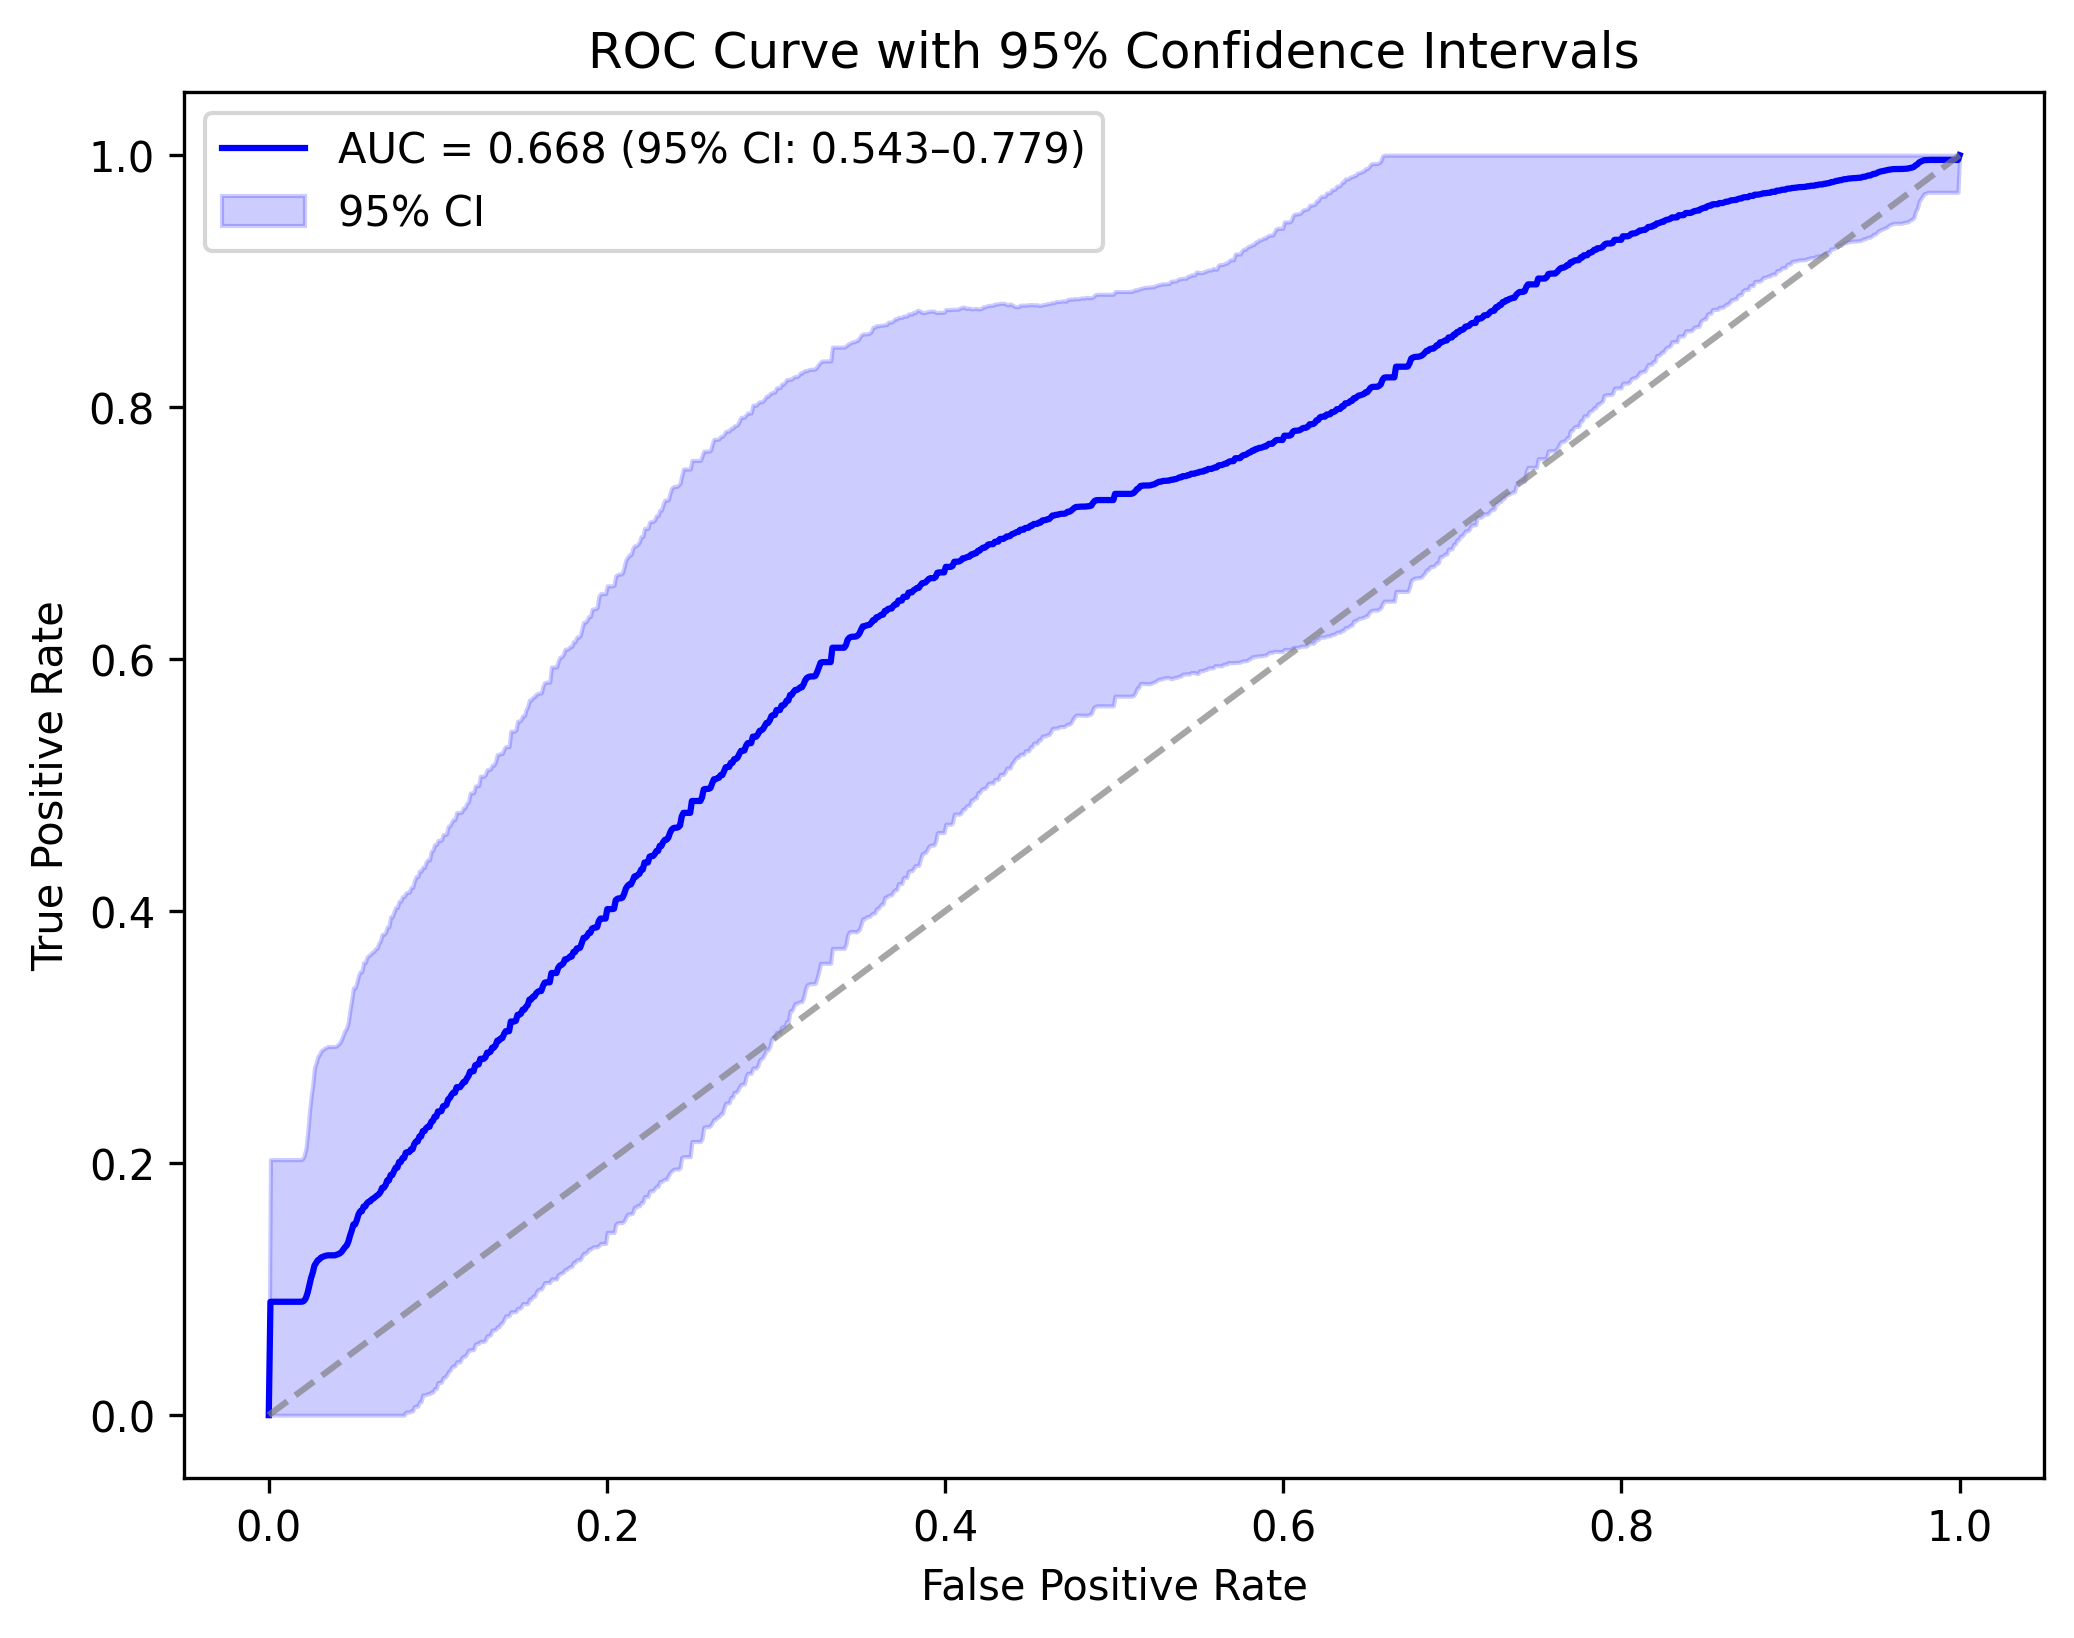

In [32]:
# Obtener bootstraps subrgrupo de interés
subset = bootstrap_exist[
    (bootstrap_exist['subgroup'] == 'is_auto') &
    (bootstrap_exist['threshold_percent'] == 20)
]

# Obtener estadísticas del grupo de interés
row_stats = best_thresholds[
    (best_thresholds['subgroup'] == 'is_auto') &
    (best_thresholds['threshold_percent'] == 20)
].iloc[0]

auc_mean  = row_stats['auc_mean']
ci95_low  = row_stats['ci95_low']
ci95_high = row_stats['ci95_high']

# Grid de FPR
fpr_mean = np.linspace(0, 1, 1000)

# Lista para guardar cada curva interpolada a la grilla común
interp_tprs = []

# Se recorre cada tupla de fpr y tpr 
for fpr, tpr in zip(subset['fpr'], subset['tpr']):
    # Se interpola sobre la grilla común
    interp_tpr = np.interp(fpr_mean, fpr, tpr)
    # Se fuerza que el primer punto de la curva sea (0,0)
    interp_tpr[0] = 0.0
    # Se guarda la curva a la lista
    interp_tprs.append(interp_tpr)

# Obtención de la curva ROC promedio
tpr_mean = np.mean(interp_tprs, axis=0)
tpr_std   = 1.96 * np.std(interp_tprs, axis=0)
tpr_upper = np.clip(tpr_mean + tpr_std, 0, 1)
tpr_lower = np.clip(tpr_mean - tpr_std, 0, 1)

plt.figure(figsize=(8, 6), dpi=300)
plt.plot(
    fpr_mean, tpr_mean,
    color='blue', alpha=1.0,
    label=f'AUC = {auc_mean:.3f} (95% CI: {ci95_low:.3f}–{ci95_high:.3f})'
)
plt.fill_between(fpr_mean, tpr_lower, tpr_upper, color='blue', alpha=0.2, label='95% CI')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with 95% Confidence Intervals')
plt.legend()
plt.show()

# Mejor resultado

In [33]:
metadata['appendectomy'] = metadata['appendectomy'].map({'Yes': 1, 'No': 0})

smoking_mapping = {
    'Never': 0,
    'Ex_smoker': 1,
    'Current_smoker': 2
}

metadata['smoking_encoded'] = metadata['smoking'].map(smoking_mapping)

metadata['sex_binary'] = metadata['sex'].map({'Female': 1, 'Male': 0})

In [34]:
# Generador de números aleatorios
rng = np.random.default_rng(42)

# Diccionario de configs
configs = {
    'Only peptides': [],
    'Peptides + Smoking and Appendectomy': ['smoking_encoded', 'appendectomy'],
    'Peptides + Age and Sex': ['age', 'sex_binary'],
    'Peptides + All Clinical': ['age', 'sex_binary', 'smoking_encoded', 'appendectomy'],
    'Peptides + Smoking': ['smoking_encoded'],
    'Peptides + Appendectomy': ['appendectomy'],
    'Only Smoking No Peptides': ['smoking_encoded']
}

# Resultados
original_records_best = []
bootstrap_records_best = []

# Subgrupo que te interesa
subgroup_name = "is_auto"
threshold = 20

# Iterar sobre configs
for config_name, config_vars in configs.items():
    
    # --- Construir dataframe con variables clínicas ---
    if config_name == "Only Smoking No Peptides":
        # solo variables clínicas, sin péptidos
        df = metadata[config_vars + ["disease"]].copy()
    else:
        # agregar variables clínicas al df de péptidos (is_auto threshold=20)
        df = add_clinical_variables(subgroup_dfs[subgroup_name], metadata, config_vars)
    
    # --- Modelo ---
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "max_depth": 3,
        "eta": 0.1,
        "seed": 100,
        "alpha": 0.2
    }
    xgb_model = XGBClassifier(**params, random_state=42)

    # Filtrar datos al threshold de interés
    preds = get_predictions_for_all_thresholds(xgb_model, df, thresholds=[threshold])
    group_df = preds.loc[threshold]

    # -----------------
    # Original ROC
    # -----------------
    fpr_OG, tpr_OG, thresholds_roc_OG = roc_curve(group_df["true_label"], group_df["proba"])
    auc_OG = roc_auc_score(group_df["true_label"], group_df["proba"])

    original_records_best.append({
        "config": config_name,
        "subgroup": subgroup_name,
        "threshold_percent": threshold,
        "fpr": fpr_OG,
        "tpr": tpr_OG,
        "auc": auc_OG,
        "num_peptides": group_df["num_peptides"].iloc[0] if "num_peptides" in group_df else None
    })

    # -----------------
    # Bootstrap ROC
    # -----------------
    for i in range(1000):
        sample = group_df.sample(n=len(group_df), replace=True, random_state=rng)
        try:
            y_true = sample["true_label"]
            y_score = sample["proba"]
            auc_val = roc_auc_score(y_true, y_score)
            fpr, tpr, thresholds_roc = roc_curve(y_true, y_score)

            bootstrap_records_best.append({
                "config": config_name,
                "subgroup": subgroup_name,
                "threshold_percent": threshold,
                "fpr": fpr,
                "tpr": tpr,
                "auc": auc_val,
                "num_peptides": group_df["num_peptides"].iloc[0] if "num_peptides" in group_df else None
            })
        except ValueError:
            continue

# DataFrames finales
original_exist_best = pd.DataFrame(original_records_best)
bootstrap_exist_best = pd.DataFrame(bootstrap_records_best)

In [35]:
# Se agrupan los datos de AUC de cada threshold para cada subgrupo
grouped_best = bootstrap_exist_best.groupby(["config"])["auc"].apply(list).reset_index()

grouped_best[["auc_mean", "ci95_low", "ci95_high", "std"]] = grouped_best["auc"].apply(
    lambda x: pd.Series(mean_ci95(x))
)

best_thresholds = grouped_best.loc[grouped_best.groupby("config")["auc_mean"].idxmax()].reset_index(drop=True)

In [37]:
best_thresholds

,config,auc,auc_mean,ci95_low,ci95_high,std
0,Only Smoking No Peptides,"[0.42391304347826086, 0.6296992481203008, 0.58...",0.501437,0.350066,0.645650,0.074078
1,Only peptides,"[0.7404627892432771, 0.576388888888889, 0.6774...",0.667895,0.542315,0.788182,0.061913
2,Peptides + Age and Sex,"[0.5394736842105263, 0.5031328320802004, 0.522...",0.620989,0.497185,0.750489,0.064642
3,Peptides + All Clinical,"[0.75, 0.6881313131313131, 0.7938403519798869,...",0.683423,0.567183,0.794485,0.058857
4,Peptides + Appendectomy,"[0.7196969696969697, 0.6453634085213033, 0.551...",0.610264,0.479646,0.738169,0.066360
5,Peptides + Smoking,"[0.77125, 0.6131249999999999, 0.77398989898989...",0.745644,0.636688,0.853563,0.054907
6,Peptides + Smoking and Appendectomy,"[0.7847222222222222, 0.7436868686868687, 0.689...",0.755549,0.642258,0.854300,0.053403


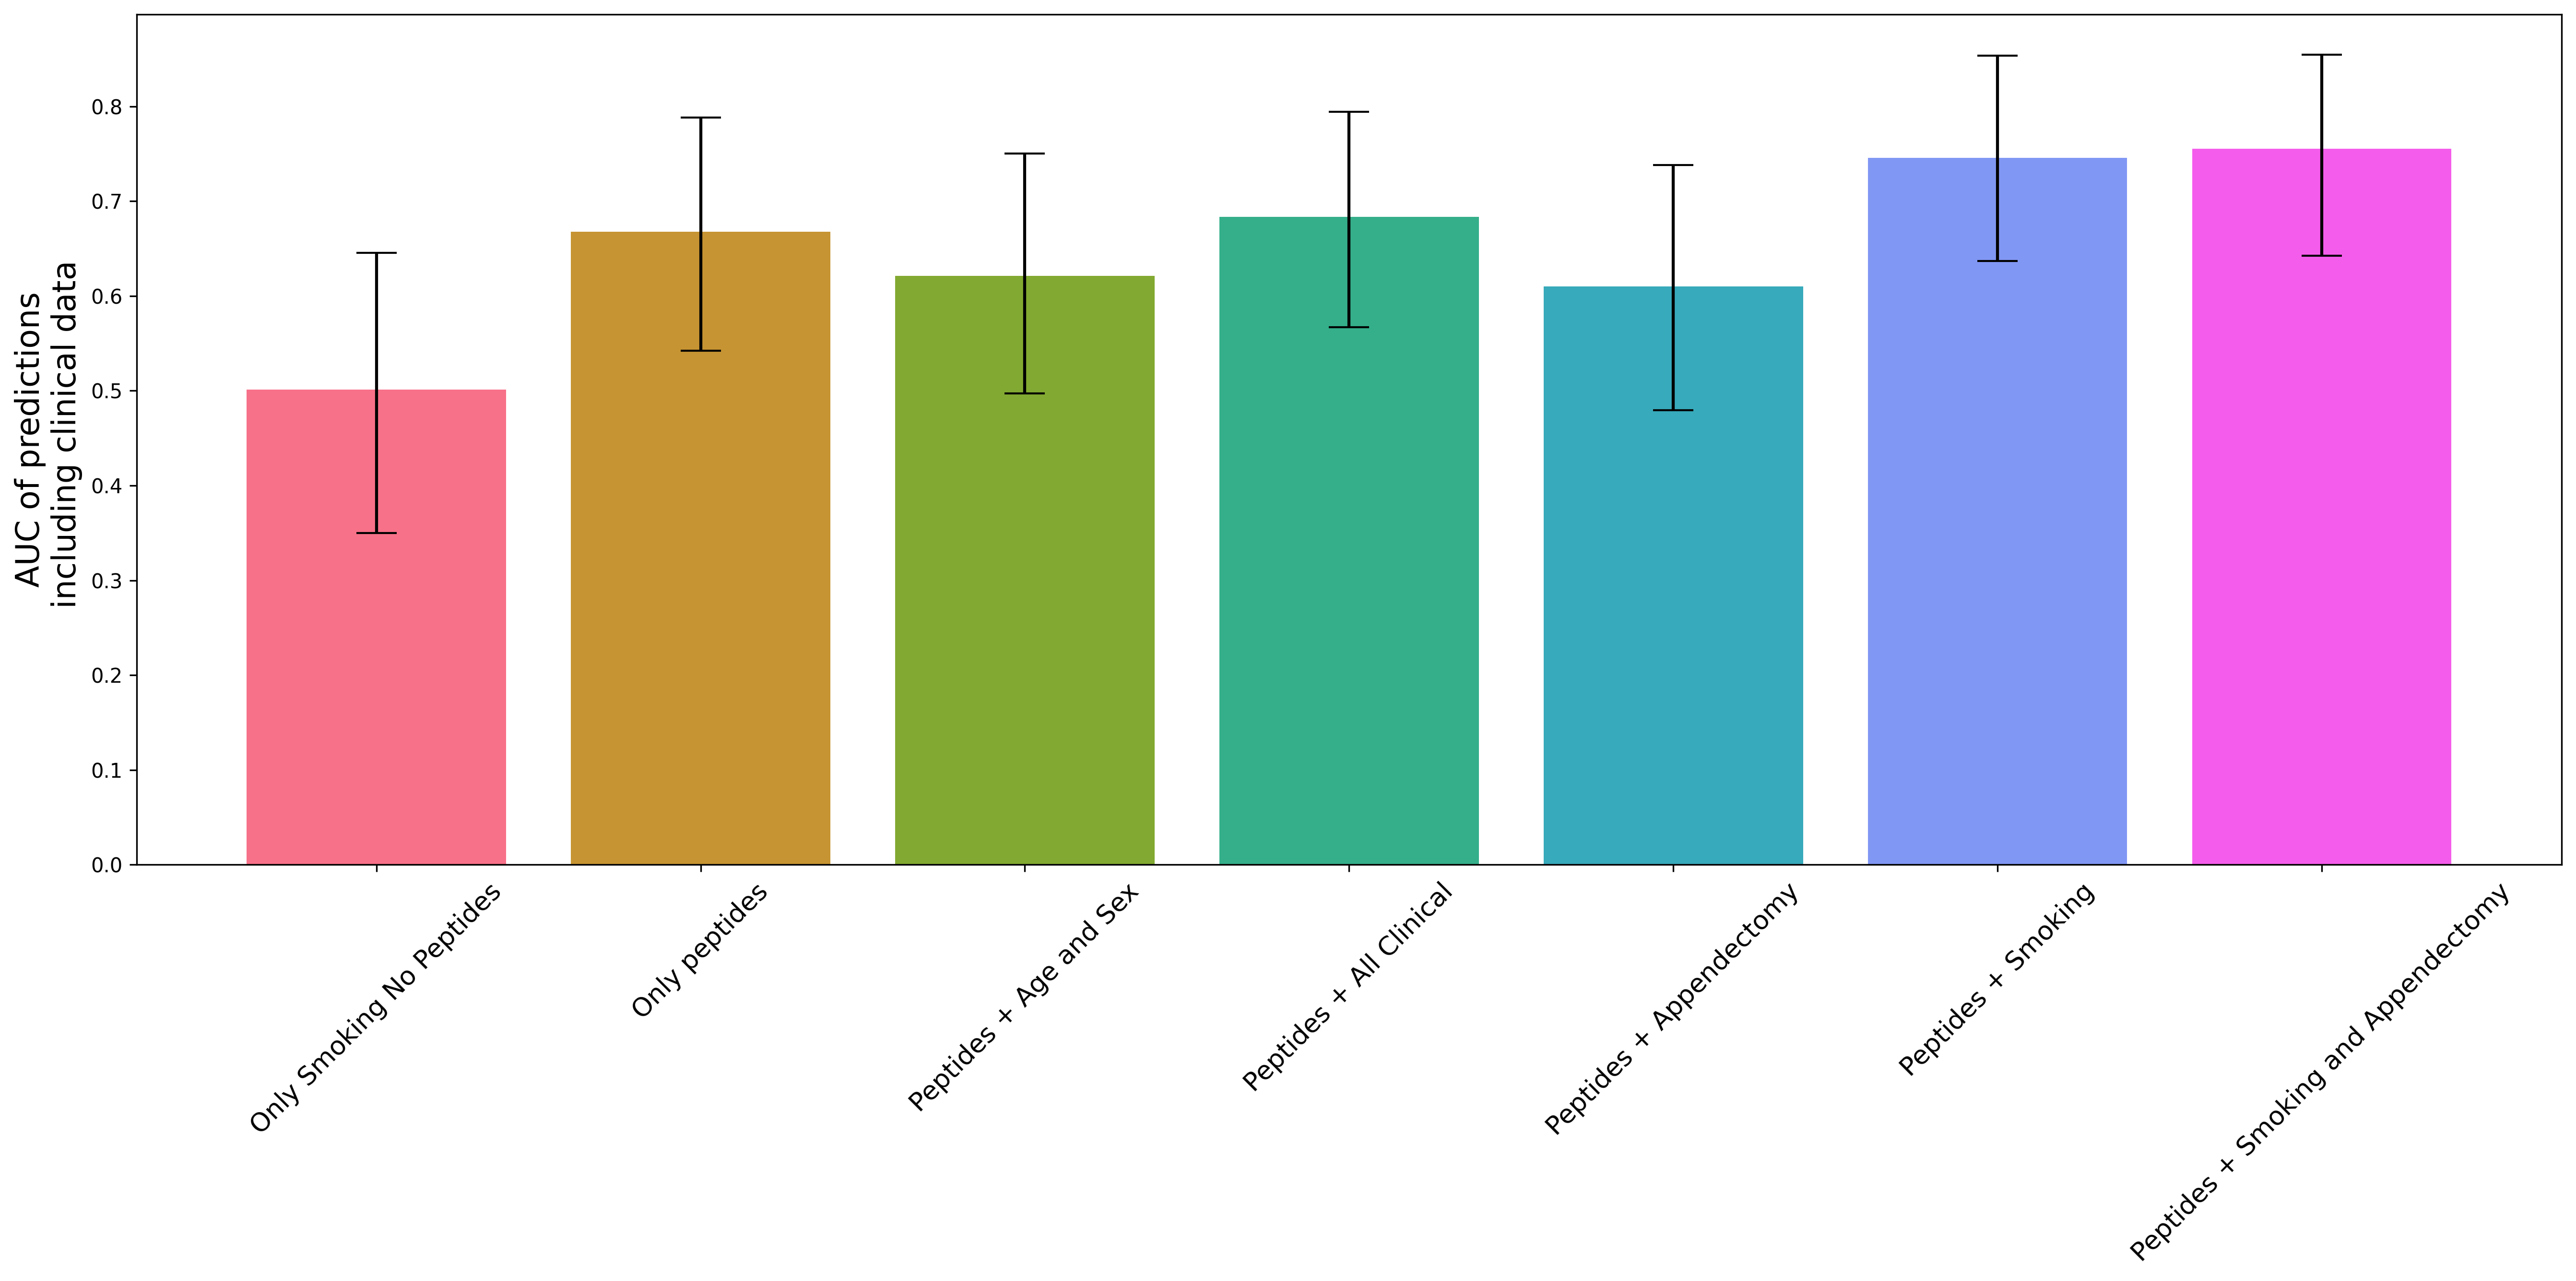

In [39]:
# Número de subgrupos para la paleta
n = len(best_thresholds)

# Se calculan las barras del IC
yerr = np.array([
    best_thresholds['auc_mean'] - best_thresholds['ci95_low'],
    best_thresholds['ci95_high'] - best_thresholds['auc_mean']
])

plt.figure(figsize=(18, 9), dpi=300)

# Gráfico
bars = plt.bar(
    best_thresholds['config'],
    best_thresholds['auc_mean'],
    yerr=yerr,
    capsize=10,
    color=sns.color_palette("husl", n_colors=n),
)

plt.ylabel('AUC of predictions\n including clinical data', fontsize=16)
plt.xticks(rotation=45, fontsize=13)
plt.tight_layout()
plt.show()

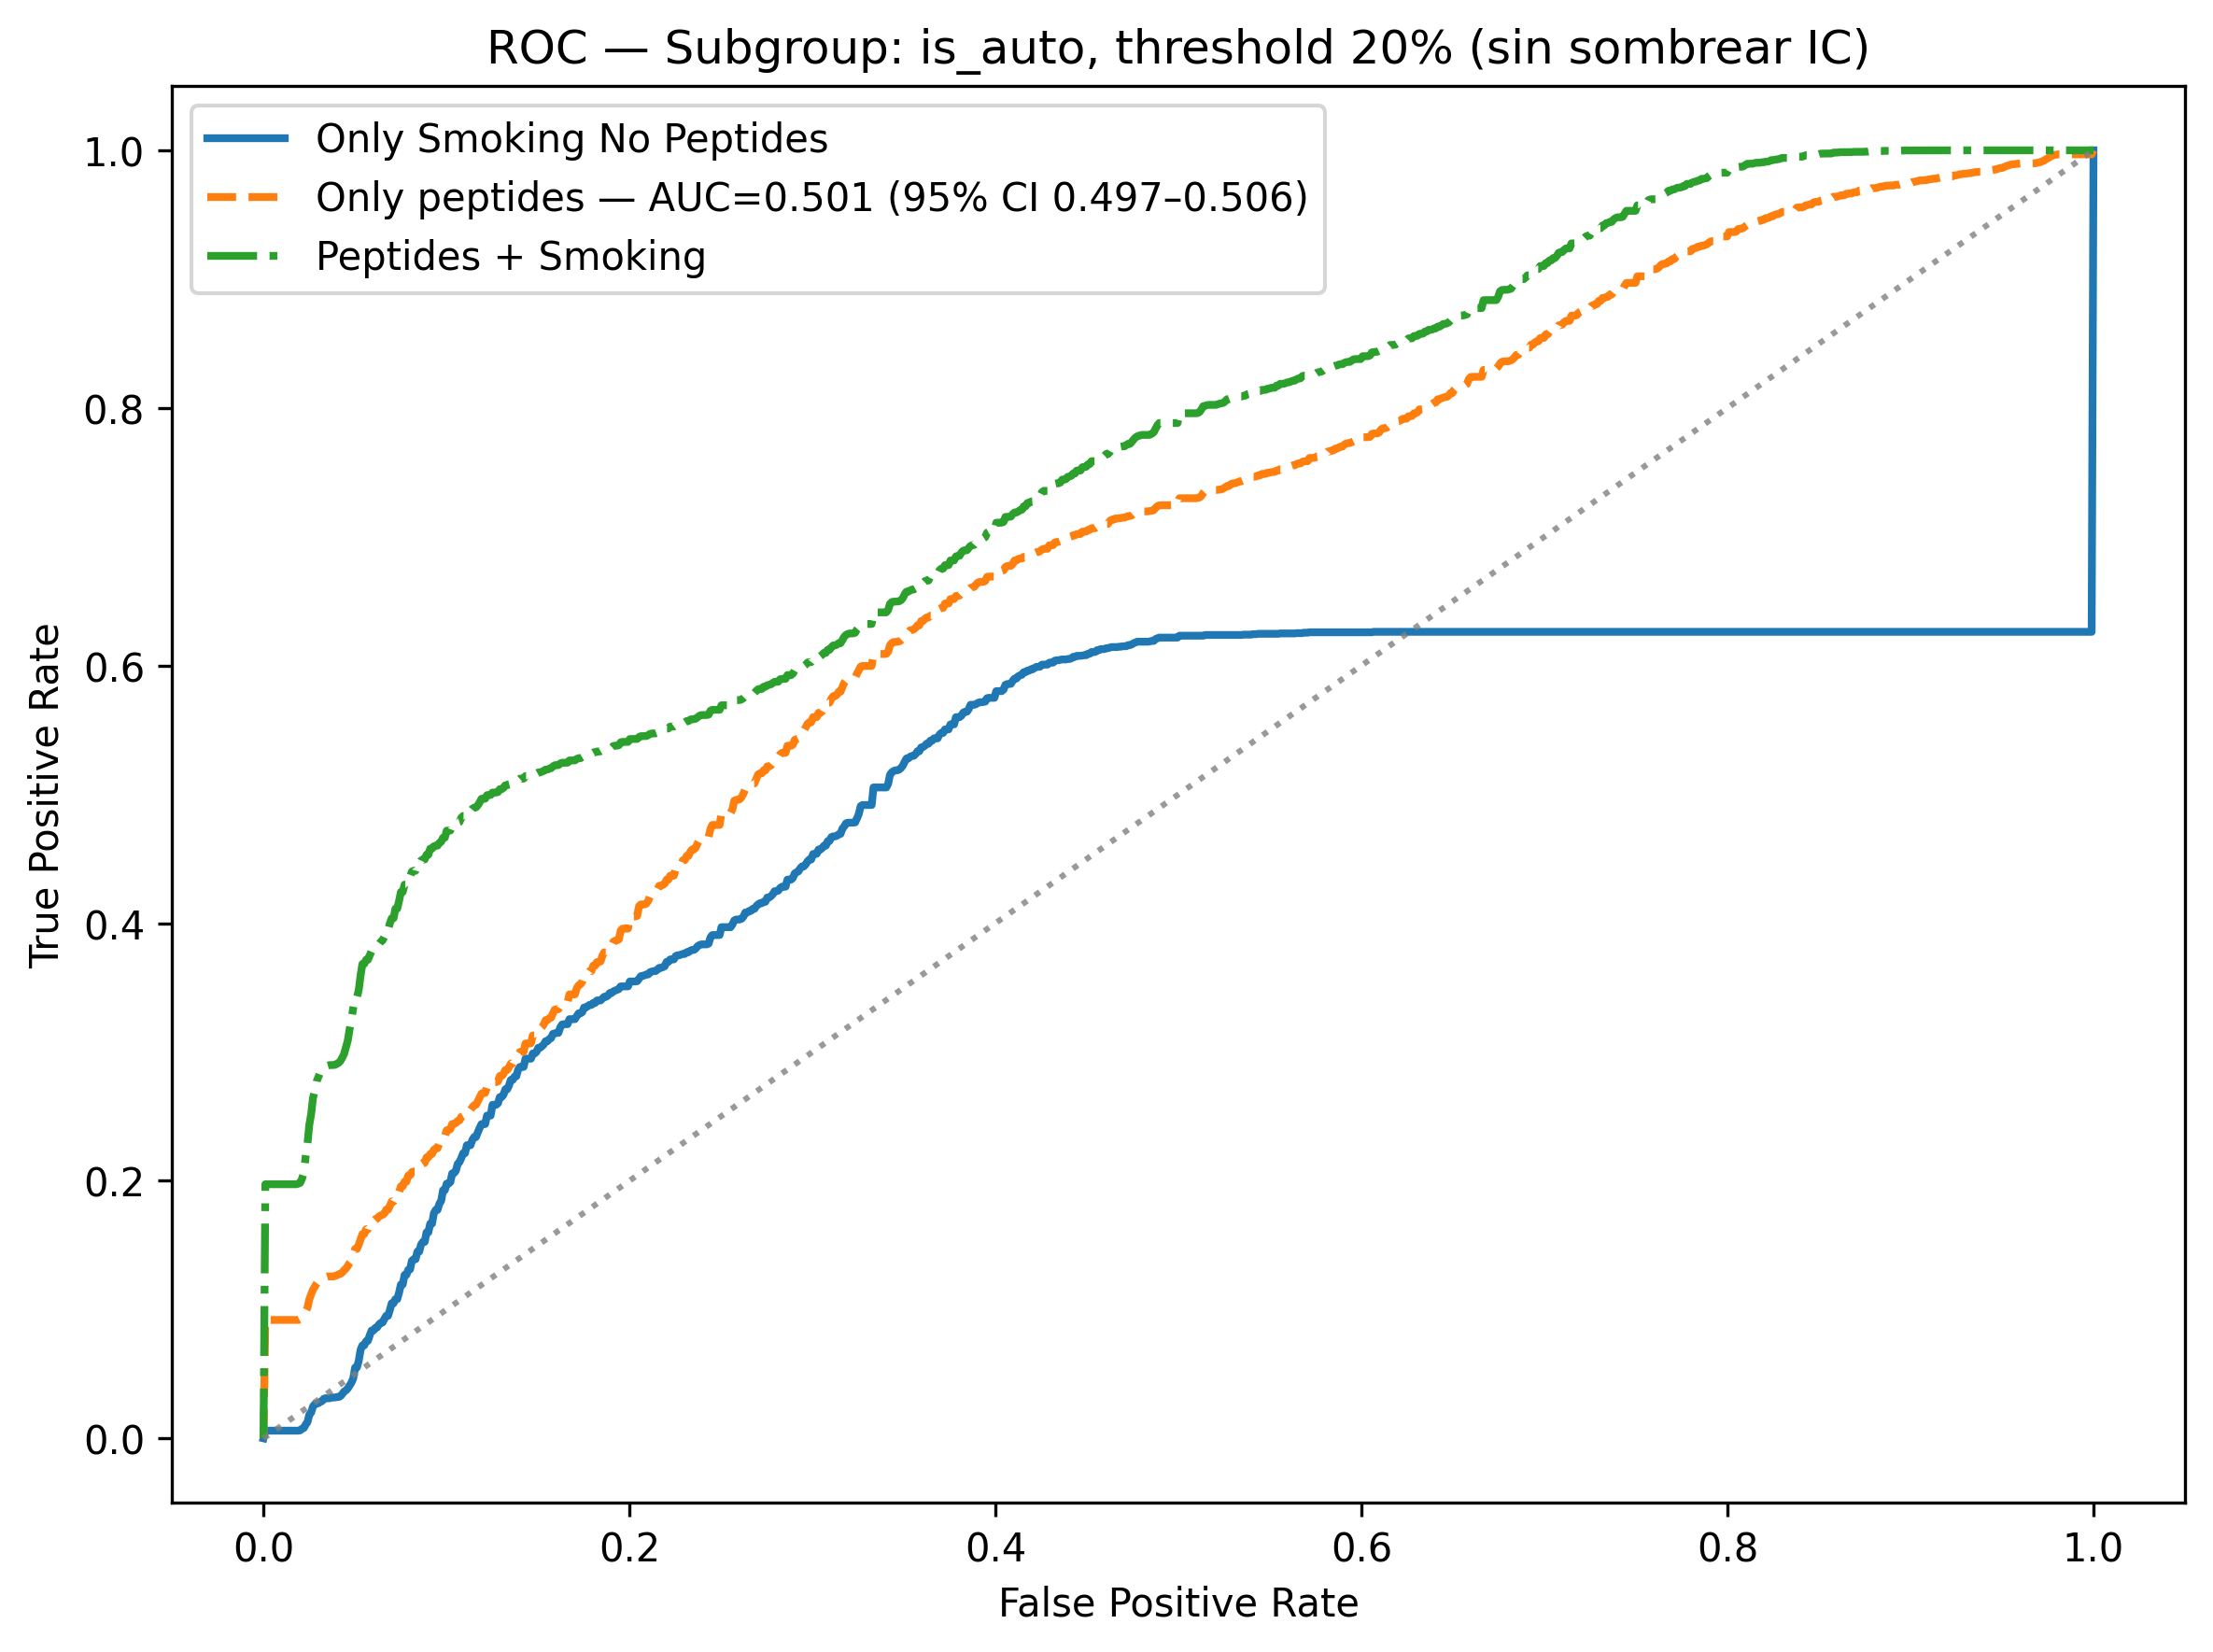

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- parámetros del filtro ---
SUBGROUP = 'is_auto'
THR = 20
CONFIGS_TO_PLOT = [
    "Only Smoking No Peptides",
    "Only peptides",
    "Peptides + Smoking",
]

# Detecta el nombre correcto de la columna de config(s)
cfg_col = 'configs' if 'configs' in bootstrap_exist_best.columns else 'config'

# Rejilla común de FPR
fpr_mean = np.linspace(0, 1, 1000)

def mean_roc_on_grid(df):
    """Interpola todas las curvas de df a fpr_mean y devuelve la TPR promedio."""
    interp_tprs = []
    for fpr, tpr in zip(df['fpr'], df['tpr']):
        fpr = np.asarray(fpr)
        tpr = np.asarray(tpr)
        interp_tpr = np.interp(fpr_mean, fpr, tpr)
        interp_tpr[0] = 0.0  # fuerza origen (0,0)
        interp_tprs.append(interp_tpr)
    if len(interp_tprs) == 0:
        return None
    return np.mean(interp_tprs, axis=0)

# Estilos para distinguir curvas (sin sombrear IC)
line_styles = ['-', '--', '-.']  # se ciclan si hay más de 3
line_width = 2.0

plt.figure(figsize=(8, 6), dpi=300)

for i, cfg in enumerate(CONFIGS_TO_PLOT):
    # Subset para bootstraps de esa config
    mask_boot = (
        (bootstrap_exist_best[cfg_col] == cfg)
    )
    subset = bootstrap_exist_best.loc[mask_boot]

    tpr_mean = mean_roc_on_grid(subset)
    if tpr_mean is None:
        print(f"[AVISO] No hay bootstraps para '{cfg}'. Se omite.")
        continue

    # Stats (AUC e IC) desde best_thresholds para esa config
    mask_stats = (
        (bootstrap_exist_best[cfg_col] == cfg)
    )
    row_stats = best_thresholds.loc[mask_stats].head(1)

    if row_stats.empty:
        label = f"{cfg}"
    else:
        auc_mean  = row_stats['auc_mean'].iloc[0]
        ci95_low  = row_stats['ci95_low'].iloc[0]
        ci95_high = row_stats['ci95_high'].iloc[0]
        label = f"{cfg} — AUC={auc_mean:.3f} (95% CI {ci95_low:.3f}–{ci95_high:.3f})"

    plt.plot(
        fpr_mean, tpr_mean,
        linestyle=line_styles[i % len(line_styles)],
        linewidth=line_width,
        label=label
    )

# Diagonal aleatoria
plt.plot([0, 1], [0, 1], linestyle=':', color='gray', alpha=0.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC — Subgroup: {SUBGROUP}, threshold {THR}% (sin sombrear IC)')
plt.legend()
plt.tight_layout()
plt.show()


# Gráficos iniciales

## b)

In [120]:
bins = [20, 30, 40, 50, 60, 70]
labels = [25, 35, 45, 55, 65]

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

counts = df.groupby(['age_group', 'type_person', 'sex']).size().reset_index(name="count")
pivot = counts.pivot_table(index='age_group', columns=['type_person', 'sex'], values='count')

age_groups = pivot.index.astype(int)
control_male   = pivot[("Control","Male")].values
control_female = pivot[("Control","Female")].values
disease_male   = pivot[("Disease","Male")].values
disease_female = pivot[("Disease","Female")].values

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_7406/3742077007.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['age_group', 'type_person', 'sex']).size().reset_index(name="count")
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_7406/3742077007.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = counts.pivot_table(index='age_group', columns=['type_person', 'sex'], values='count')


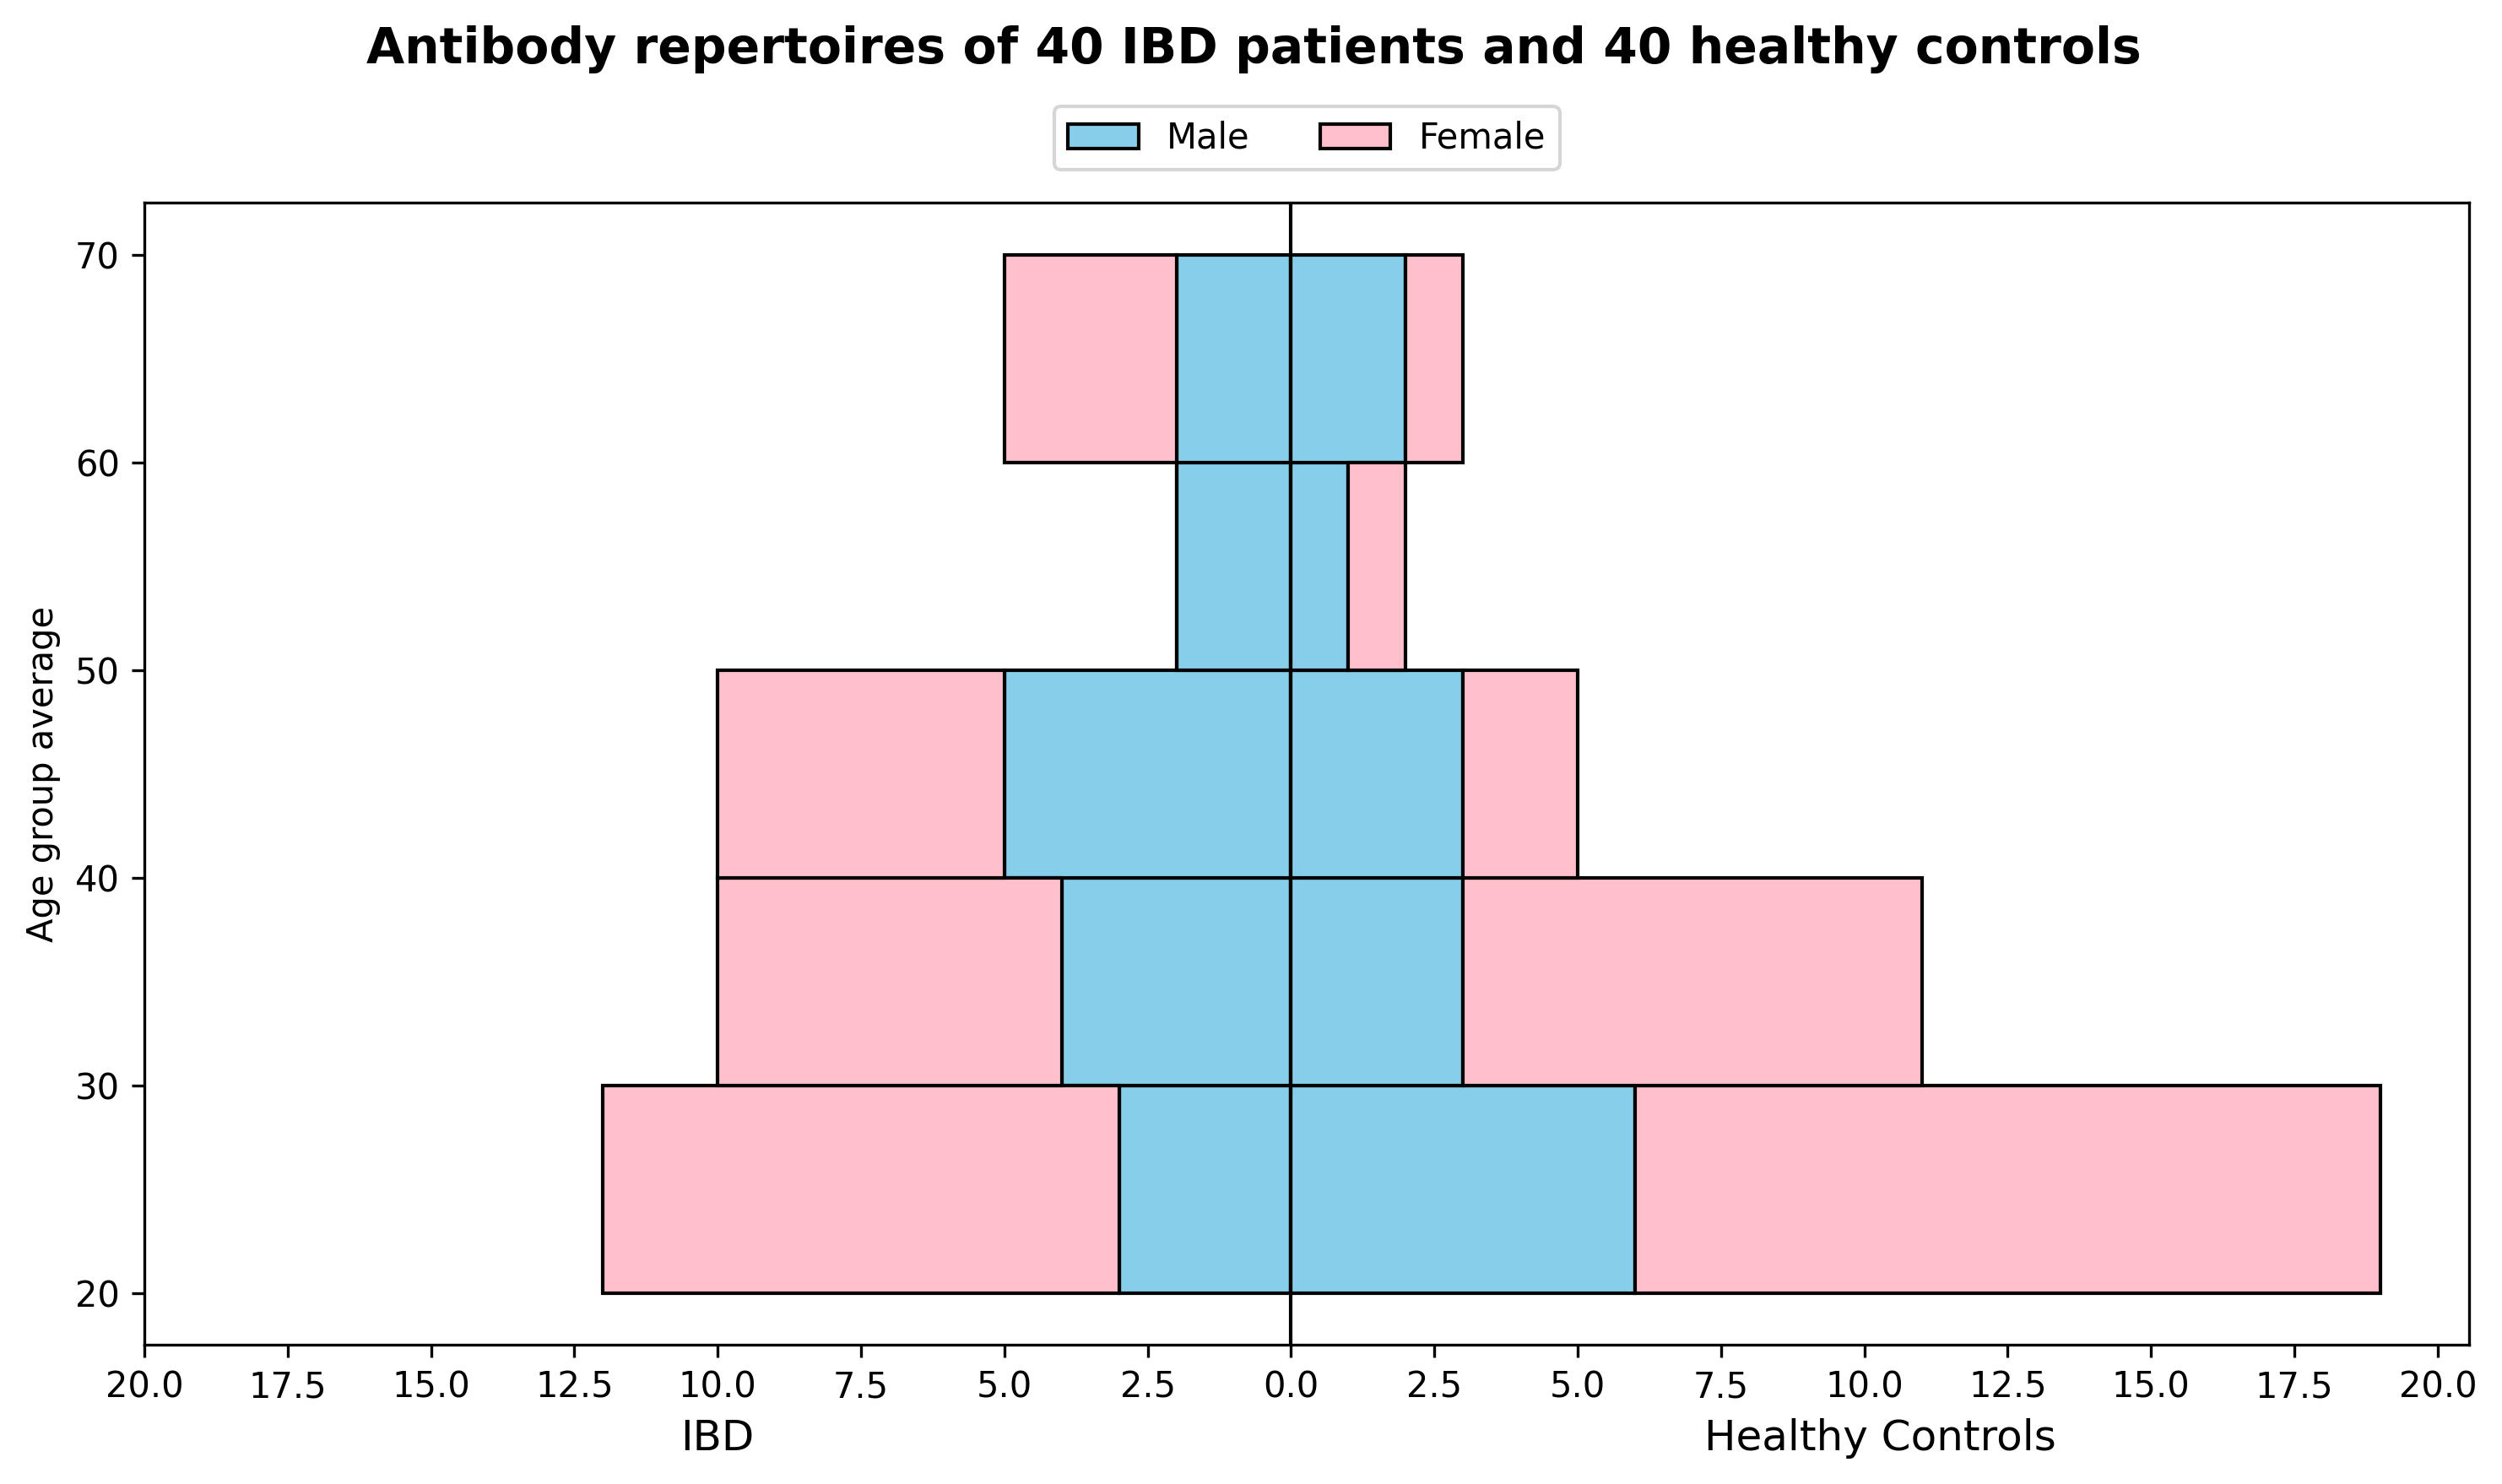

In [121]:
fig, ax = plt.subplots(figsize=(10,6), dpi=300)

# Disease 
ax.barh(age_groups, -disease_male, 
        color='skyblue', height=10, edgecolor='black')
ax.barh(age_groups, -disease_female, 
        left=[-x for x in disease_male], color='pink', height=10, edgecolor='black')

# Control
ax.barh(age_groups, control_male, 
        color='skyblue', height=10, edgecolor='black')
ax.barh(age_groups, control_female, 
        left=control_male, color='pink', height=10, edgecolor='black')

ax.set_ylabel('Age group average')

xticks = np.arange(-20, 20.1, 2.5)
ax.set_xticks(xticks)
ax.set_xticklabels([f'{abs(x):.1f}' for x in xticks]) 

ax.axvline(0, color='black', linewidth=1)  

handles = [
    mpatches.Patch(facecolor='skyblue', edgecolor='black', label='Male'),
    mpatches.Patch(facecolor='pink', edgecolor='black', label='Female')
]
ax.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1))

fig.suptitle('Antibody repertoires of 40 IBD patients and 40 healthy controls', y=0.97, fontsize=14, fontweight='bold')

xlim = ax.get_xlim()

ylim = ax.get_ylim()
y_text = ylim[0] - 4.5

mid_left = (xlim[0] + 0) / 2 
mid_right = (0 + xlim[1]) / 2 

ax.text(mid_left, y_text, 'IBD', ha='center', va='center', fontsize=12)
ax.text(mid_right, y_text, 'Healthy Controls', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()


## e)

In [3]:
y = df['disease']
y.index = exist_data.index

In [4]:
# unir features + labels
df = pd.concat([exist_data, y], axis=1)

# agrupar por clase (0 = control, 1 = enfermedad) y sumar respuestas
df = df.groupby('disease').sum()

# eliminar columnas que son cero en al menos un grupo
df = df.loc[:, df.ne(0).all()].copy()

df.head()

,agilent_10,agilent_100240,agilent_100279,agilent_100413,agilent_10079,agilent_10081,agilent_100835,agilent_100979,agilent_101,agilent_101070,...,twist_982,twist_98450,twist_98770,twist_9883,twist_99129,twist_99298,twist_99385,twist_99399,twist_99693,twist_99804
disease,,,,,,,,,,,,,,,,,,,,,
0,1,2,1,2,1,1,1,1,4,2,...,1,1,8,2,1,1,6,1,7,1
1,1,3,2,5,3,4,1,1,5,1,...,1,1,5,1,1,1,3,1,7,3


In [10]:
# seleccionar automáticamente todas las columnas que comienzan con 'is_'
oligo_families = [c for c in peptide_info.columns if c.startswith('is_') or c == 'signalp6_slow']

# quedarnos solo con esas columnas y las features que están en df
metadata = peptide_info[oligo_families].loc[df.columns]

# reemplazar NaN por False
metadata = metadata.fillna(False)

# añadir la categoría "Complete library"
metadata['all'] = True

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_2157/2047209533.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata = metadata.fillna(False)


In [11]:
metadata_long = metadata.stack()
metadata_long = metadata_long[metadata_long].reset_index(level=-1).drop(columns=0)
metadata_long = metadata_long.rename(columns={'level_1': 'Oligo family'})

ratio_column = 'Ratios of antibody responses\nin IBD and healthy controls'
metadata_long[ratio_column] = df.apply(
    lambda oligo: oligo[1] / oligo[0] if oligo[0] != 0 else np.nan
)


/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_2157/3817388183.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

all vs. is_EBV: Custom statistical test, P_val:8.687e-04
is_EBV vs. is_EM: Custom statistical test, P_val:2.152e-03
is_EBV vs. is_IEDB_or_cntrl: Custom statistical test, P_val:4.850e-04
is_probio vs. is_toxin: Custom statistical test, P_val:9.879e-03
is_EBV vs. is_IgA: Custom statistical test, P_val:7.243e-04
is_EBV vs. is_MPA: Custom statistical test, P_val:1.184e-02
is_EBV vs. is_PNP: Custom statistical test, P_val:2.194e-03
is_EBV vs. is_allergens: Custom statistical test, P_val:1.801e-02
is_EBV vs. is_auto: Custom statistical test, P_val:3.805e-04
is_EBV vs. is_infect: Custom statistical test, P_val:4.243e-03
is_IEDB_or_cntrl vs. is_probio: Custom statistical test, P_val:4.778e-02
is_EBV vs. is_patho: Custom statistical test, P_val:3.146e-03
is_EBV vs. is_topgraph_new: Custom statistical test,

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_2157/3817388183.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


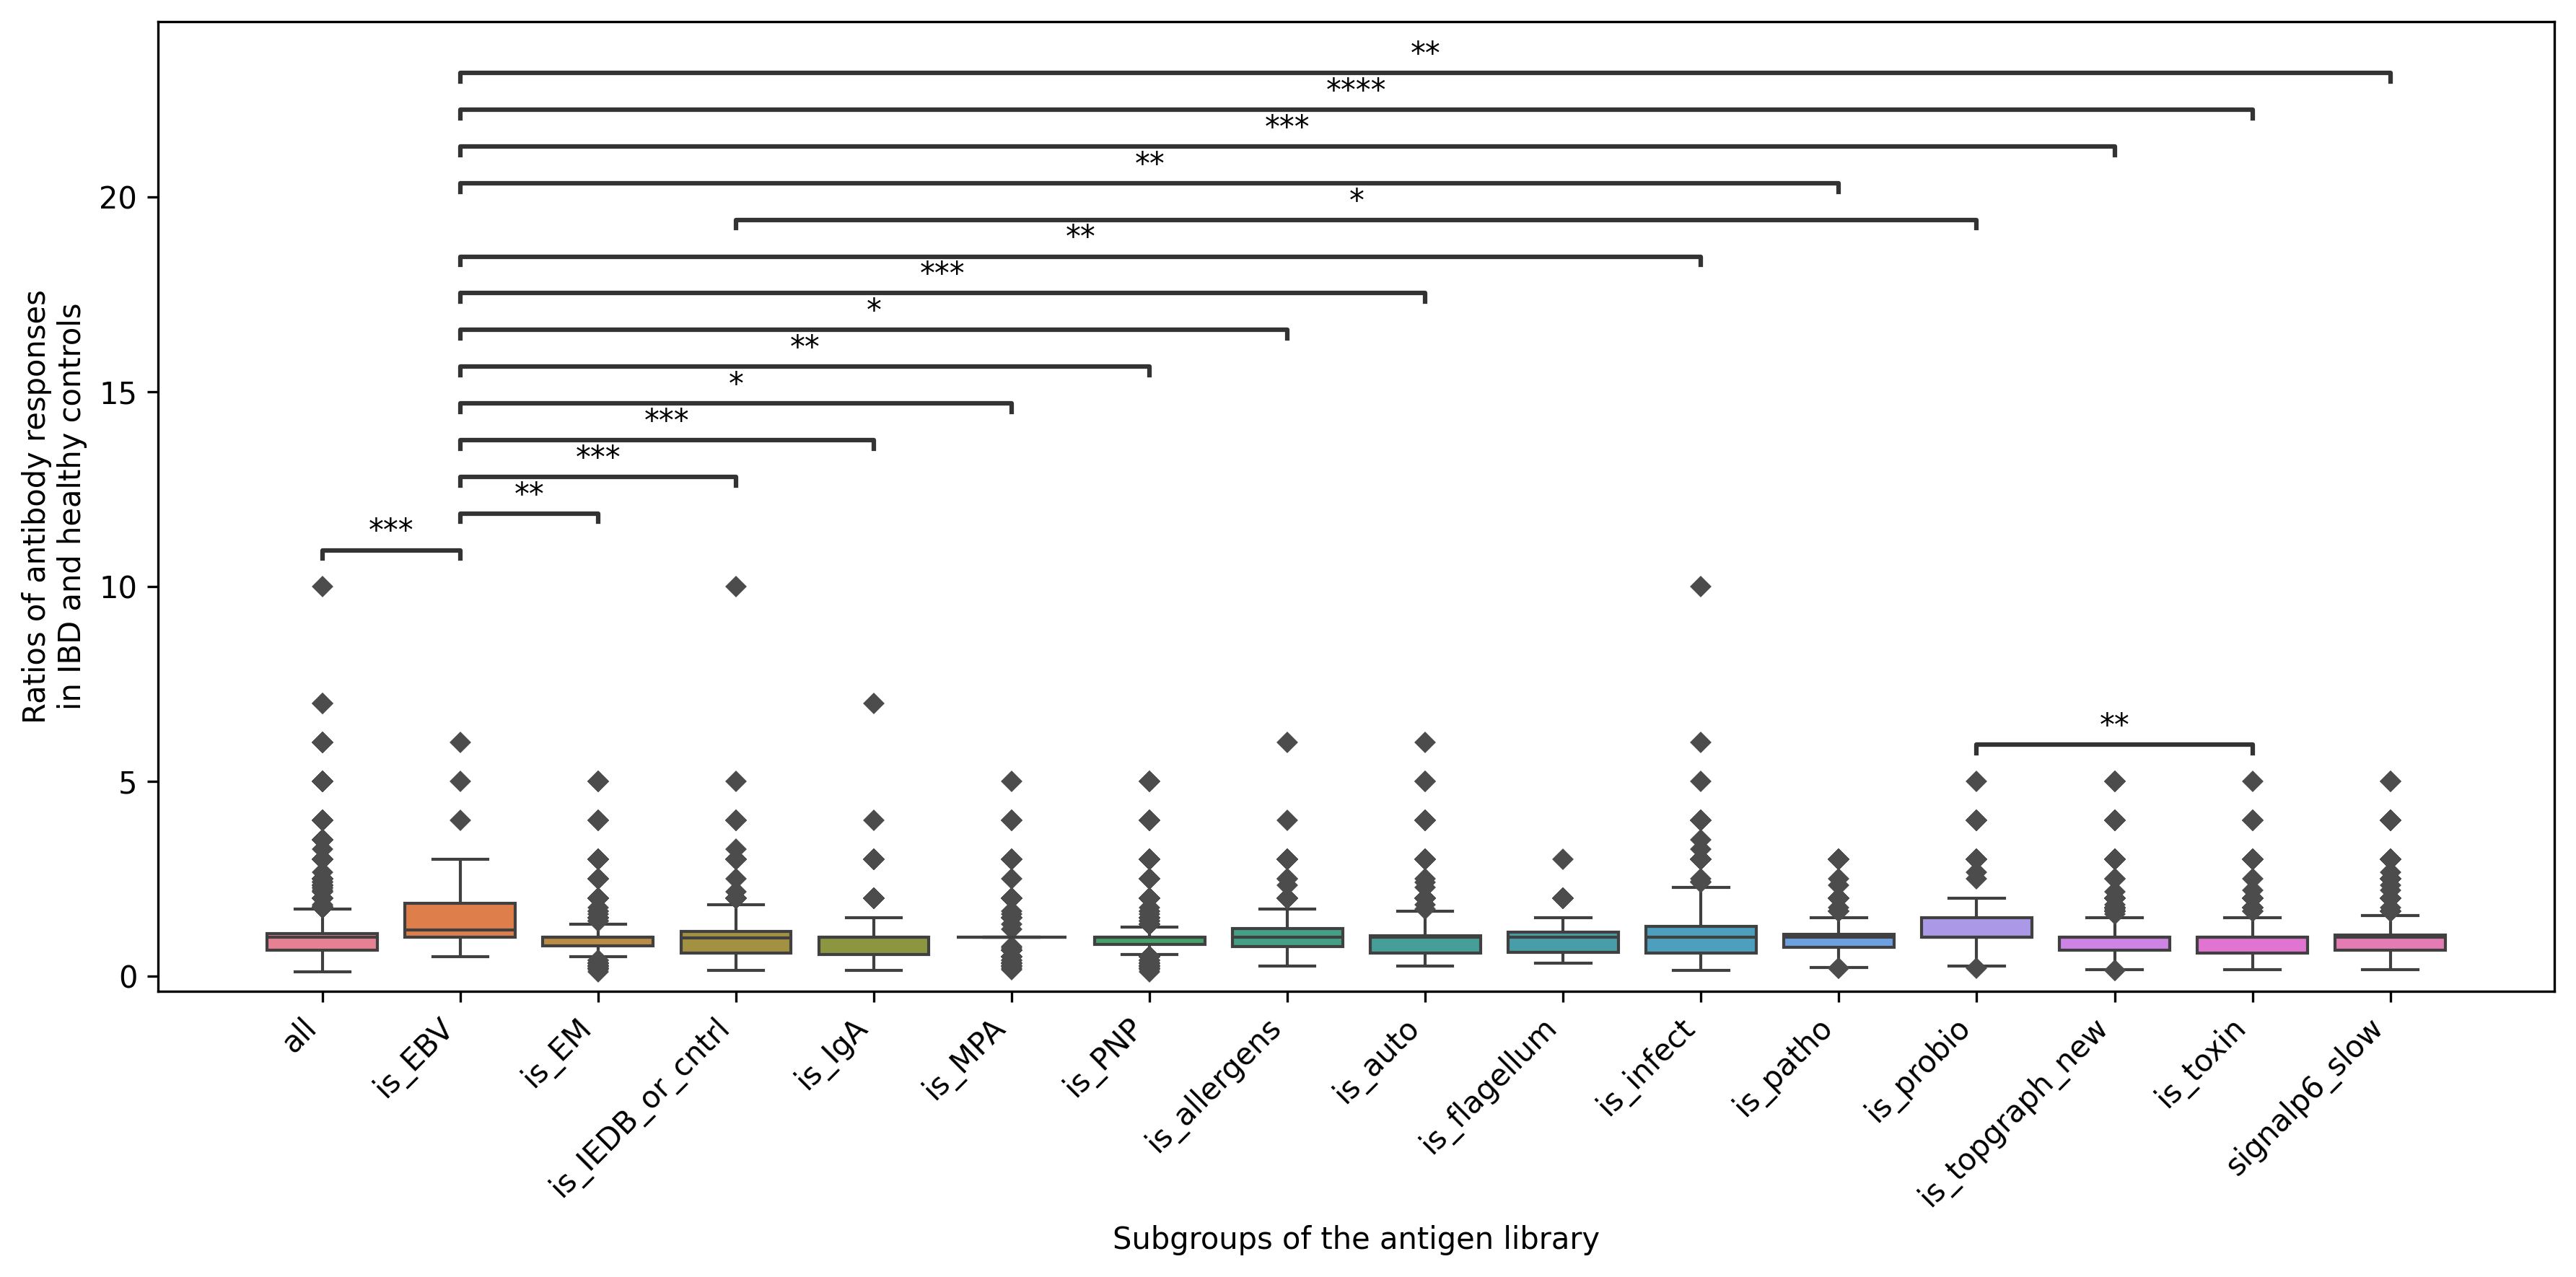

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import itertools
from statannotations.Annotator import Annotator
import pandas as pd

# nombre de la columna de ratio
ratio_column = 'Ratios of antibody responses\nin IBD and healthy controls'

order = [
    "all", "is_EBV", "is_EM", "is_IEDB_or_cntrl", "is_IgA", "is_MPA", 
    "is_PNP", "is_allergens", "is_auto", "is_flagellum", 
    "is_infect", "is_patho", "is_probio", "is_topgraph_new", 
    "is_toxin", "signalp6_slow"
]

# Definir paleta con husl
palette = sns.color_palette("husl", len(order))

flierprops = dict(
    marker='D',         # D = rombo
    markerfacecolor='#4c4c4c',
    markeredgecolor='#4c4c4c',
    markersize=4,       # tamaño de los rombos
    linestyle='none'    # que no haya línea conectándolos
)

# 1. Boxplot base
fig, ax = plt.subplots(figsize=(12,6), dpi=300)
sns.boxplot(
    data=metadata_long,
    x='Oligo family',
    y=ratio_column,
    order=order,
    ax=ax,
    palette=palette,
    flierprops=flierprops
)

# 2. Estadística: Mann–Whitney U para cada par
pval_res = {}
for b1, b2 in itertools.combinations(order, 2):
    d1 = metadata_long[metadata_long['Oligo family'] == b1][ratio_column]
    d2 = metadata_long[metadata_long['Oligo family'] == b2][ratio_column]
    if len(d1) > 0 and len(d2) > 0:
        stat, p = stats.mannwhitneyu(d1, d2)
        pval_res[(b1, b2)] = p

# 3. Corrección Bonferroni
pval_df = pd.DataFrame.from_dict(pval_res, orient='index', columns=['p_val'])
pval_df['passed_bonf'], pval_df['p_val_corr'], _, _ = multipletests(
    pval_df['p_val'], method='bonferroni'
)

# 4. Filtrar pares significativos
significant = pval_df[pval_df['passed_bonf']]

# 5. Preparar anotaciones
box_pairs = list(significant.index)
pvalues = list(significant['p_val_corr'])

annotator = Annotator(ax, box_pairs, data=metadata_long,
                      x='Oligo family', y=ratio_column, order=order)

annotator.configure(test=None, text_format='star', loc='inside')
annotator.set_pvalues(pvalues)
annotator.annotate()

# 6. Ajustes visuales
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('Subgroups of the antigen library')
ax.set_ylabel(ratio_column)
plt.tight_layout()
plt.show()


## Taxa plots

In [93]:
# Obtención columnas péptidos
df_all_peptides = subgroup_dfs['all']
peptide_cols = df_all_peptides.columns.drop('disease')

# Índices IBD y control
idx_IBD = subgroup_dfs['all']['disease'] == 1
idx_Ctrl = subgroup_dfs['all']['disease'] == 0

# Cálculo de porcentajes de presencia de péptido dentro de ambos grupos para cada péptido
mean_IBD = df_all_peptides.loc[idx_IBD, peptide_cols].mean()
mean_Ctrl = df_all_peptides.loc[idx_Ctrl, peptide_cols].mean()

# Cálculo log2 ratios 
ratios = []

for c, i in zip(mean_Ctrl, mean_IBD):
    if c == 0:
        ratios.append(i / 0.5)
    elif i == 0:
        ratios.append(0.5 / c)
    else:
        ratios.append(i / c)
log2_ratio = np.log2(ratios)

# df con resultados
ratios_df = pd.DataFrame({
    'peptide_name': peptide_cols,
    'log2_ratio_IBD_Control': log2_ratio,
    'ratio_IBD_Control': ratios,
    'mean_IBD': mean_IBD.values,
    'mean_Control': mean_Ctrl.values
})

In [94]:
all_species_cols = peptide_info['species']
all_genus_cols = peptide_info['genus']

In [95]:
new_ratios_df = pd.DataFrame({
    'peptide_name': peptide_cols,
    'ratio': ratios,
    'log2_ratio': log2_ratio,
    'species': all_species_cols,
    'genus': all_genus_cols,
    'mean_IBD': mean_IBD.values,
    'mean_Control': mean_Ctrl.values,
})

#### Species

In [102]:
new_ratios_df_species = violin_plot_preparation(new_ratios_df, 'species', 'ratio')
new_ratios_df_species.sort_values('p_adj_BH').head(10)

,species,n_peptides,mean_ratio,median_ratio,p_value,p_adj_BH
31,Arachis hypogaea,10,0.050000,0.05,0.000184,0.090312
63,Bacteroides thetaiotaomicron,35,4.650000,0.05,0.001222,0.120033
259,Lactobacillus acidophilus,85,11.150490,20.00,0.001225,0.120033
332,Oryza sativa,49,11.335611,20.00,0.000946,0.120033
4,Aegilops tauschii,31,12.331720,20.00,0.000654,0.120033
190,Felixounavirus felixO1,20,13.312500,20.00,0.001697,0.138613
221,Helicobacter pylori,70,9.704365,10.00,0.003175,0.196346
61,Bacteroides sp. D2,6,0.050000,0.05,0.003777,0.196346
180,Eubacterium sp. CAG:115,10,0.340000,0.05,0.004007,0.196346
148,Culicoides sonorensis,6,0.050000,0.05,0.003777,0.196346


In [104]:
top_species_all = new_ratios_df_species.sort_values('p_adj_BH').head(10)['species'].tolist()
new_ratios_df_species_filtered = new_ratios_df[new_ratios_df['species'].isin(top_species_all)]

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/2454548485.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


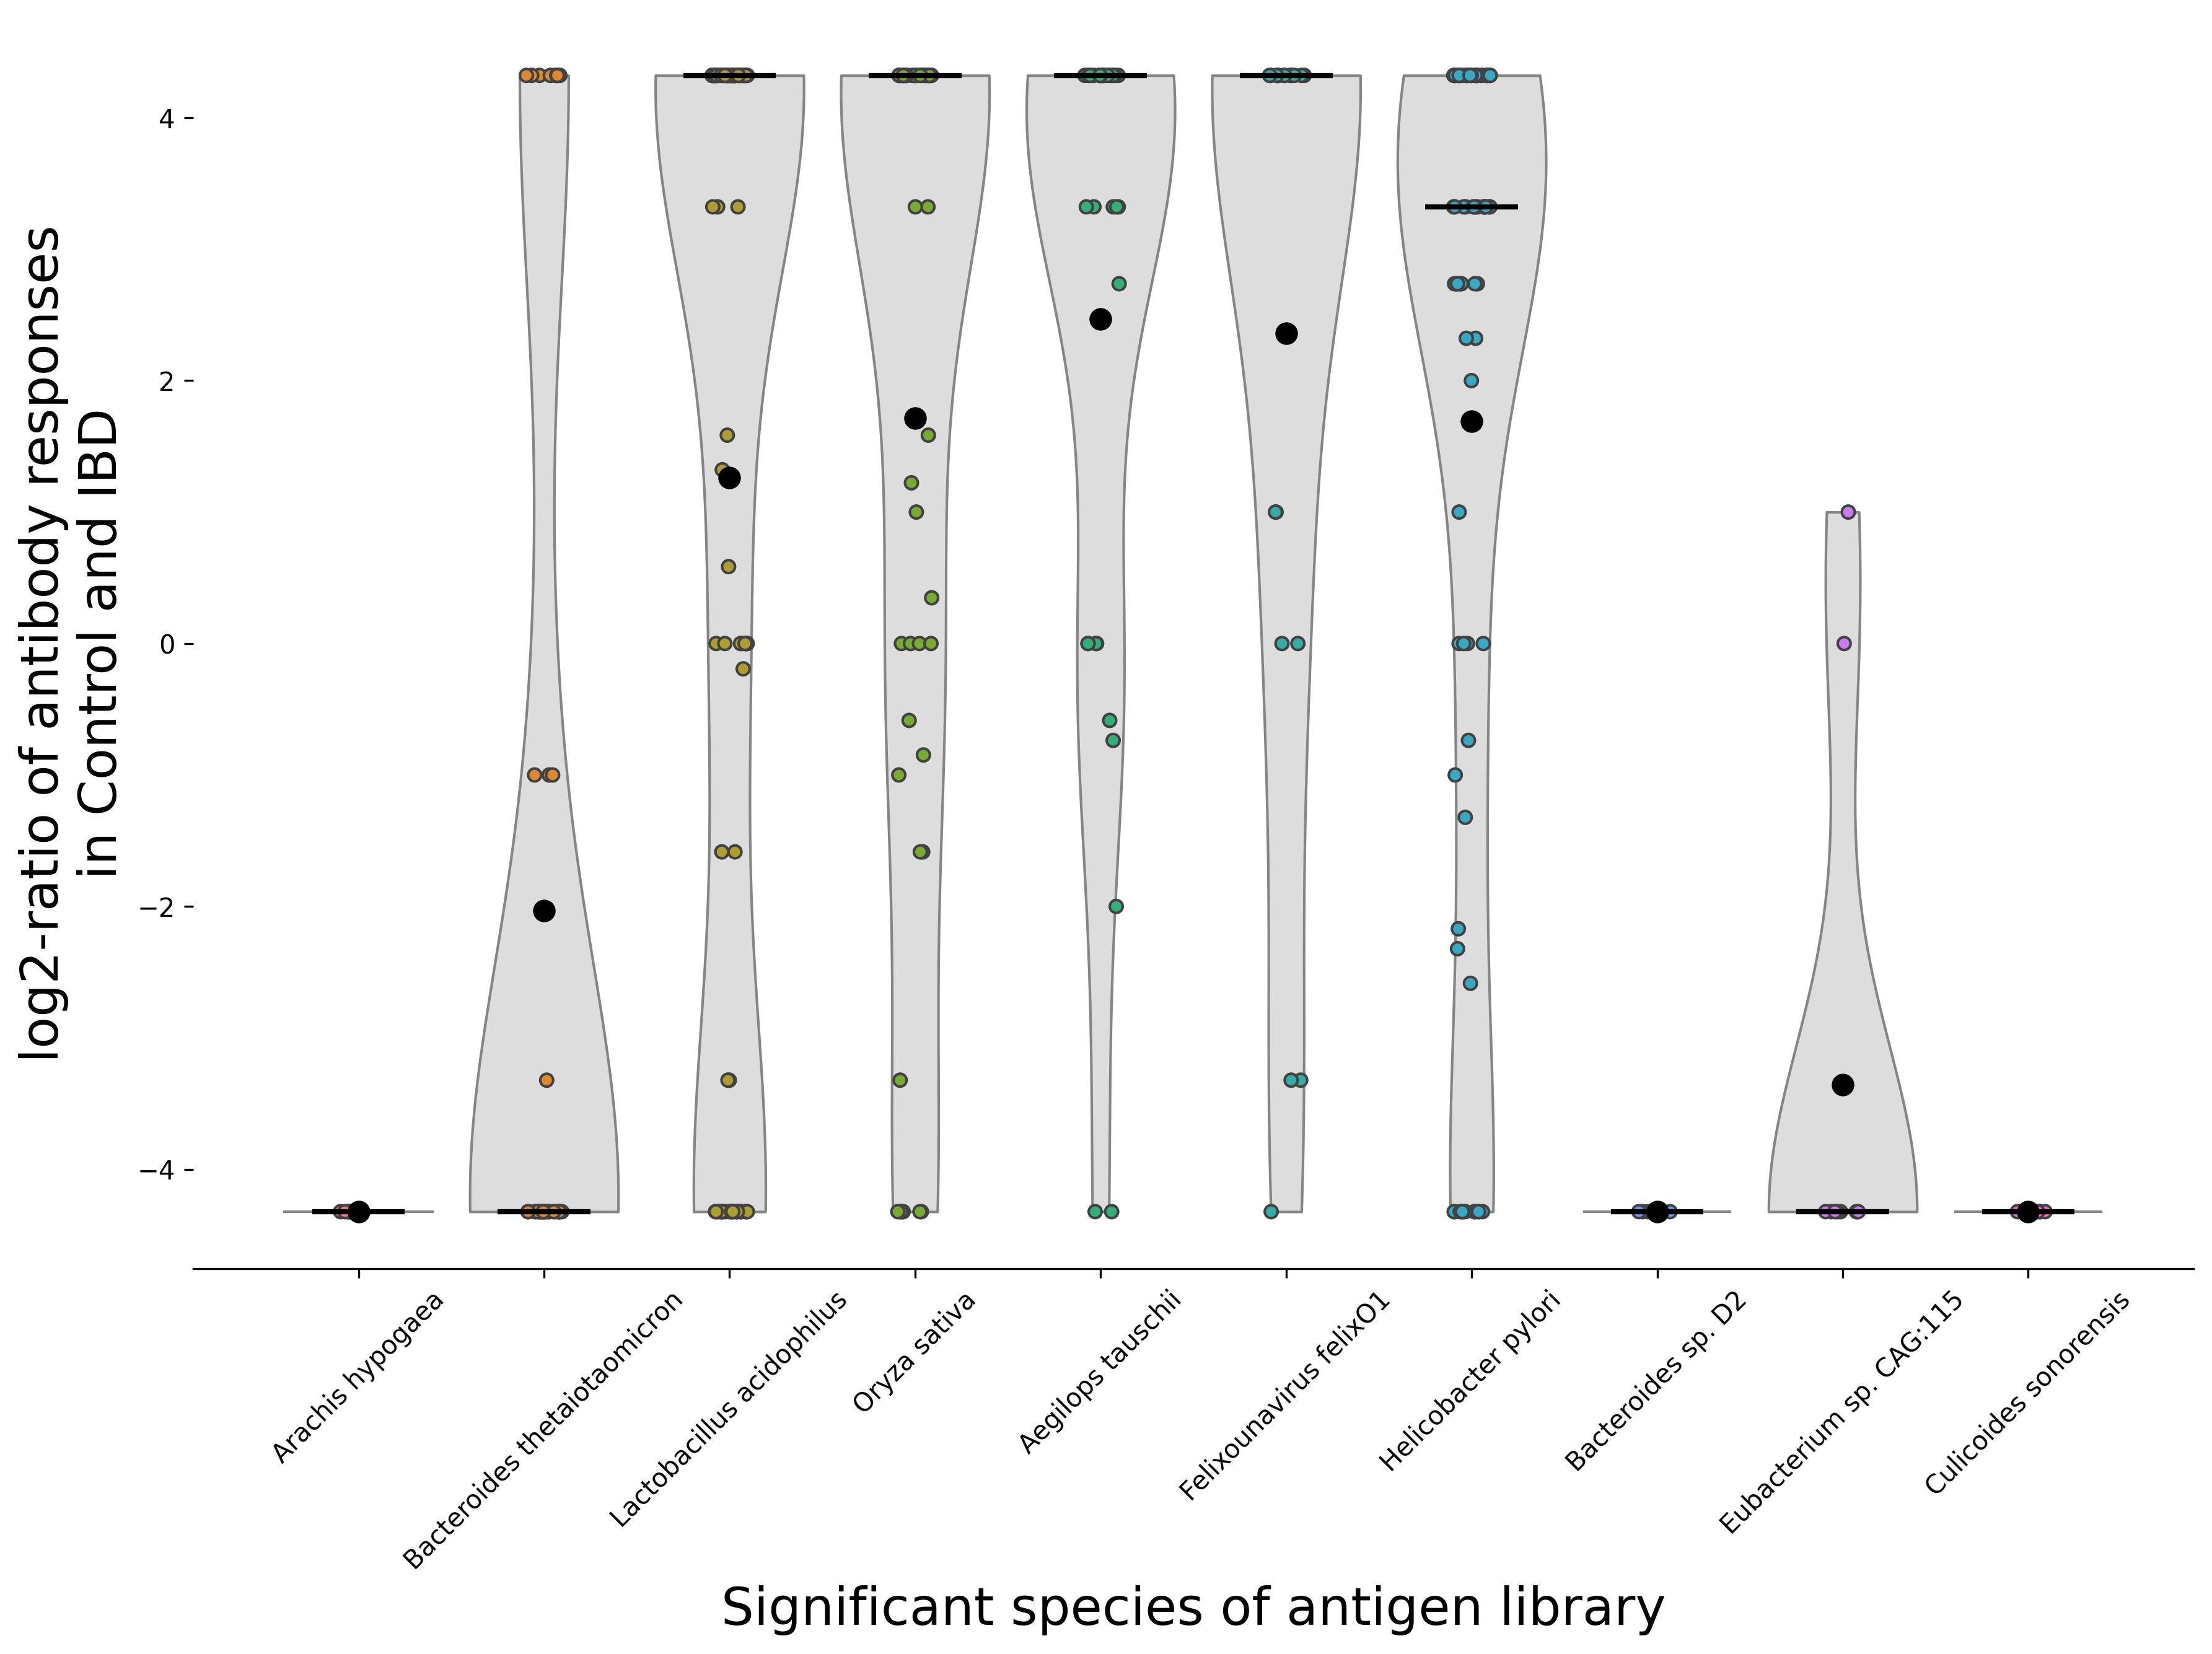

In [106]:
plot_violin(new_ratios_df_species_filtered, 'species', top_species_all)

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#1e90ff' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#b3182b' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#1e90ff' has d

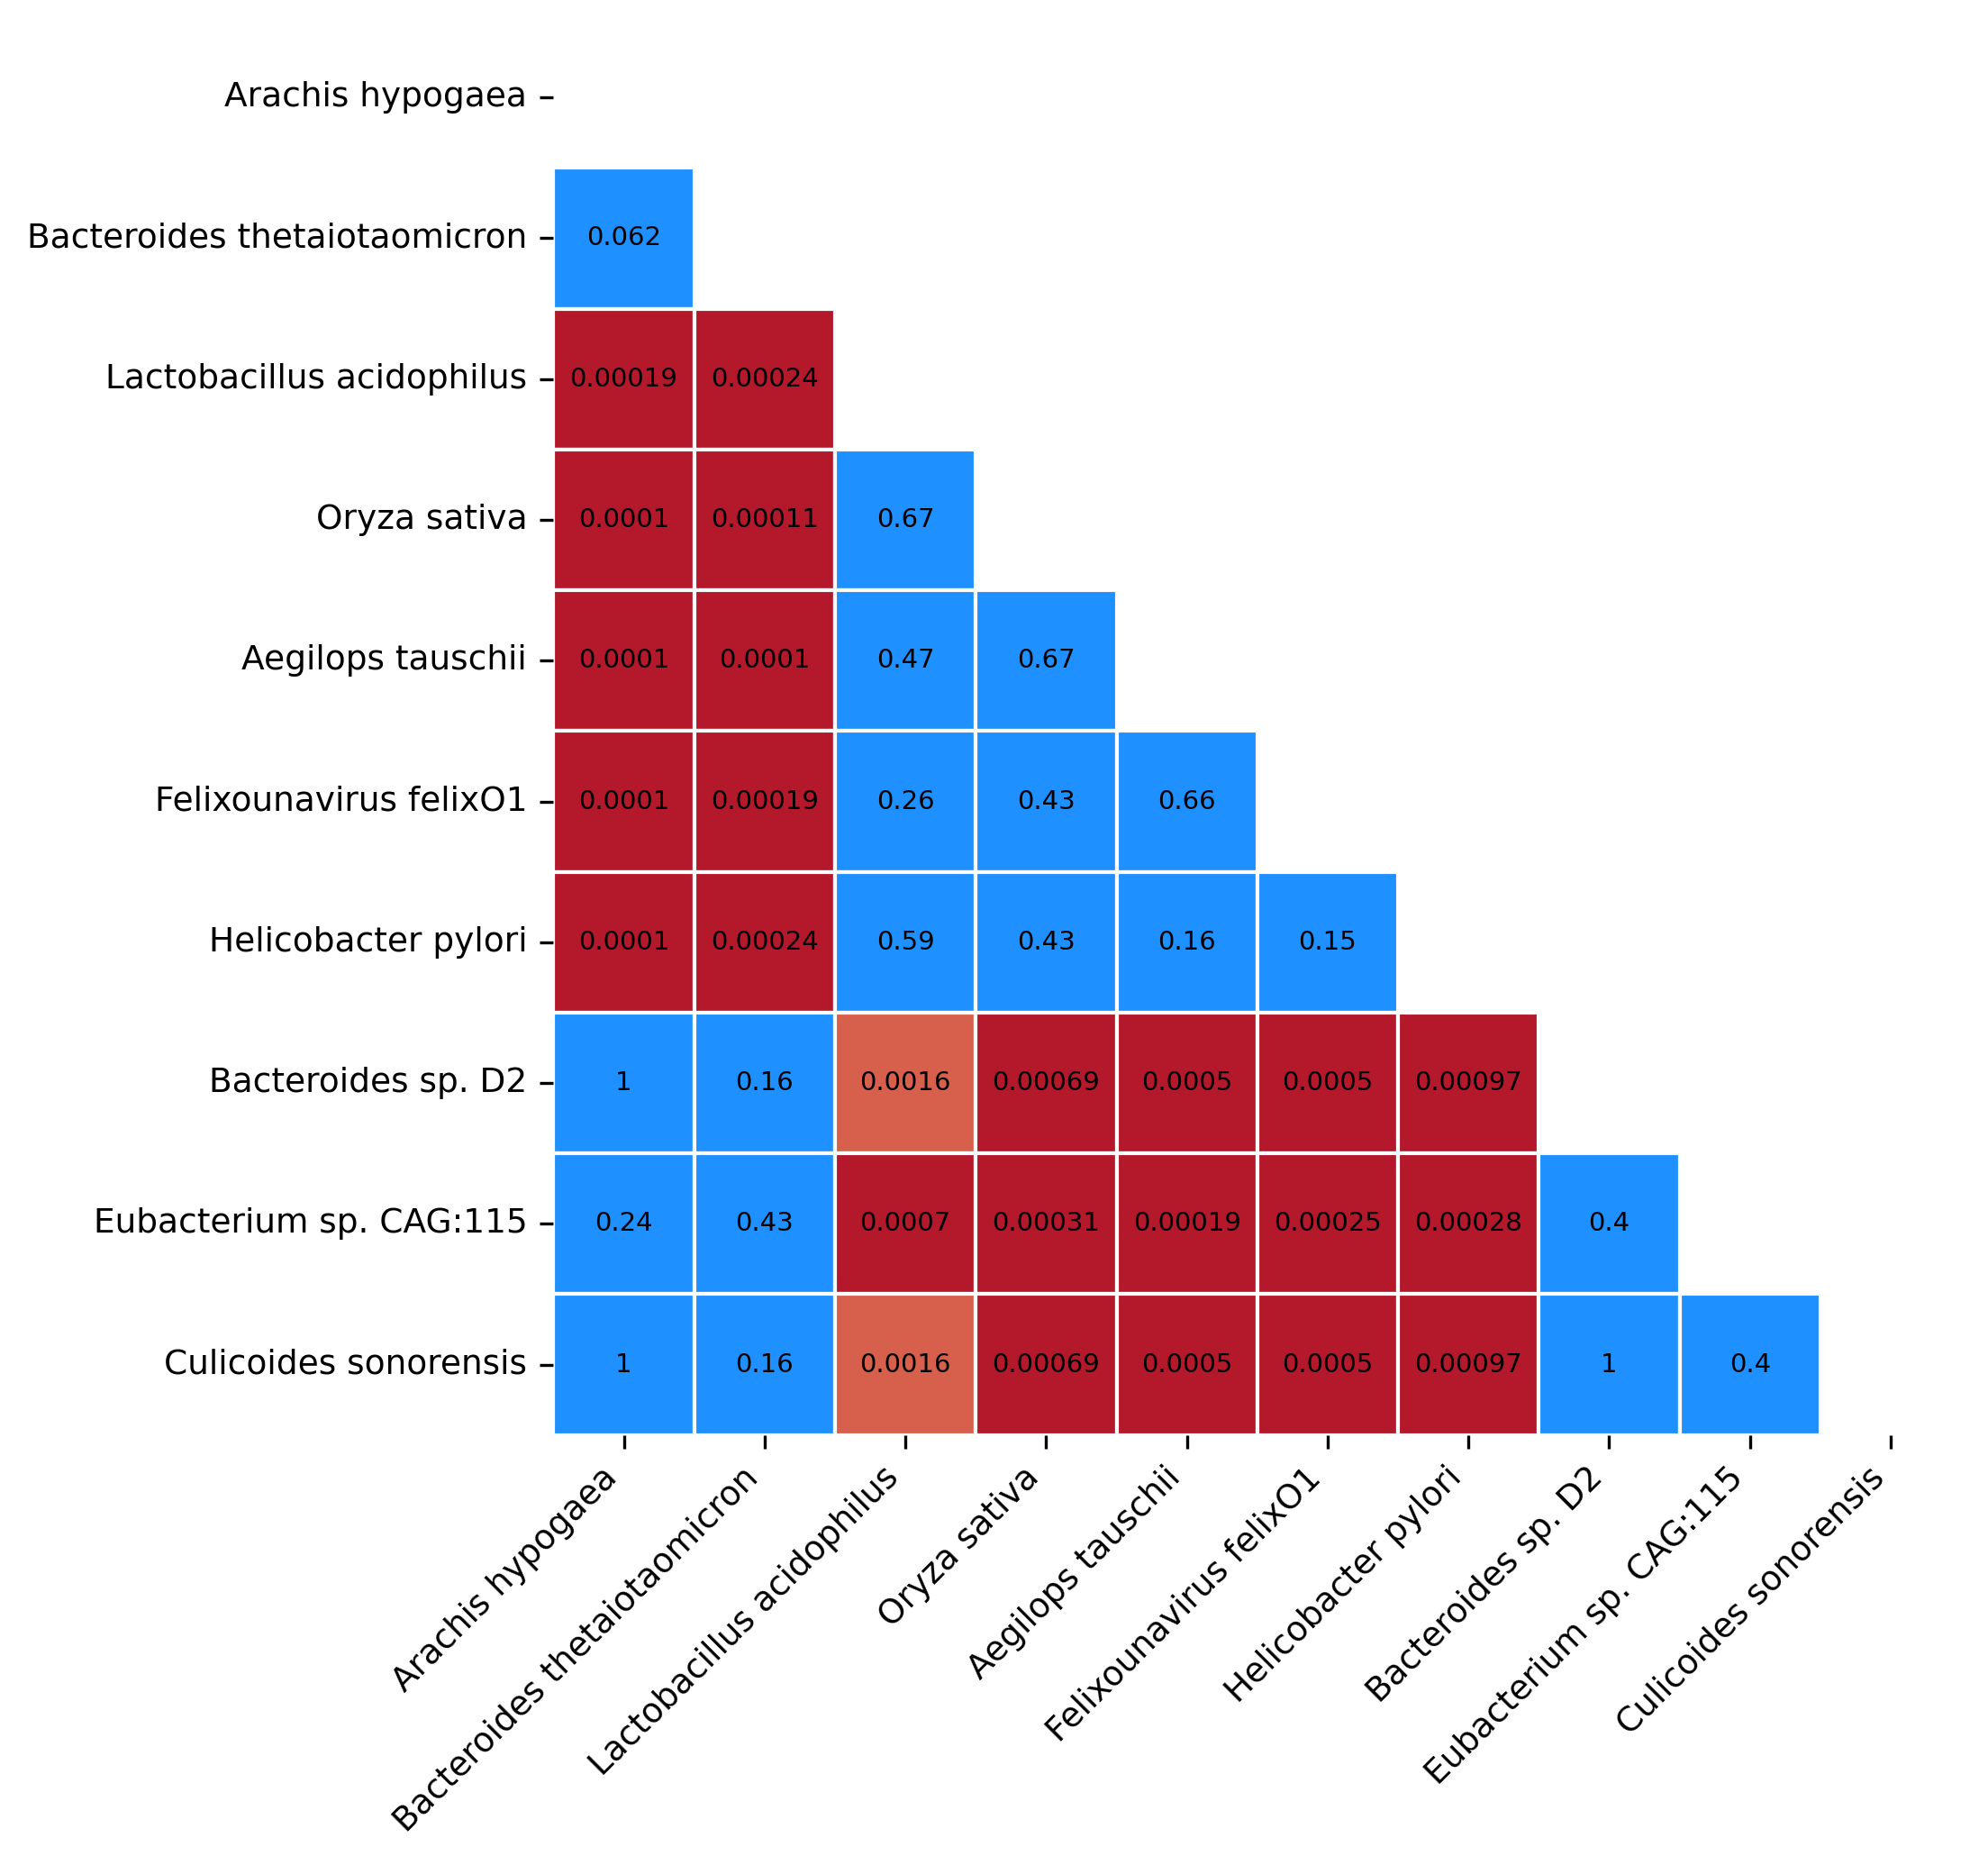

In [109]:
plot_correlation_matrix(new_ratios_df_species_filtered, top_species_all, 'species')

#### Genus

In [110]:
new_ratios_df_genus = violin_plot_preparation(new_ratios_df, 'genus', 'ratio')
new_ratios_df_genus.sort_values('p_adj_BH').head(10)

,genus,n_peptides,mean_ratio,median_ratio,p_value,p_adj_BH
3,Aegilops,33,12.796465,20.00,0.000200,0.025283
21,Arachis,10,0.050000,0.05,0.000184,0.025283
177,Oryza,49,11.335611,20.00,0.000946,0.079770
96,Felixounavirus,20,13.312500,20.00,0.001697,0.107355
115,Helicobacter,71,9.849374,10.00,0.002131,0.107811
15,Anaerobutyricum,105,6.801587,0.05,0.007800,0.239913
232,Sus,8,0.207955,0.05,0.008534,0.239913
218,Secale,7,17.250000,20.00,0.008408,0.239913
195,Poa,5,20.000000,20.00,0.007663,0.239913
137,Lactobacillus,133,9.876557,3.00,0.012759,0.322802


In [111]:
top_genus_all = new_ratios_df_genus.sort_values('p_adj_BH').head(10)['genus'].tolist()
new_ratios_df_genus_filtered = new_ratios_df[new_ratios_df['genus'].isin(top_genus_all)]

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/2454548485.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


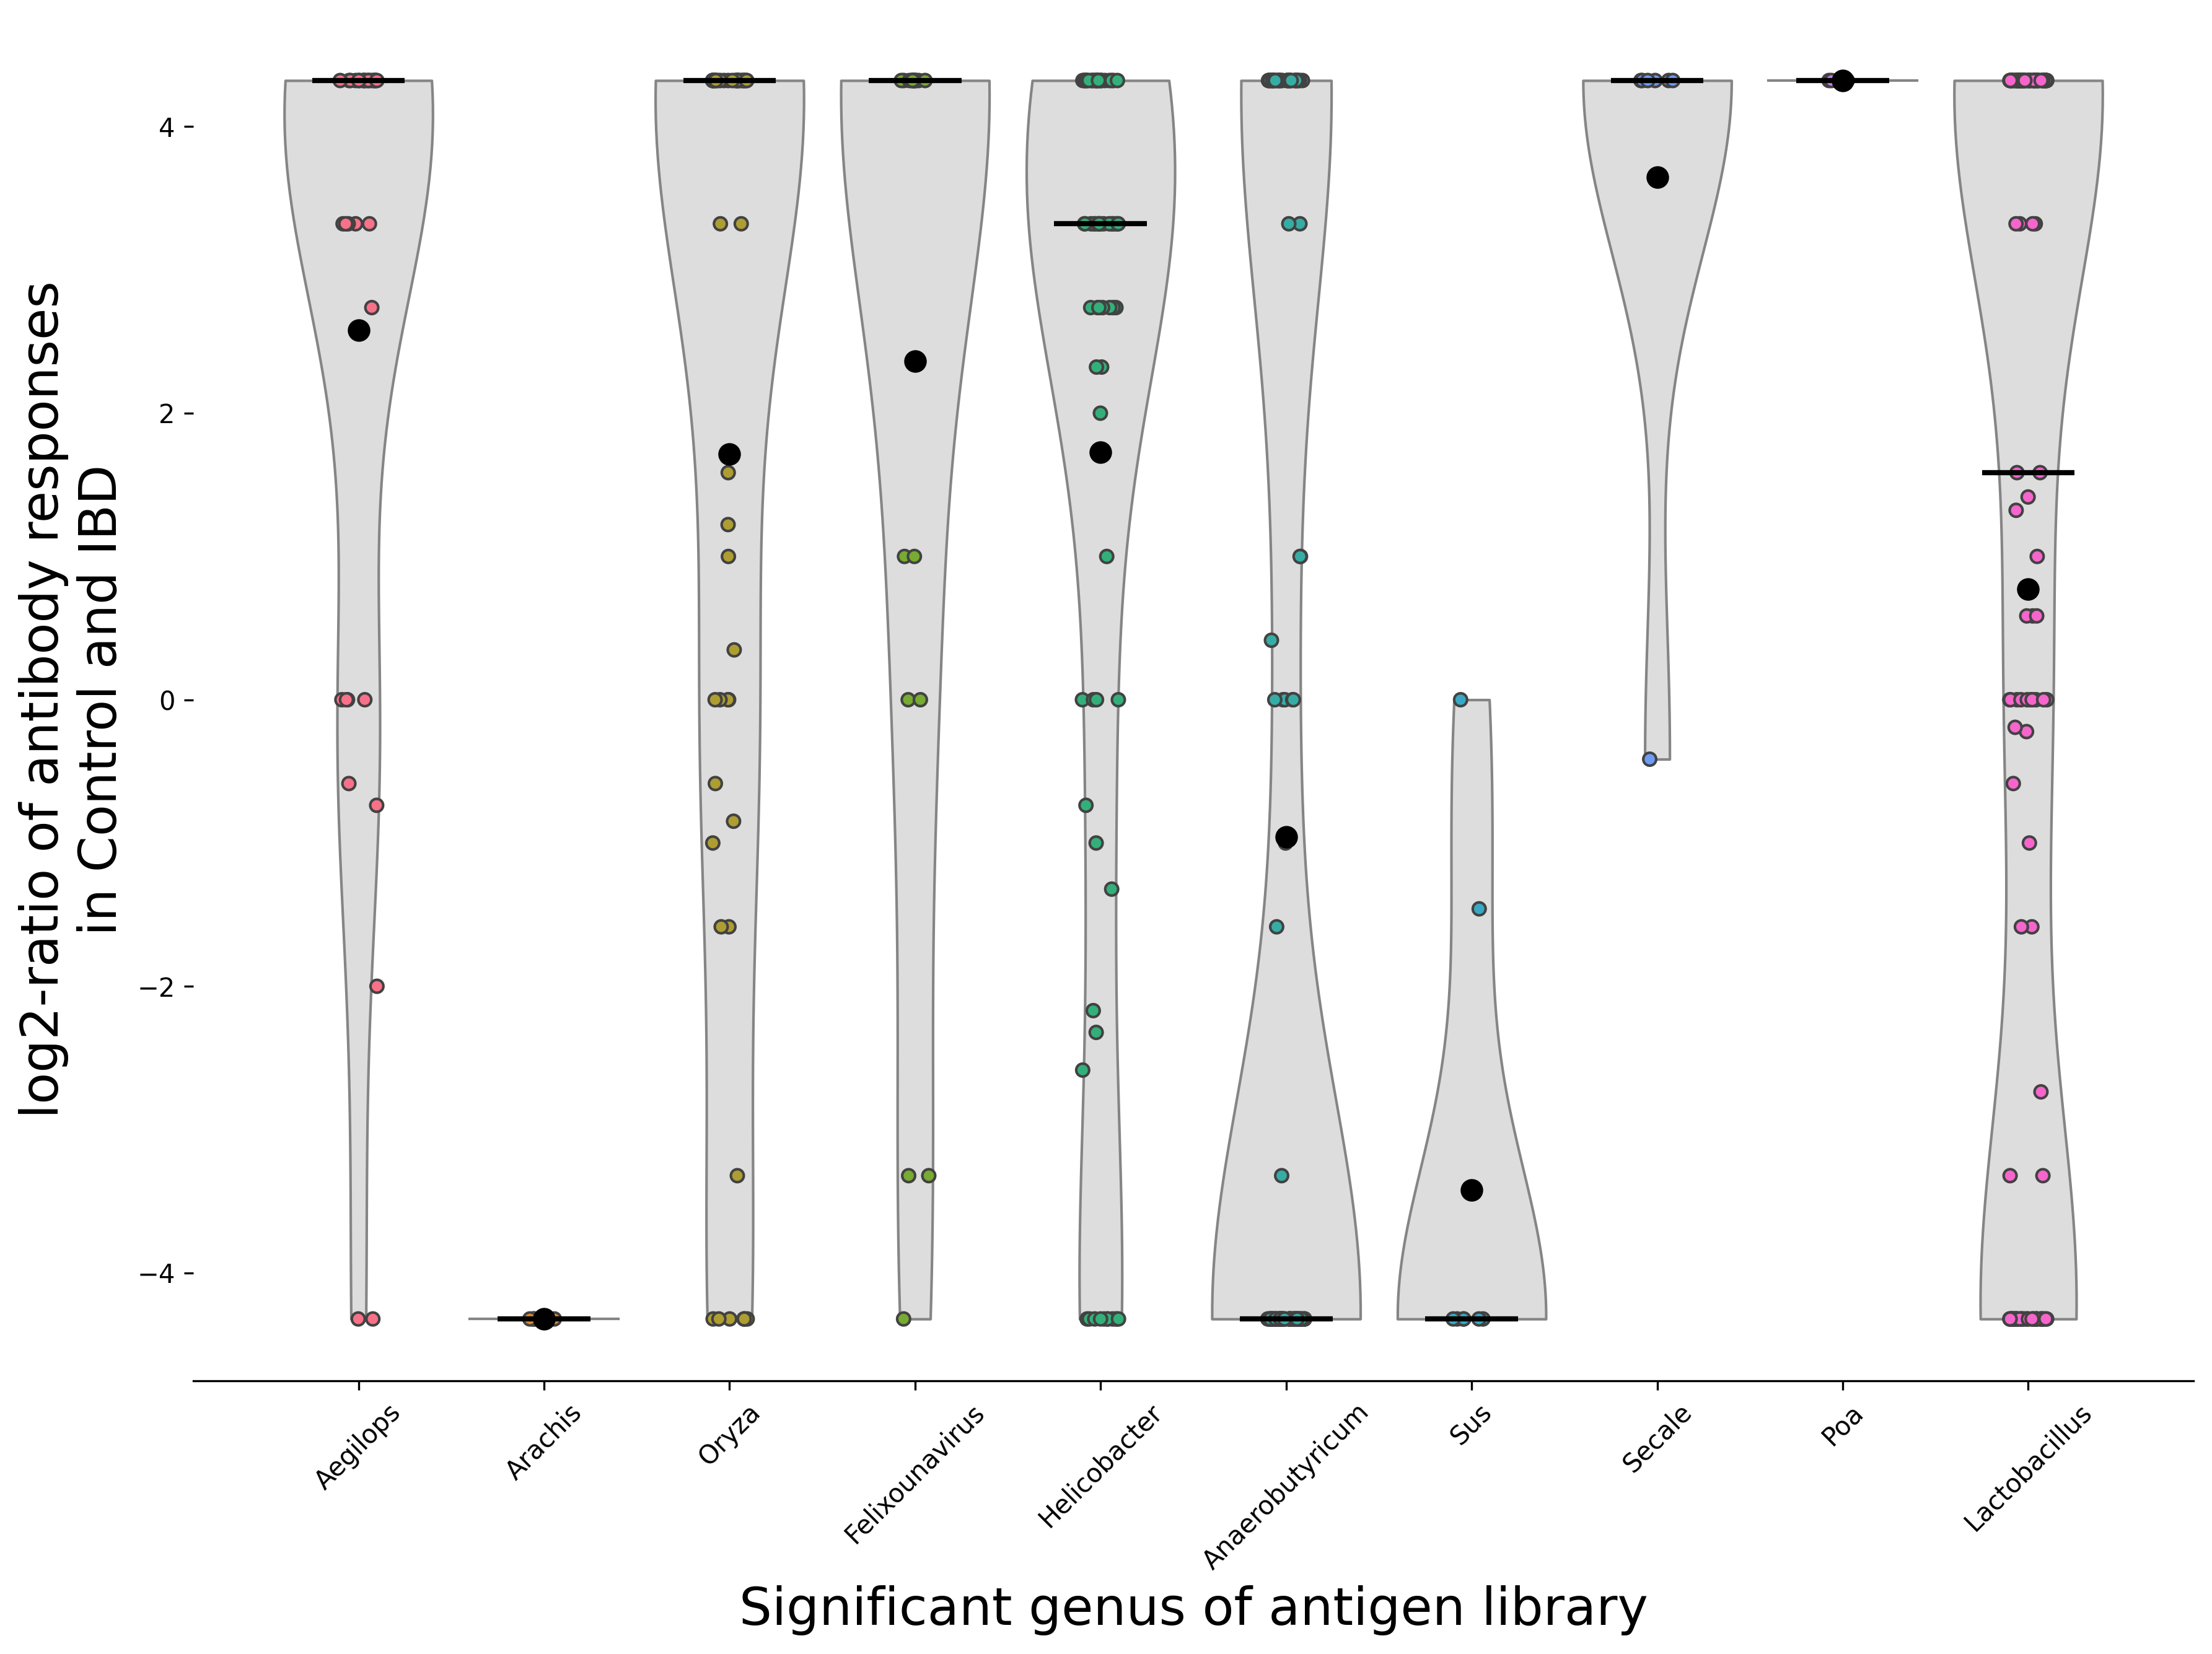

In [112]:
plot_violin(new_ratios_df_genus_filtered, 'genus', top_genus_all)

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#b3182b' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#b3182b' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#1e90ff' has d

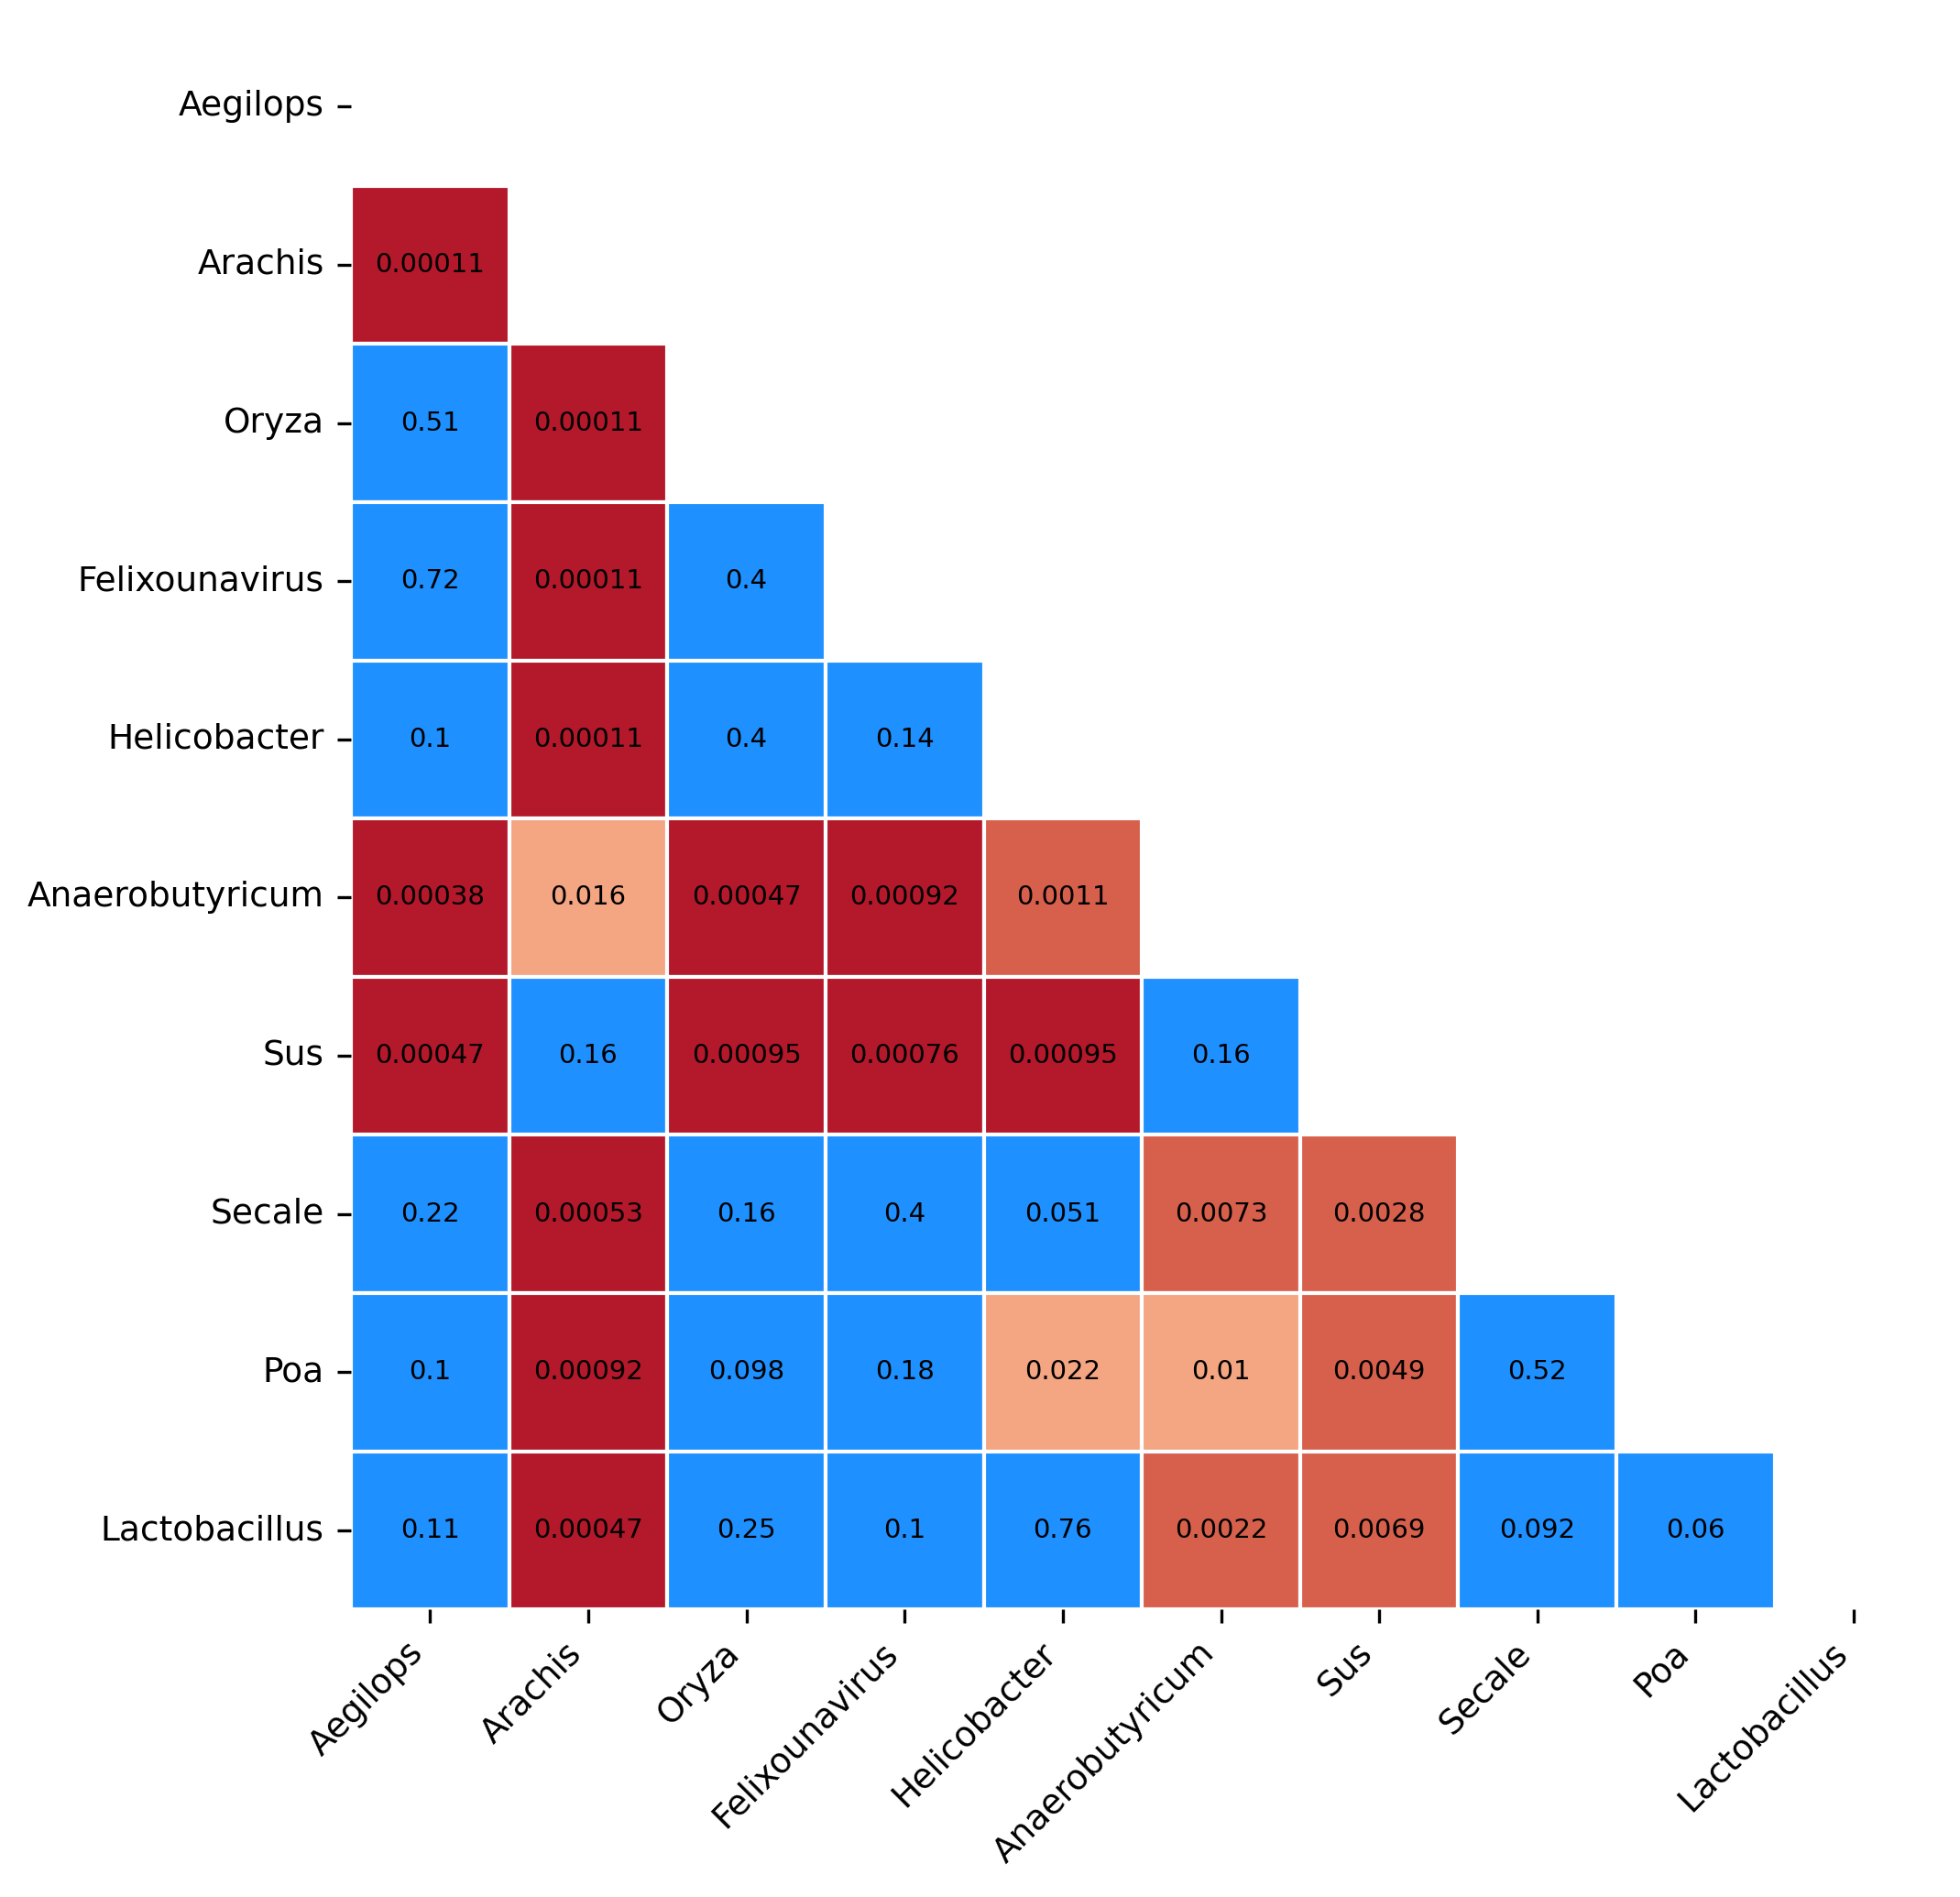

In [113]:
plot_correlation_matrix(new_ratios_df_genus_filtered, top_genus_all, 'genus')

### Aux funcs

In [2]:
def add_subgroup_info(dataset_to_add, peptide_col_name, peptide_info):

    mega_subgroup_list = []
    
    subgroups_cols = peptide_info.filter(regex='is_|signalp6_slow').columns

    for peptide in dataset_to_add[peptide_col_name]:
        subgroup_list = []

        for subgroup in subgroups_cols:
            if peptide_info.loc[peptide, subgroup]:
                subgroup_list.append(subgroup)
        
        mega_subgroup_list.append(subgroup_list)

    dataset_to_add['subgroups'] = mega_subgroup_list
    dataset_to_add = dataset_to_add.explode('subgroups')

    return dataset_to_add

In [107]:
def violin_plot_preparation(df, taxa, ratio_name):
    results = []

    for tx, group in df.groupby(taxa):
        ratios_group = group[ratio_name].dropna().values
        ratios_rest = df.loc[df[taxa] != tx, ratio_name].dropna().values
        
        # Deben haber al menos 3 péptidos por grupo
        if len(ratios_group) >= 3:
            stat, pval = mannwhitneyu(ratios_group, ratios_rest, alternative="two-sided")
            results.append({
                taxa: tx,
                'n_peptides': len(ratios_group),
                'mean_ratio': np.mean(ratios_group),
                'median_ratio': np.median(ratios_group),
                'p_value': pval
            })

    taxa_results = pd.DataFrame(results)

    # Corrección con Benjamini–Hochberg
    taxa_results['p_adj_BH'] = multipletests(taxa_results['p_value'], method='fdr_bh')[1]

    return taxa_results


In [4]:
def plot_violin(df, taxa, order):        
    fig, ax = plt.subplots(figsize=(12, 9), dpi=300)

    # Violin plot principal
    sns.violinplot(
        x=taxa,
        y='log2_ratio',
        data=df,
        cut=0,
        density_norm='width',
        inner=None,
        linewidth=1,
        color='#DDDDDD',
        saturation=1,
        order=order,
        ax=ax
    )

    # Puntos individuales
    sns.stripplot(
        x=taxa,
        y='log2_ratio',
        data=df,
        jitter=True,
        linewidth=1,
        order=order,
        palette=sns.color_palette("husl", n_colors=len(order)),
        ax=ax
    )

    # Calcular media y mediana por especie
    group_stats = df.groupby(taxa)['log2_ratio'].agg(['mean', 'median'])

    # Agregar puntos (media) y líneas (mediana)
    for i, tx in enumerate(order):
        if tx in group_stats.index:
            mean_val = group_stats.loc[tx, 'mean']
            median_val = group_stats.loc[tx, 'median']
            
            # Punto de la media
            ax.scatter(i, mean_val, color='black', s=60, zorder=5)
            # Línea de la mediana
            ax.hlines(median_val, i - 0.25, i + 0.25, color='black', lw=2, zorder=4)

    # Etiquetas y estilo
    ax.set_xlabel(f'Significant {taxa} of antigen library', fontsize=20)
    ax.set_ylabel('log2-ratio of antibody responses\nin Control and IBD', fontsize=20)
    ax.tick_params(axis='x', labelrotation=45)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

In [64]:
def p_to_significance(p):
    if p <= 1e-4:
        return "****"
    elif p <= 1e-3:
        return "***"
    elif p <= 1e-2:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

In [65]:
def plot_correlation_matrix(df, top_taxa, taxa):

    df = df.dropna(subset=['species', 'log2_ratio'])
    subgroups = top_taxa

    # Calcular matriz de p-valores
    pvals_matrix = pd.DataFrame(index=subgroups, columns=subgroups, dtype=float)

    for i, s1 in enumerate(subgroups):
        for j, s2 in enumerate(subgroups):
            if j >= i:
                continue  # solo triángulo inferior
            vals1 = df.loc[df[taxa] == s1, 'log2_ratio'].dropna()
            vals2 = df.loc[df[taxa] == s2, 'log2_ratio'].dropna()

            if len(vals1) >= 3 and len(vals2) >= 3:
                stat, pval = mannwhitneyu(vals1, vals2, alternative='two-sided')
                pvals_matrix.loc[s1, s2] = pval

    # Rellenar diagonal y triángulo superior con NaN
    for i in range(len(subgroups)):
        for j in range(i, len(subgroups)):
            pvals_matrix.iloc[i, j] = np.nan

    # Extraer p-valores válidos (no NaN)
    pvals_flat = pvals_matrix.stack().values

    # Aplicar BH
    reject, pvals_adj, _, _ = multipletests(pvals_flat, method='fdr_bh')

    # Reconstruir la matriz corregida
    pvals_adj_matrix = pvals_matrix.copy()
    pvals_adj_matrix.loc[:, :] = np.nan  # inicializar todo con NaN
    pvals_adj_matrix.values[np.tril_indices_from(pvals_adj_matrix, k=-1)] = pvals_adj

    # pvals_adj_matrix = tu matriz BH-ajustada
    pvals_flat = pvals_adj_matrix.stack().reset_index()
    pvals_flat.columns = ["row", "col", "p_value"]
    pvals_flat["significance"] = pvals_flat["p_value"].apply(p_to_significance)

    sig_colors = {
    "****": "#67001f",
    "***": "#b3182b",
    "**": "#d7604d",
    "*": "#f4a582",
    "ns": "#1e90ff"
    }

    # Crear nueva matriz de colores
    color_matrix = pd.DataFrame(np.nan, index=pvals_adj_matrix.index, columns=pvals_adj_matrix.columns)

    for _, row in pvals_flat.iterrows():
        color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]

    plt.figure(figsize=(9, 7), dpi=300)

    # Construir matriz de colores (colormap discreto)
    sns.heatmap(
        pvals_adj_matrix,
        mask=np.triu(np.ones_like(pvals_adj_matrix, dtype=bool)),
        annot=True, fmt=".2g",
        annot_kws={"size": 7, 'color': 'black'},
        cbar=False,
        linewidths=2, linecolor="white",
        square=True,
        cmap=None  # No usamos cmap continua
    )

    # Recolorear las celdas manualmente
    for i, row in enumerate(pvals_adj_matrix.index):
        for j, col in enumerate(pvals_adj_matrix.columns):
            if j >= i:
                continue
            color = color_matrix.loc[row, col]
            if pd.notna(color):
                plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='white', lw=1))

    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

### Réplica Data HTML

In [5]:
html_data = pd.read_excel('../Data/table_peptidesSignificance_group_test_Controls_vs_IBD.xlsx')

#### Species

In [6]:
html_data_species = violin_plot_preparation(html_data, 'species', 'ratio')
html_data_species.sort_values('p_adj_BH').head(10)

,species,n_peptides,mean_ratio,median_ratio,p_value,p_adj_BH
85,Helicobacter pylori,33,4.580808,4.000000,4.371795e-13,8.350128e-11
52,Cytomegalovirus humanbeta5,131,1.001409,0.722222,2.918073e-10,2.786760e-08
171,Streptococcus pneumoniae,105,2.531145,1.857143,5.943810e-08,3.784226e-06
63,Enterovirus B,42,2.153639,1.666667,5.979731e-04,2.855322e-02
0,Aegilops tauschii,9,3.685185,4.000000,7.915437e-04,3.023697e-02
153,Rhinovirus A,29,2.858223,1.800000,1.630714e-03,4.449519e-02
158,Ruminococcus torques,11,3.545455,4.000000,1.493691e-03,4.449519e-02
128,Oryctolagus cuniculus,4,0.250000,0.250000,3.875742e-03,9.253334e-02
86,Homo sapiens,155,1.425171,1.000000,5.691627e-03,1.207890e-01
109,Limosilactobacillus reuteri,7,0.535714,0.250000,6.366243e-03,1.215952e-01


In [ ]:
top_species_html = html_data_species.sort_values('p_adj_BH').head(10)['species'].tolist()

html_data_filtered_species = html_data[html_data['species'].isin(top_species_html)]
html_data_filtered_species.loc[:, 'log2_ratio'] = np.log2(html_data_filtered_species['ratio'])

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/1815756503.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  html_data_filtered_species.loc[:, 'log2_ratio'] = np.log2(html_data_filtered_species['ratio'])


/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_3771/2454548485.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


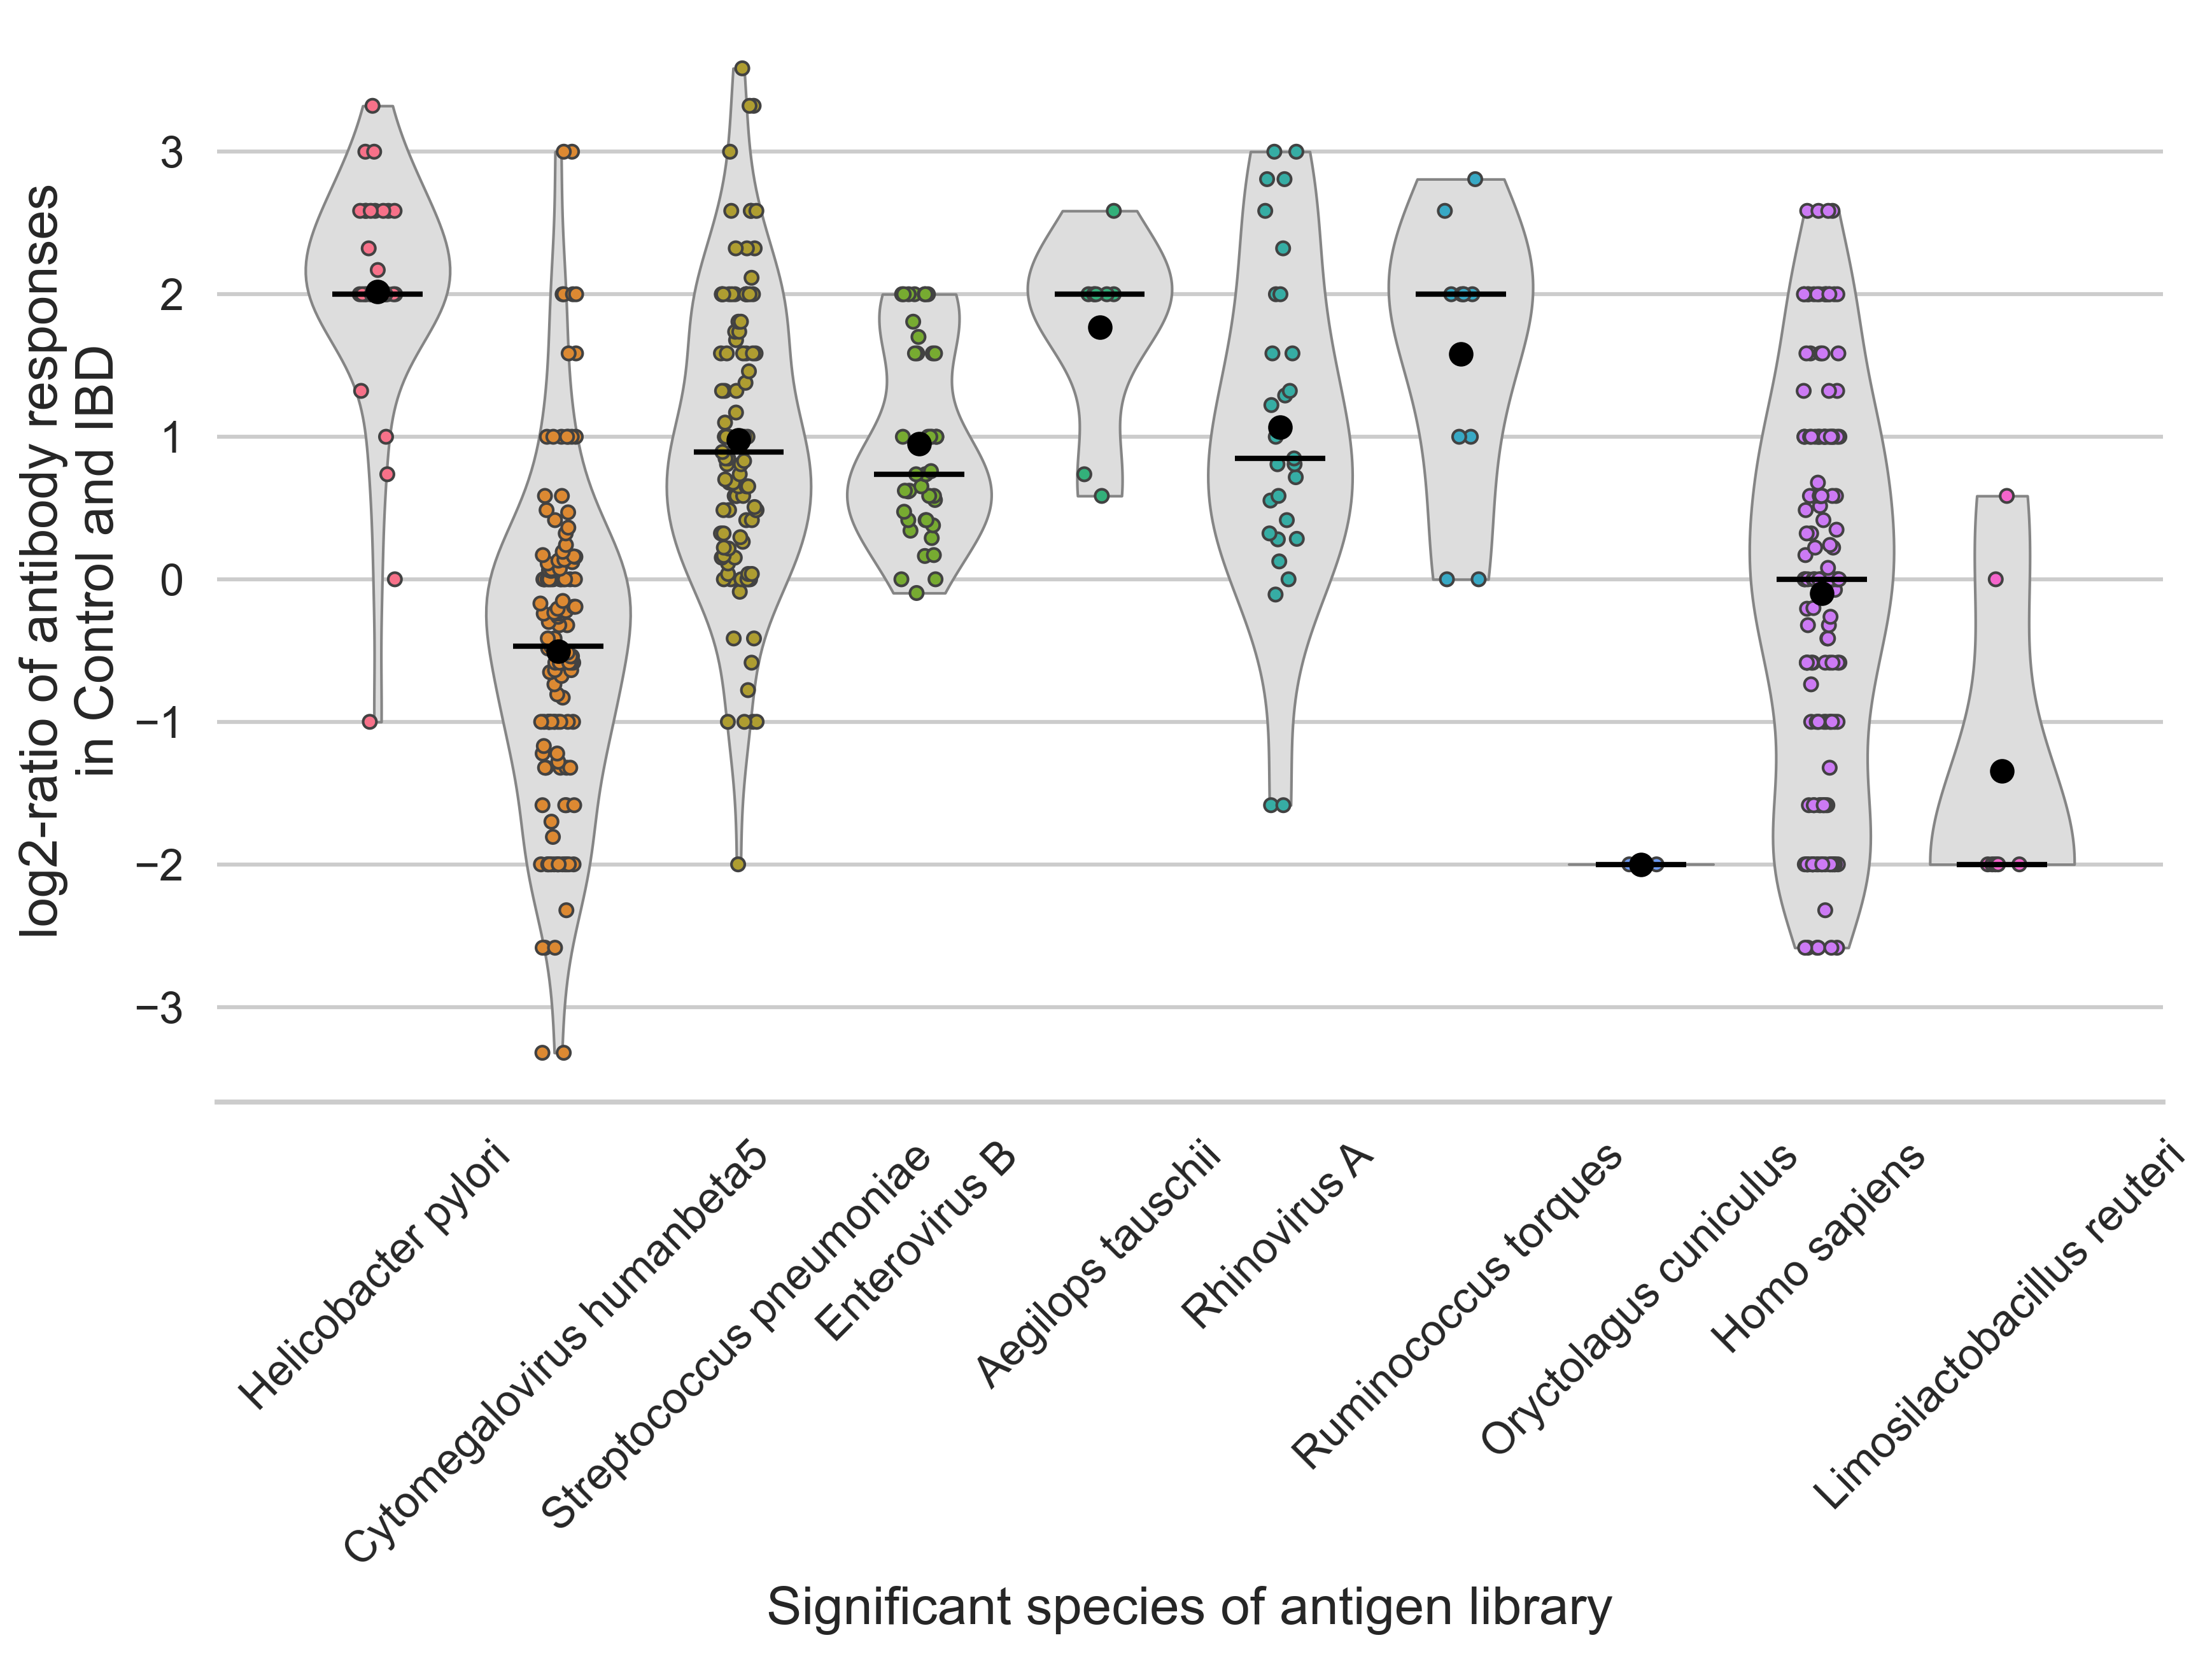

In [489]:
plot_violin(html_data_filtered_species, 'species', top_species_html)

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#67001f' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#67001f' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#1e90ff' has d

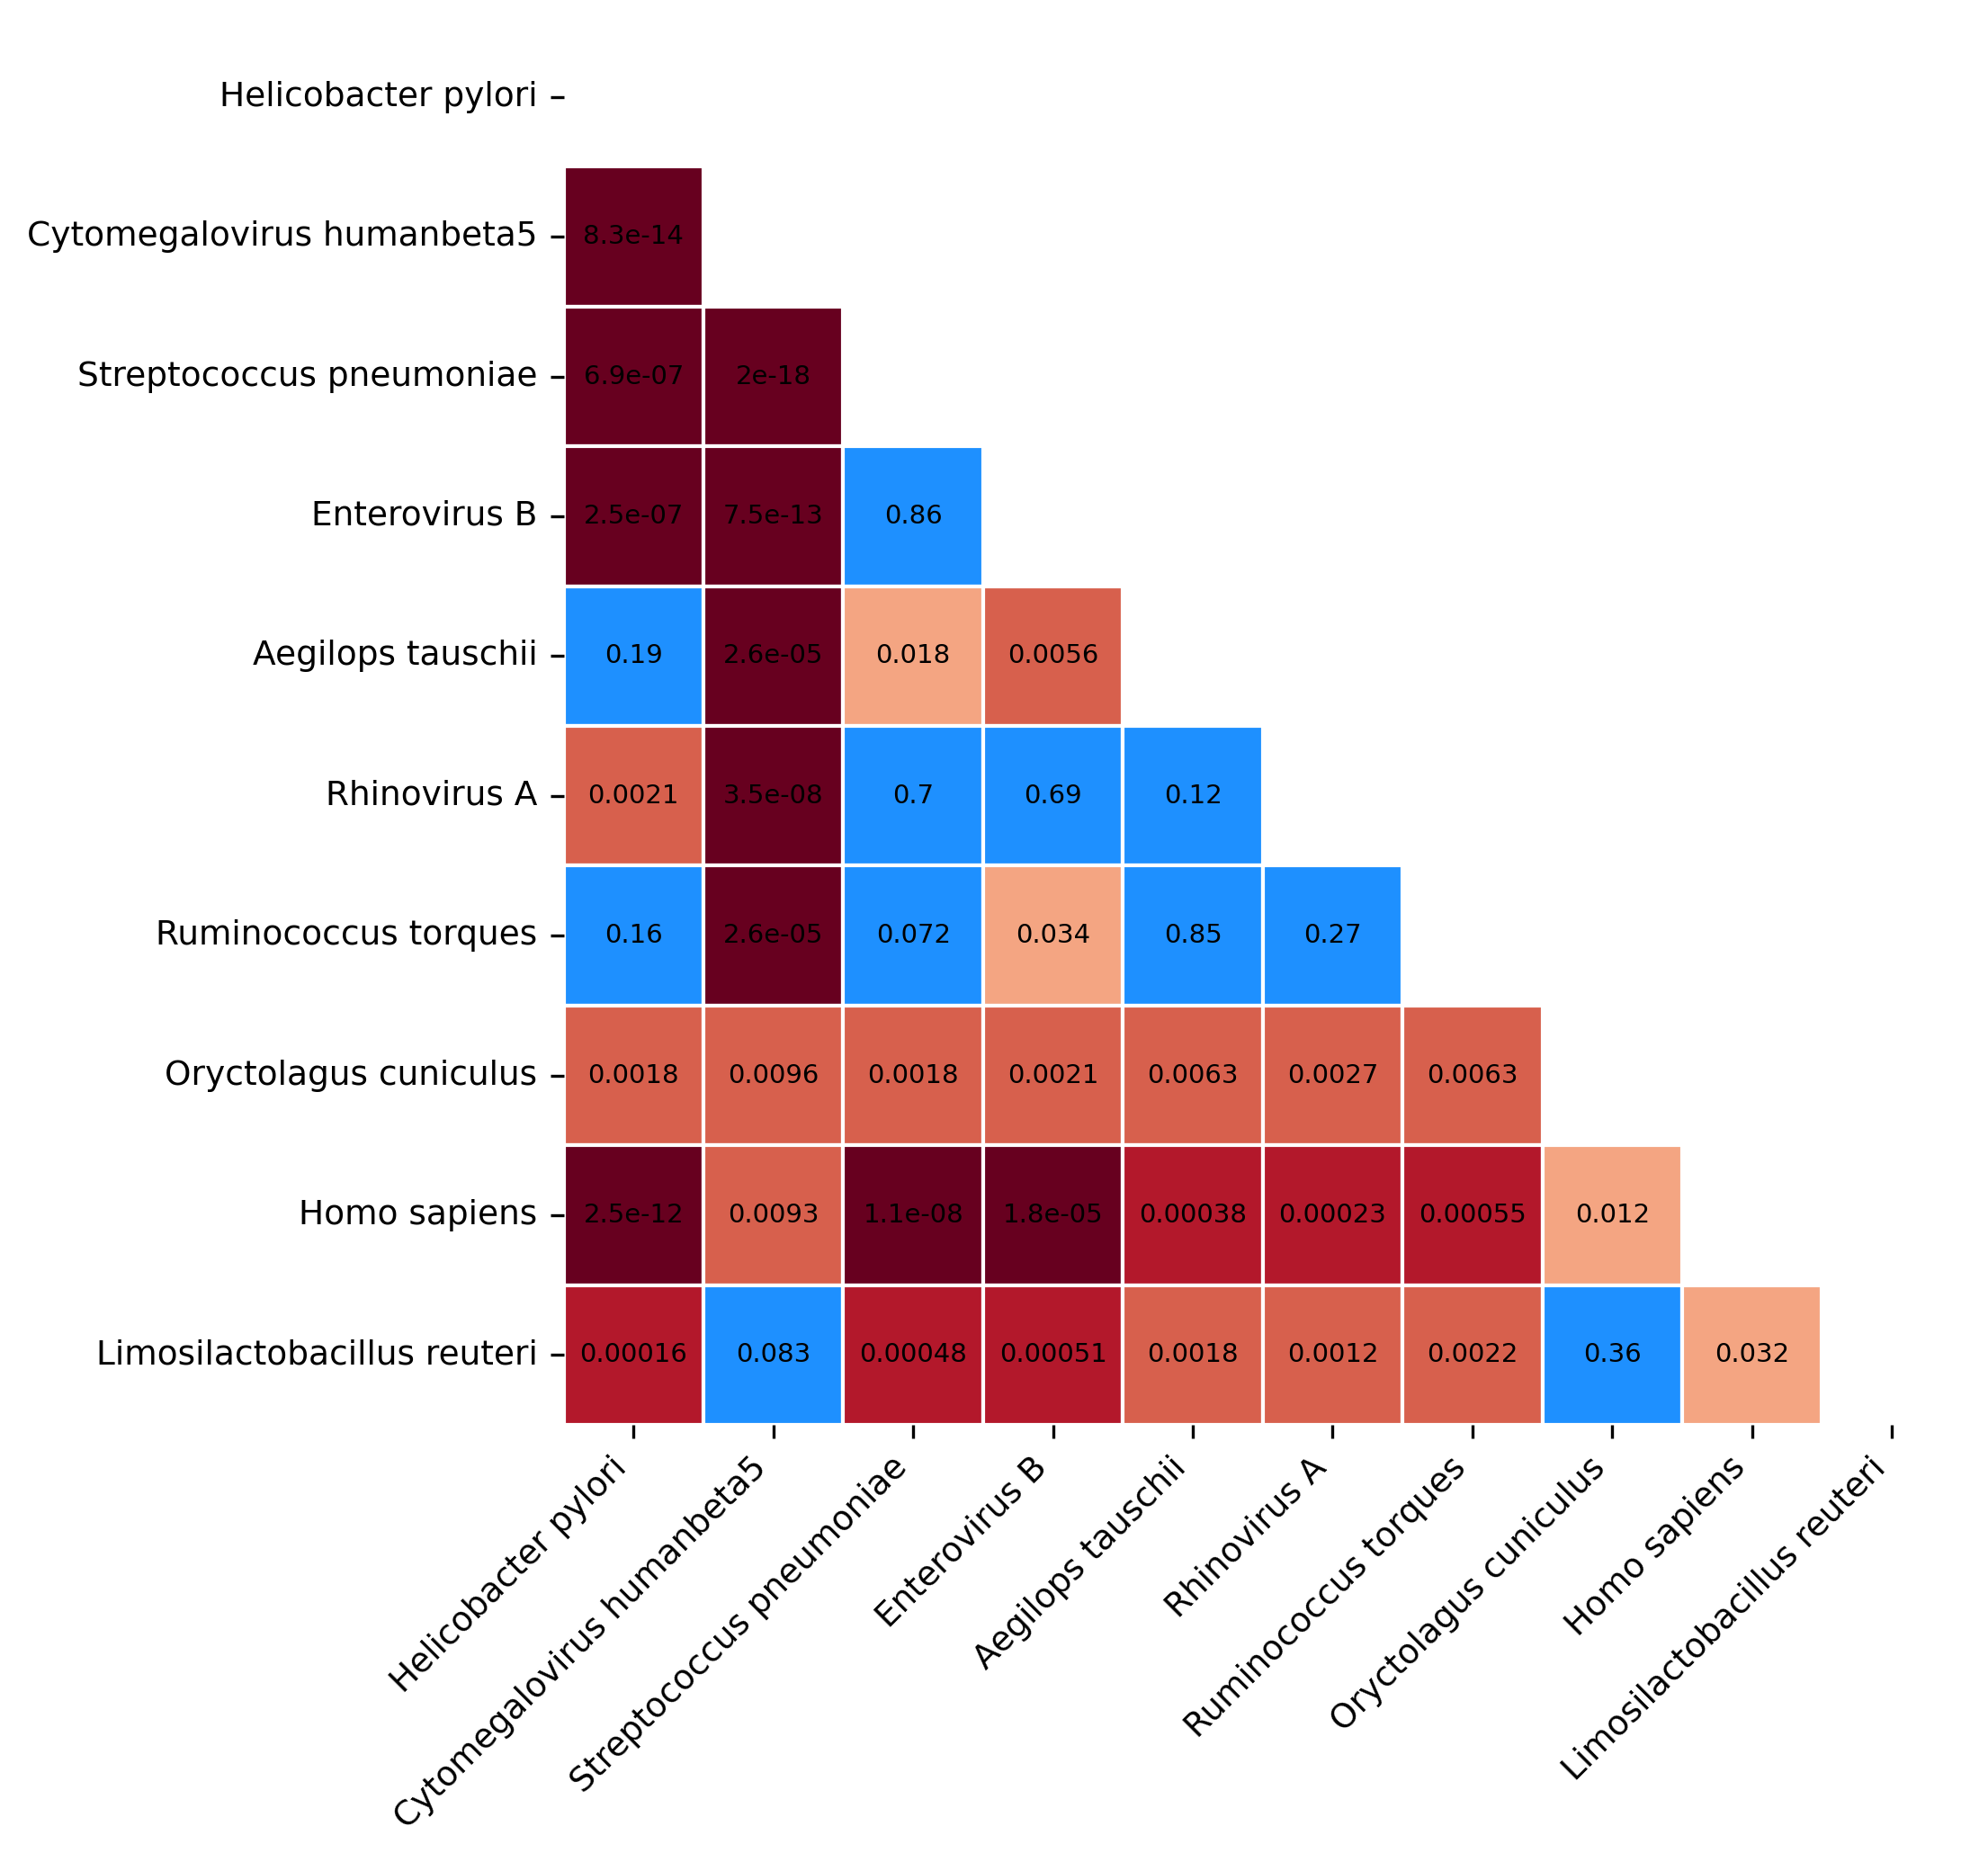

In [63]:
plot_correlation_matrix(html_data_filtered_species, top_species_html, 'species')

#### Genus

In [68]:
html_data_genus = violin_plot_preparation(html_data, 'genus', 'ratio')
html_data_genus.sort_values('p_adj_BH').head(10)

,genus,n_peptides,mean_ratio,median_ratio,p_value,p_adj_BH
59,Helicobacter,33,4.580808,4.000000,4.371795e-13,5.814487e-11
32,Cytomegalovirus,131,1.001409,0.722222,2.918073e-10,1.940519e-08
43,Enterovirus,152,2.092094,1.535897,2.512394e-06,1.113828e-04
120,Streptococcus,152,2.247254,1.585714,6.723601e-06,2.235597e-04
1,Aegilops,9,3.685185,4.000000,7.915437e-04,2.105506e-02
82,Mediterraneibacter,17,3.057315,3.000000,1.198293e-03,2.656217e-02
76,Limosilactobacillus,9,0.555556,0.250000,2.891800e-03,5.494420e-02
92,Oryctolagus,4,0.250000,0.250000,3.875742e-03,6.443421e-02
60,Homo,155,1.425171,1.000000,5.691627e-03,8.410960e-02
26,Campylobacter,11,3.477273,4.000000,8.368758e-03,1.113045e-01


In [69]:
top_genus_html = html_data_genus.sort_values('p_adj_BH').head(10)['genus'].tolist()

html_data_filtered_genus = html_data[html_data['genus'].isin(top_genus_html)]
html_data_filtered_genus.loc[:, 'log2_ratio'] = np.log2(html_data_filtered_genus['ratio'])

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3709850675.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  html_data_filtered_genus.loc[:, 'log2_ratio'] = np.log2(html_data_filtered_genus['ratio'])


/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/2454548485.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


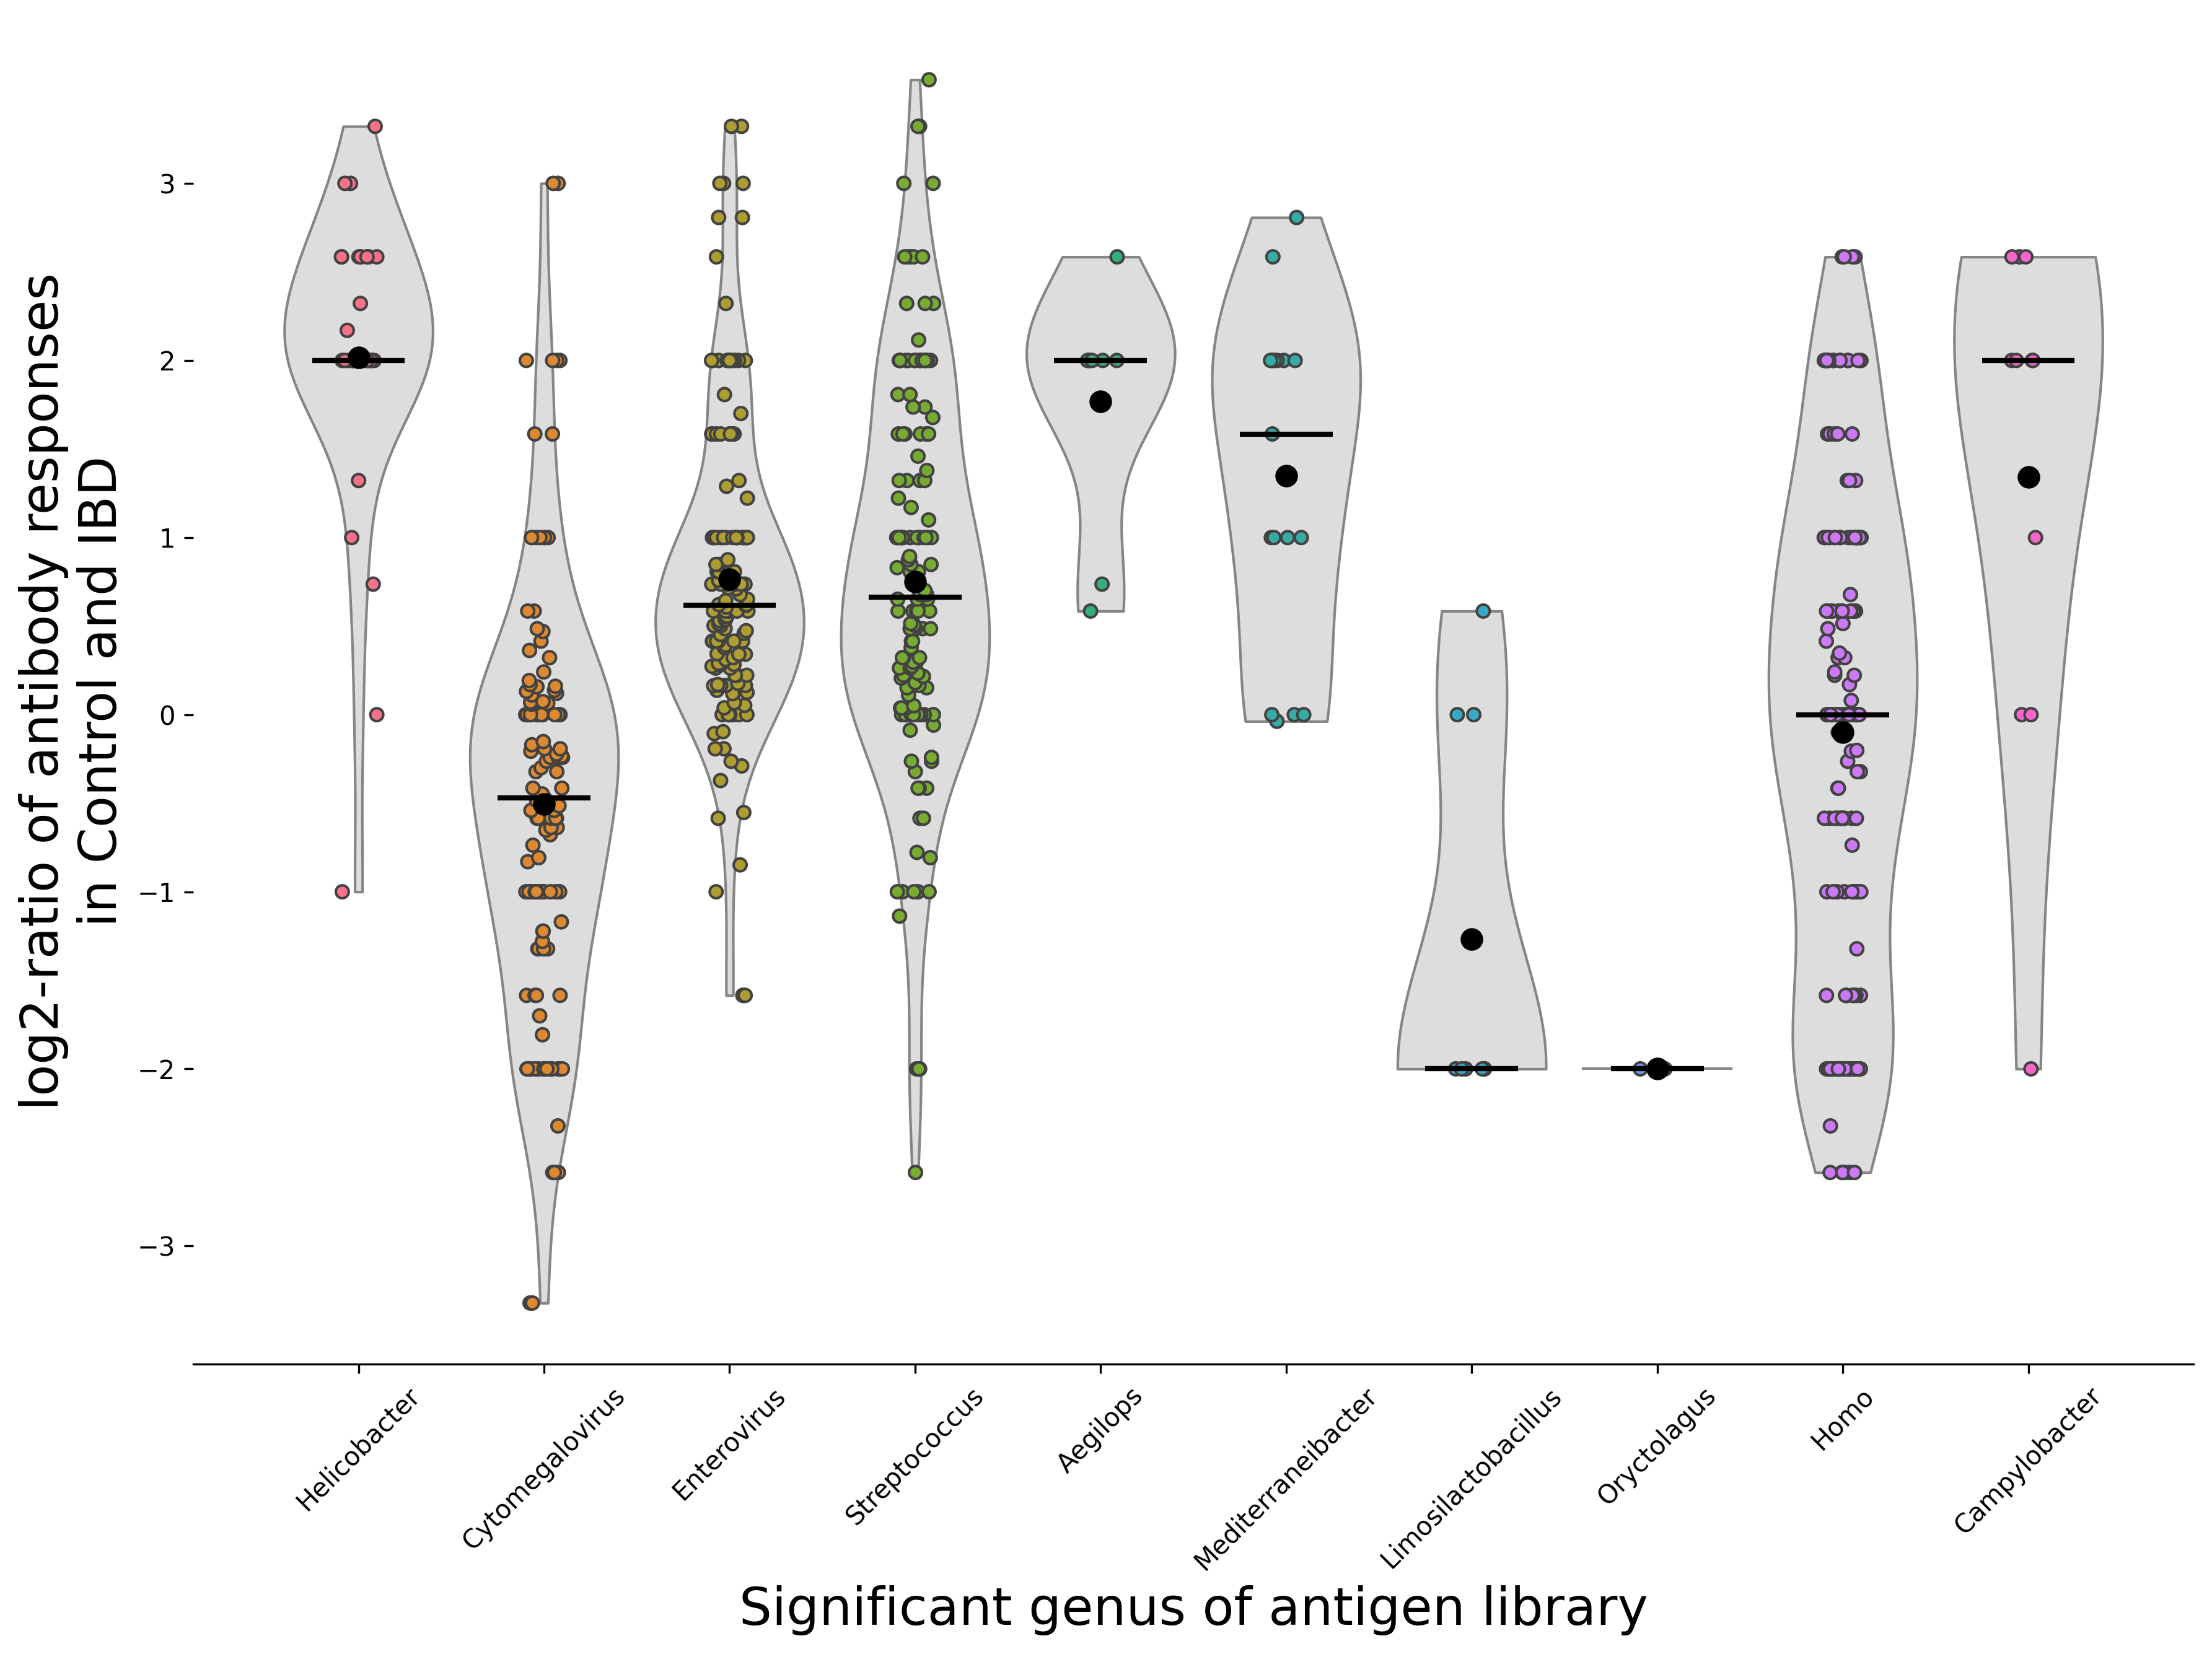

In [70]:
plot_violin(html_data_filtered_genus, 'genus', top_genus_html)

/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#67001f' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#67001f' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  color_matrix.loc[row["row"], row["col"]] = sig_colors[row["significance"]]
/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_17612/3683356106.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '#1e90ff' has d

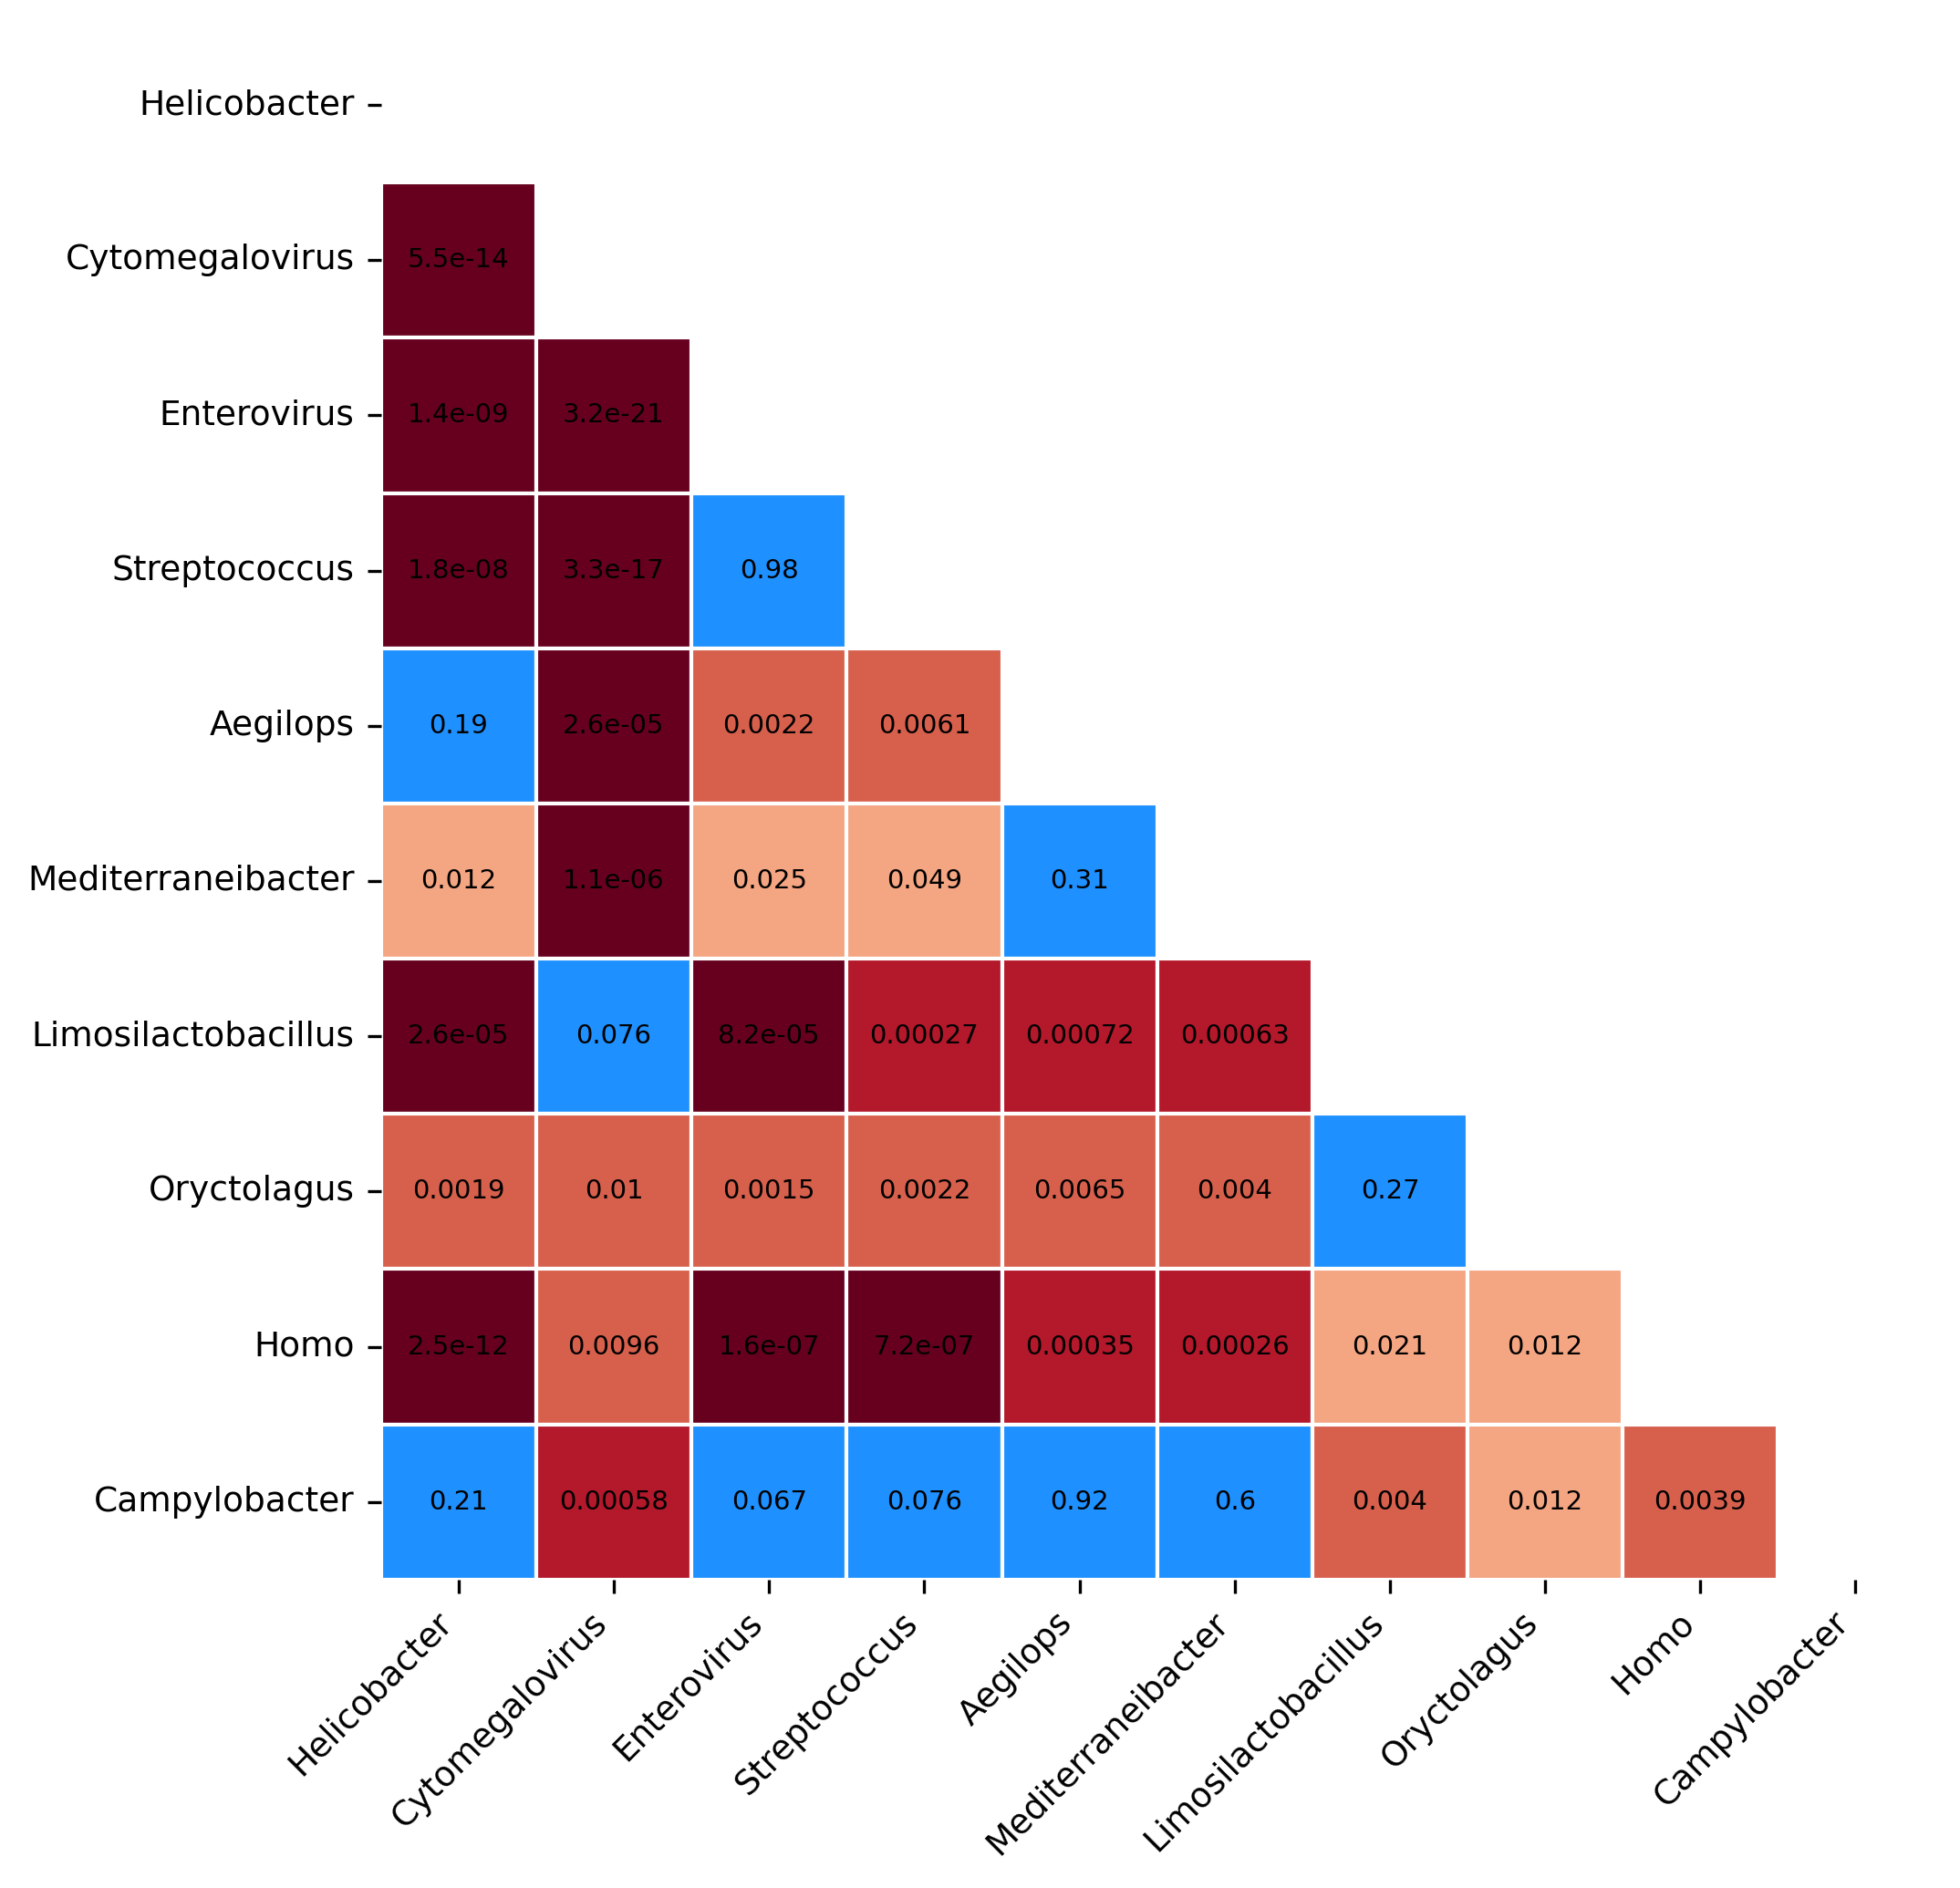

In [71]:
plot_correlation_matrix(html_data_filtered_genus, top_genus_html, 'genus')

### For Later

In [ ]:
mega_subgroup_list = []
subgroups_cols = peptide_info.filter(regex='is_|signalp6_slow').columns

for peptide in html_data['Peptide']:
    subgroup_list = []

    for subgroup in subgroups_cols:
        if peptide_info.loc[peptide, subgroup]:
            subgroup_list.append(subgroup)
    
    mega_subgroup_list.append(subgroup_list)

html_data['subgroups'] = mega_subgroup_list
html_data = html_data.explode('subgroups')

In [ ]:
results = []

for sp, group in html_data.groupby("subgroups"):
    ratios_group = group["ratio"].dropna().values
    ratios_rest = html_data.loc[html_data["subgroups"] != sp, "ratio"].dropna().values

    # solo si hay al menos 3 péptidos por grupo
    if len(ratios_group) >= 3:
        stat, pval = mannwhitneyu(ratios_group, ratios_rest, alternative="two-sided")
        results.append({
            "subgroups": sp,
            "n_peptides": len(ratios_group),
            "mean_ratio": np.mean(ratios_group),
            "median_ratio": np.median(ratios_group),
            "p_value": pval
        })

taxa_results = pd.DataFrame(results)
taxa_results["p_adj_BH"] = multipletests(taxa_results["p_value"], method="fdr_bh")[1]
sig_taxa = taxa_results.query("p_adj_BH < 0.05").sort_values("mean_ratio", ascending=False)

In [ ]:
html_data = html_data.reset_index(drop=True)
top_groups= taxa_results.sort_values("p_value").head(10)["subgroups"].tolist()
html_data_filtered = html_data[html_data["subgroups"].isin(top_groups)]
html_data_filtered.loc[:, 'log2_ratio'] = np.log2(html_data_filtered['ratio'])


/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_3771/251690346.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  html_data_filtered.loc[:, 'log2_ratio'] = np.log2(html_data_filtered['ratio'])


/var/folders/94/lz4l21dx7ngfvgk7_t9r53r80000gn/T/ipykernel_3771/4140996342.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


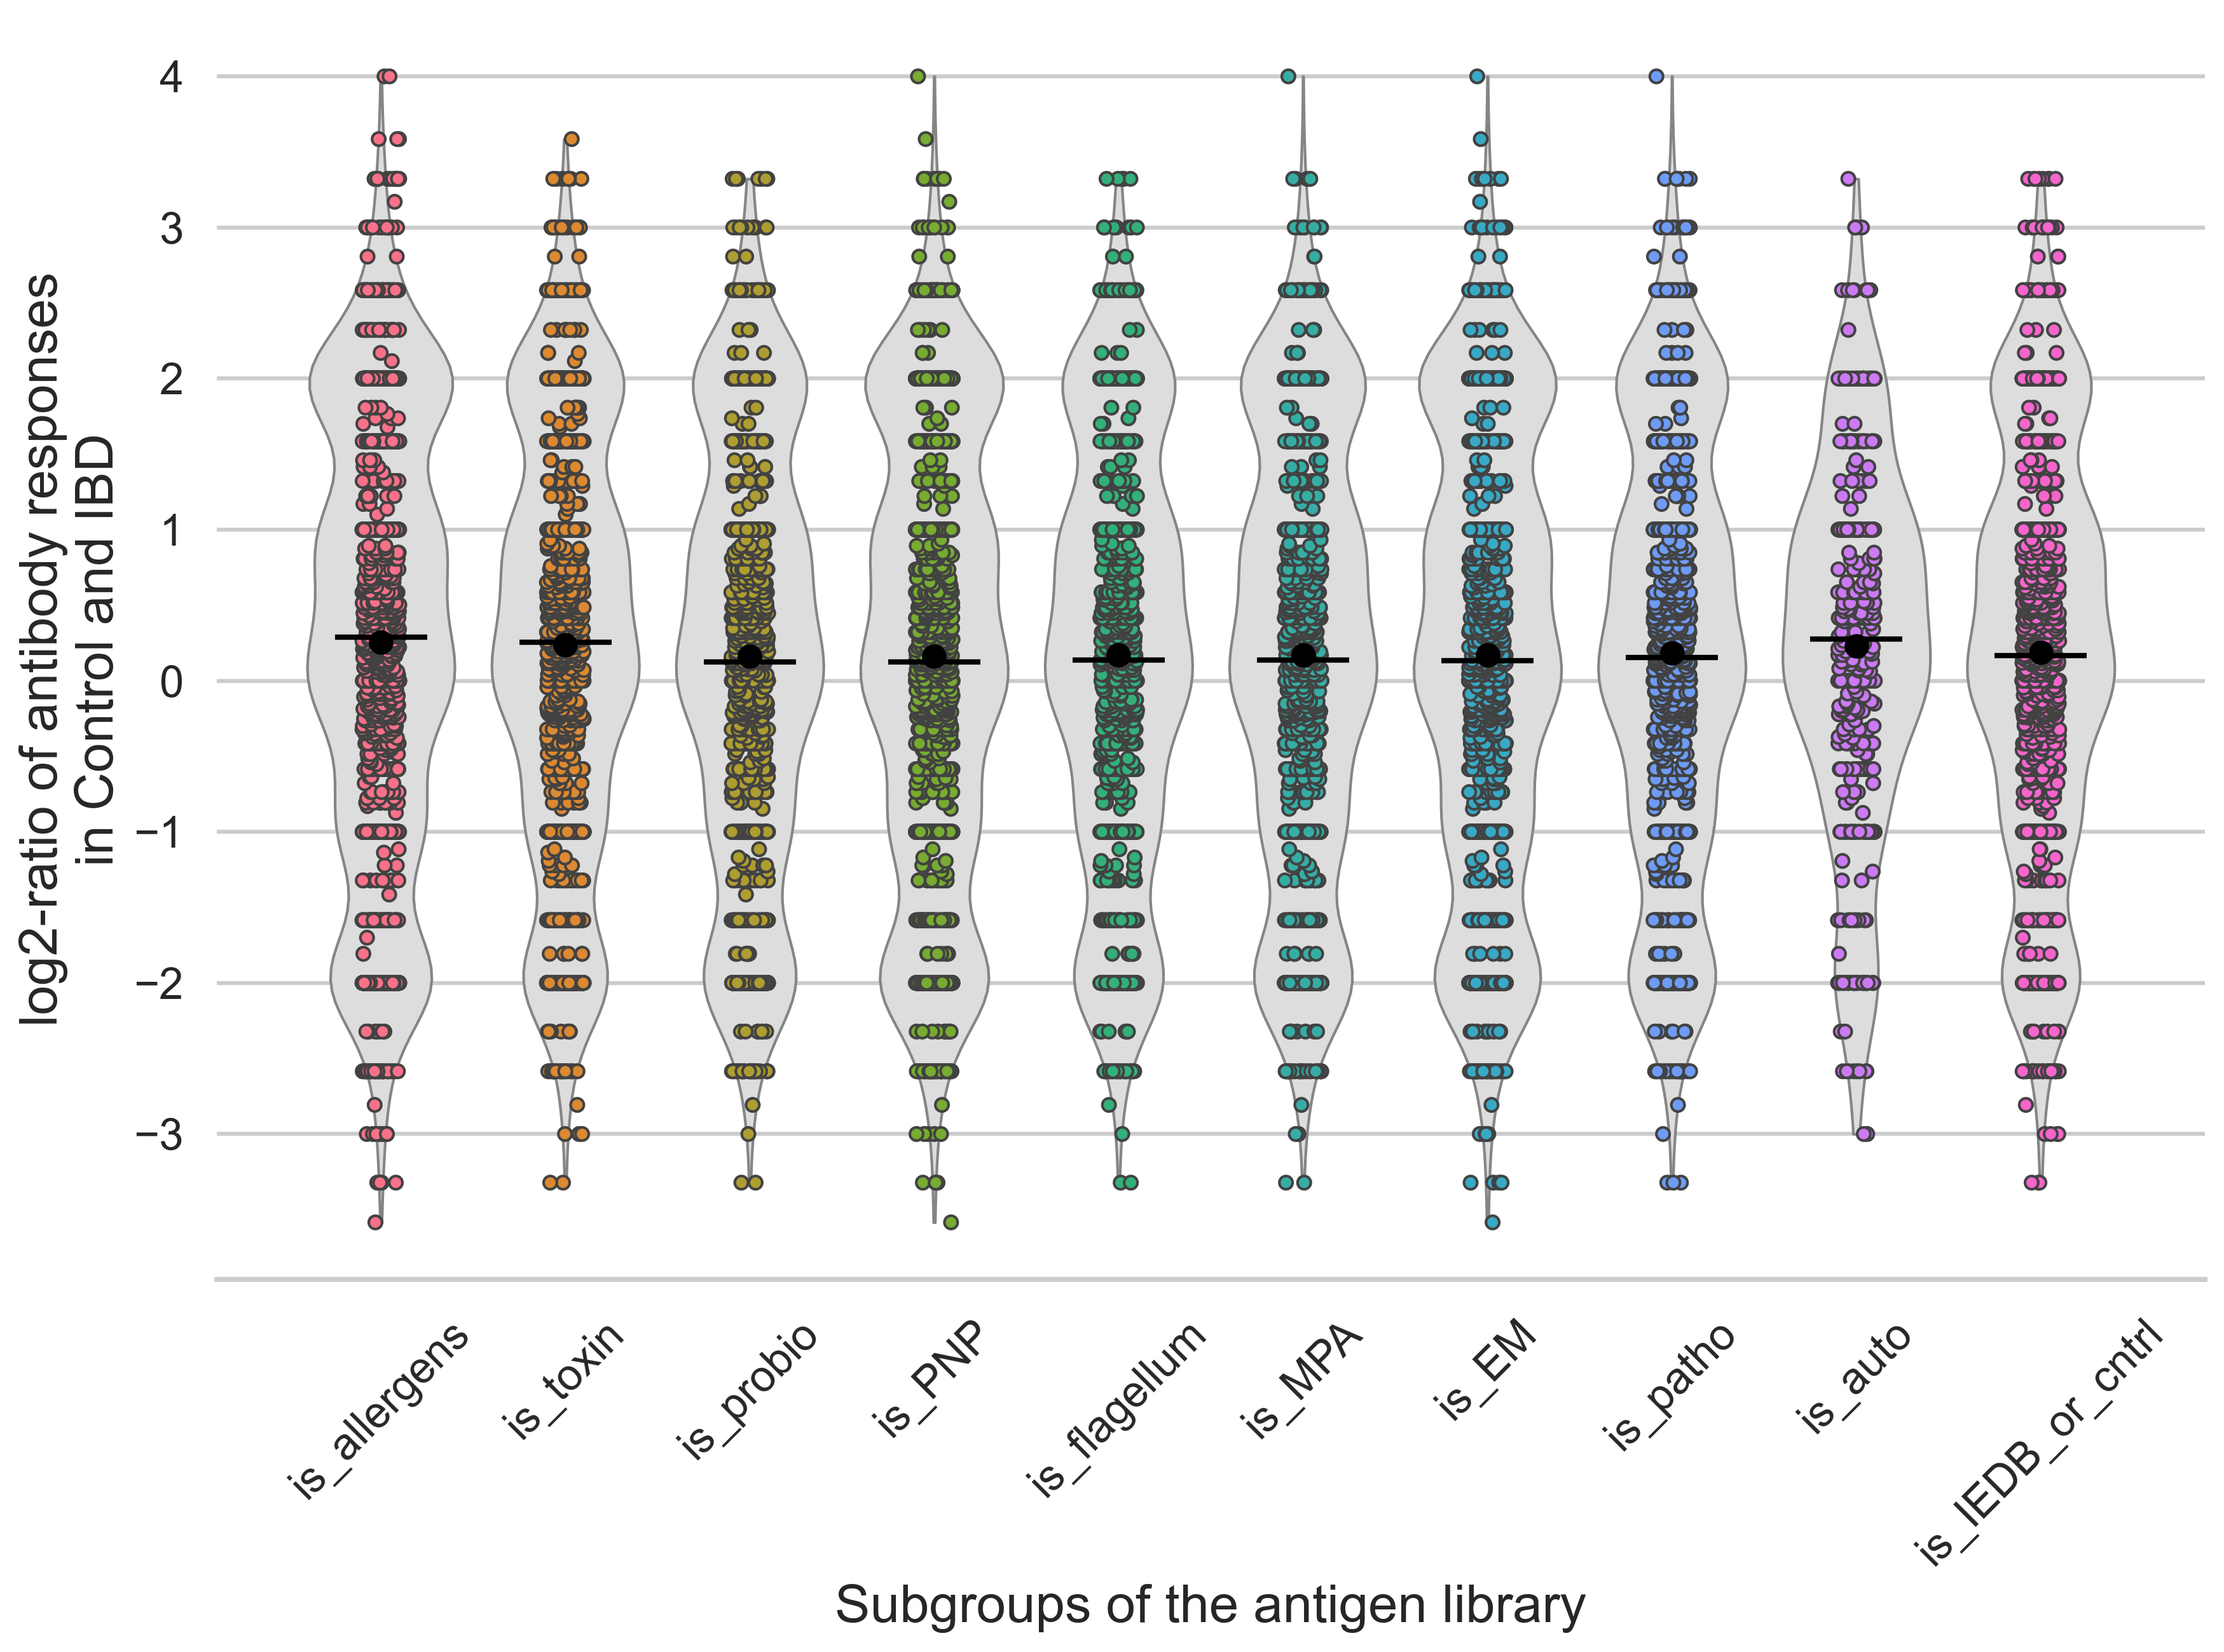

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)

# Violin plot
sns.violinplot(
    x='subgroups',
    y='log2_ratio',
    data=html_data_filtered,
    cut=0,
    density_norm='width',
    inner=None,
    linewidth=1,
    color='#DDDDDD',
    saturation=1,
    order=top_groups,
    ax=ax
)

# Puntos individuales
sns.stripplot(
    x='subgroups',
    y='log2_ratio',
    data=html_data_filtered,
    jitter=True,
    linewidth=1,
    order=top_groups,
    palette=sns.color_palette("husl", n_colors=len(top_groups)),
    ax=ax
)

# Calcular media y mediana por grupo
group_stats = html_data_filtered.groupby('subgroups')['log2_ratio'].agg(['mean', 'median'])

# Añadir la media (punto) y mediana (línea)
for i, species in enumerate(top_groups):
    if species in group_stats.index:
        mean_val = group_stats.loc[species, 'mean']
        median_val = group_stats.loc[species, 'median']
        
        # Punto de la media
        ax.scatter(i, mean_val, color='black', s=60, zorder=5)
        # Línea de la mediana
        ax.hlines(median_val, i - 0.25, i + 0.25, color='black', lw=2, zorder=4)

# Etiquetas y estilo
ax.set_xlabel("Subgroups of the antigen library", fontsize=20)
ax.set_ylabel("log2-ratio of antibody responses\nin Control and IBD", fontsize=20)
ax.tick_params(axis='x', labelrotation=45)
sns.despine(left=True)
plt.tight_layout()
plt.show()
